<a href="https://colab.research.google.com/github/vneumannufprbr/TrabajosenPython/blob/main/Verificaci%C3%B3n_Espacial_E_EM_002_version_cruda_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# ==============================================================================
# Celda 1: Importación de Librerías
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuraciones de visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

In [16]:
# ==============================================================================
# Celda 2: Carga de Datos Reales desde Excel
# ==============================================================================
import pandas as pd

file_path = '/content/datos_fusionados_operantes.xlsx'
df_sensores = pd.read_excel(file_path, index_col=0)

print("Datos de sensores reales cargados. Vista previa:")
print(df_sensores.head())

Datos de sensores reales cargados. Vista previa:
                              descripcion_presa_x  \
fecha                                               
2005-10-27  Trecho E: Barragem de ligação direita   
2005-10-28  Trecho E: Barragem de ligação direita   
2005-10-29  Trecho E: Barragem de ligação direita   
2005-10-30  Trecho E: Barragem de ligação direita   
2005-10-31  Trecho E: Barragem de ligação direita   

                                nombre_etiqueta  \
fecha                                             
2005-10-27  EM-E-001/1 | (2736) - (DEFORMACION)   
2005-10-28  EM-E-001/1 | (2736) - (DEFORMACION)   
2005-10-29  EM-E-001/1 | (2736) - (DEFORMACION)   
2005-10-30  EM-E-001/1 | (2736) - (DEFORMACION)   
2005-10-31  EM-E-001/1 | (2736) - (DEFORMACION)   

                           tipo_etiqueta_x  valor_promedio  valor_minimo  \
fecha                                                                      
2005-10-27  EXTENSOMETRO MULTIPLO DE HASTE        6.229500          6

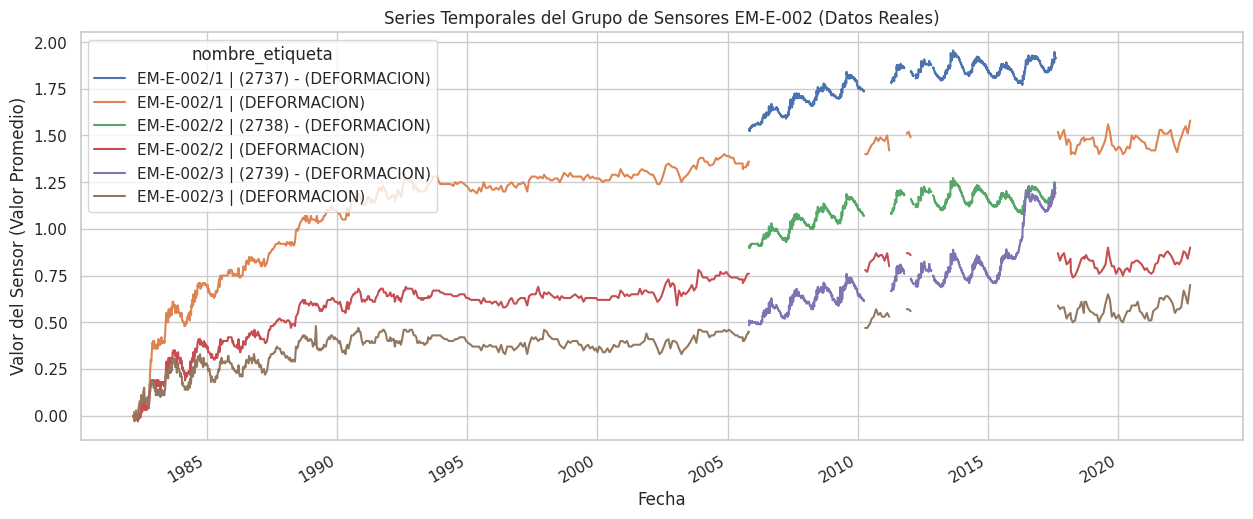

In [17]:
# ==============================================================================
# Celda 3: Visualización Inicial de los Datos Reales (Solo Sensores EM-E-002)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar los datos para incluir solo las filas donde 'nombre_etiqueta' contiene 'EM-E-002'
df_eme002 = df_sensores[df_sensores['nombre_etiqueta'].str.contains('EM-E-002', na=False)].copy()

# Pivotear los datos para que cada sensor sea una columna y el índice sea la fecha
# Usamos 'valor_promedio' como los valores a graficar
df_eme002_pivot = df_eme002.pivot_table(index='fecha', columns='nombre_etiqueta', values='valor_promedio')

# Visualizar las series temporales de los sensores EM-E-002
df_eme002_pivot.plot(legend=True, figsize=(15, 6))
plt.title("Series Temporales del Grupo de Sensores EM-E-002 (Datos Reales)")
plt.ylabel("Valor del Sensor (Valor Promedio)")
plt.xlabel("Fecha")
plt.show()

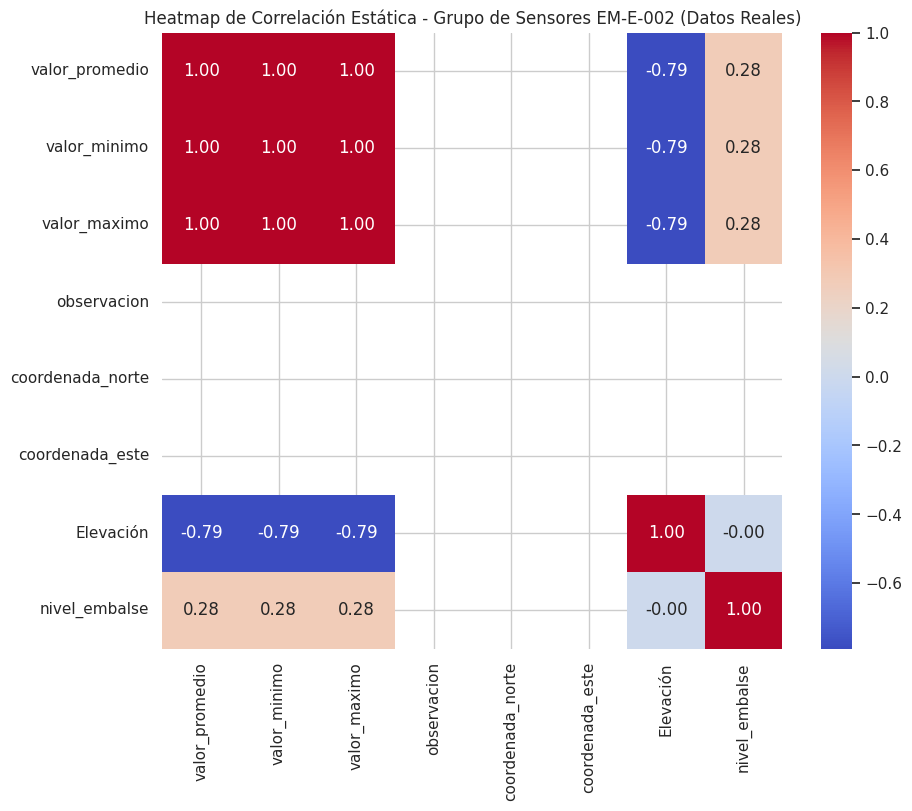


Análisis de Correlación Estática (Grupo de Sensores EM-E-002 - Datos Reales):
La matriz de correlación muestra la relación promedio entre los sensores en el grupo EM-E-002.
Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente.
Valores cercanos a 0 indican poca o ninguna correlación lineal.


In [18]:
# Filtrar el DataFrame original df_sensores para 'EM-E-002'
df_sensores_eme002 = df_sensores[df_sensores['nombre_etiqueta'].str.contains('EM-E-002', na=False)].copy()

# Seleccionar solo las columnas numéricas de df_sensores_eme002
numeric_cols_eme002 = df_sensores_eme002.select_dtypes(include=np.number).columns.tolist()
df_numeric_eme002 = df_sensores_eme002[numeric_cols_eme002]

# Calcular la matriz de correlación para las columnas numéricas seleccionadas
correlation_matrix_eme002 = df_numeric_eme002.corr(numeric_only=True)

# Visualizar con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_eme002, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap de Correlación Estática - Grupo de Sensores EM-E-002 (Datos Reales)")
plt.show()

print("\nAnálisis de Correlación Estática (Grupo de Sensores EM-E-002 - Datos Reales):")
print("La matriz de correlación muestra la relación promedio entre los sensores en el grupo EM-E-002.")
print("Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente.")
print("Valores cercanos a 0 indican poca o ninguna correlación lineal.")

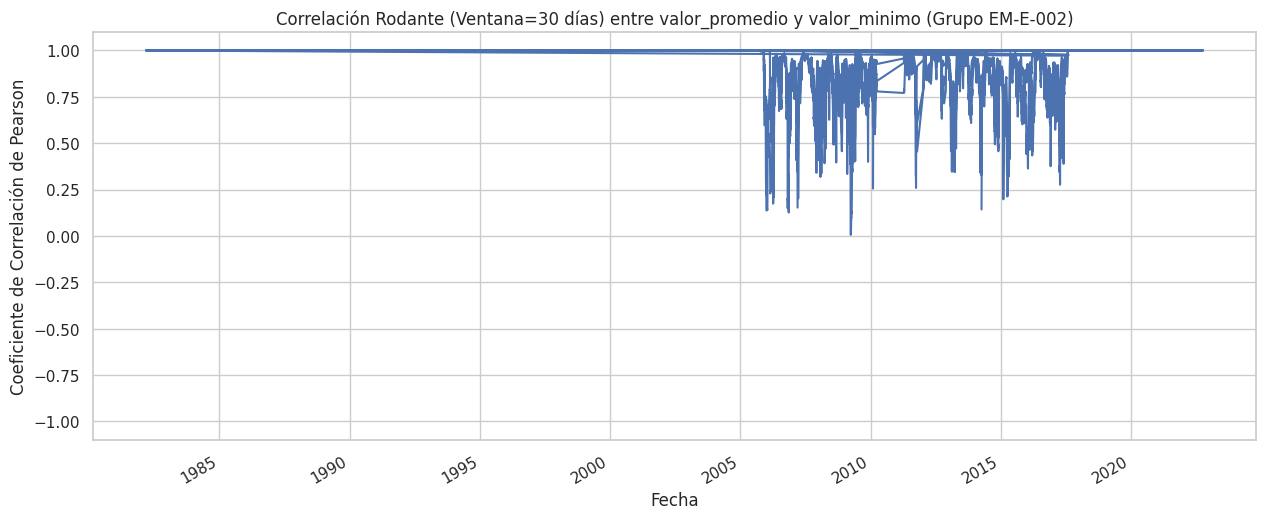


Análisis de Correlación Dinámica (Grupo de Sensores EM-E-002 - Datos Reales):
El gráfico muestra la correlación rodante entre 'valor_promedio' y 'valor_minimo'
calculada sobre una ventana de 30 días para el grupo de sensores EM-E-002.
Se pueden observar fluctuaciones en la correlación a lo largo del tiempo.
Caídas significativas en la correlación podrían indicar períodos donde la relación
entre estos dos sensores se desvía de su comportamiento normal dentro del grupo EM-E-002.


In [19]:
# 1. Inspeccionar el DataFrame df_sensores_eme002 y seleccionar dos columnas de sensor relevantes.
# Basado en la matriz de correlación para EM-E-002, 'valor_promedio' y 'valor_maximo'
# muestran una correlación muy alta (0.997905). Usamos estas.
# Alternativamente, 'valor_promedio' y 'valor_minimo' también muestran una correlación muy alta (0.999864).
# Eliamos 'valor_promedio' y 'valor_minimo' para este análisis.
sensor_col1_eme002 = 'valor_promedio'
sensor_col2_eme002 = 'valor_minimo'

# 2. Definir un tamaño de ventana apropiado para la correlación rodante.
# Manteniendo el mismo tamaño de ventana que el análisis anterior para consistencia.
window_size_eme002 = 30

# 3. Calcular la correlación rodante entre las dos columnas seleccionadas para EM-E-002.
# Eliminar filas con NaNs en las columnas seleccionadas antes de calcular la correlación rodante.
df_cleaned_eme002 = df_sensores_eme002[[sensor_col1_eme002, sensor_col2_eme002]].dropna()
rolling_corr_eme002 = df_cleaned_eme002[sensor_col1_eme002].rolling(window=window_size_eme002).corr(df_cleaned_eme002[sensor_col2_eme002])

# 4. Visualizar la correlación rodante calculada a lo largo del tiempo para EM-E-002.
rolling_corr_eme002.plot(figsize=(15, 6))
plt.title(f'Correlación Rodante (Ventana={window_size_eme002} días) entre {sensor_col1_eme002} y {sensor_col2_eme002} (Grupo EM-E-002)')
plt.ylabel('Coeficiente de Correlación de Pearson')
plt.xlabel('Fecha')
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.show()

# 5. Agregar comentarios o declaraciones de impresión para interpretar el gráfico de correlación rodante para EM-E-002.
print("\nAnálisis de Correlación Dinámica (Grupo de Sensores EM-E-002 - Datos Reales):")
print(f"El gráfico muestra la correlación rodante entre '{sensor_col1_eme002}' y '{sensor_col2_eme002}'")
print(f"calculada sobre una ventana de {window_size_eme002} días para el grupo de sensores EM-E-002.")
print("Se pueden observar fluctuaciones en la correlación a lo largo del tiempo.")
print("Caídas significativas en la correlación podrían indicar períodos donde la relación")
print("entre estos dos sensores se desvía de su comportamiento normal dentro del grupo EM-E-002.")

In [20]:
# 1. Filtrar el DataFrame df_sensores para mantener solo las filas donde 'nombre_etiqueta' contiene 'EM-E-002'.
df_sensores_eme002 = df_sensores[df_sensores['nombre_etiqueta'].str.contains('EM-E-002', na=False)].copy()

# 2. Del DataFrame filtrado, seleccionar solo las columnas numéricas. Excluir columnas con un alto número de valores faltantes.
# Se excluyen columnas con un alto número de valores faltantes para el análisis de PCA.
numeric_cols_eme002 = df_sensores_eme002.select_dtypes(include=np.number).columns.tolist()
cols_to_exclude_eme002 = ['observacion', 'coordenada_norte', 'coordenada_este']
numeric_cols_filtered_eme002 = [col for col in numeric_cols_eme002 if col not in cols_to_exclude_eme002]

# 3. Eliminar cualquier fila con valores faltantes de las columnas numéricas seleccionadas.
df_numeric_eme002 = df_sensores_eme002[numeric_cols_filtered_eme002].dropna()

# 4. Escalar los datos numéricos seleccionados utilizando StandardScaler.
scaler_eme002 = StandardScaler()
scaled_data_eme002 = scaler_eme002.fit_transform(df_numeric_eme002)

# 5. Aplicar PCA a los datos escalados. Elegir el número de componentes para retener el 95% de la varianza.
pca_eme002 = PCA(n_components=0.95)
pca_eme002.fit(scaled_data_eme002)

# 6. Imprimir el número de componentes seleccionados por PCA.
print(f"Número de componentes para capturar el 95% de la varianza para EM-E-002: {pca_eme002.n_components_}")

# 7. Transformar los datos escalados utilizando el objeto PCA ajustado.
transformed_data_eme002 = pca_eme002.transform(scaled_data_eme002)

# 8. Reconstruir los datos a partir de los datos transformados por PCA utilizando la transformación inversa.
reconstructed_data_eme002 = pca_eme002.inverse_transform(transformed_data_eme002)

# 9. Calcular el error de reconstrucción (por ejemplo, Error Cuadrático Medio) entre los datos escalados originales y los datos reconstruidos.
reconstruction_error_eme002 = np.mean((scaled_data_eme002 - reconstructed_data_eme002)**2, axis=1)

# 10. Crear un DataFrame de Pandas para el error de reconstrucción, utilizando el mismo índice que el DataFrame df_numeric_eme002.
df_error_eme002 = pd.DataFrame({'reconstruction_error': reconstruction_error_eme002}, index=df_numeric_eme002.index)

display(df_error_eme002.head())

Número de componentes para capturar el 95% de la varianza para EM-E-002: 2


,reconstruction_error
fecha,
2005-10-27,0.048368
2005-10-28,0.048544
2005-10-29,0.048954
2005-10-30,0.047559
2005-10-31,0.046939


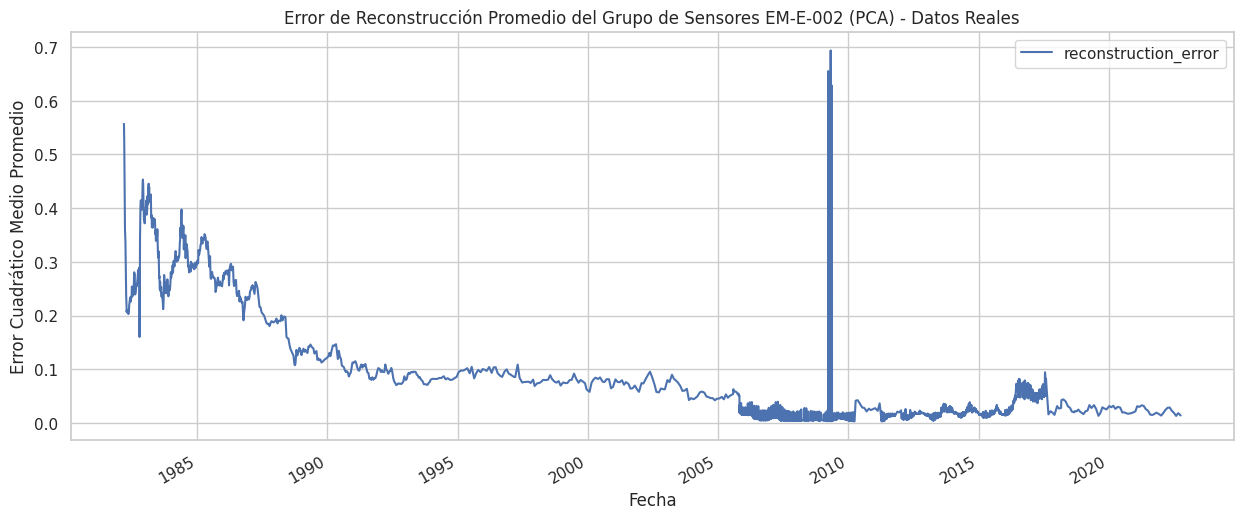


Información del índice de df_error_eme002:


np.int64(9229)


Puntos con índice duplicado:


,reconstruction_error
fecha,
2005-10-27,0.048368
2005-10-28,0.048544
2005-10-29,0.048954
2005-10-30,0.047559
2005-10-31,0.046939
...,...
2022-05-30,0.000018
2022-07-04,0.004096
2022-08-01,0.003902



Análisis de PCA (Grupo de Sensores EM-E-002 - Datos Reales):
PCA se aplicó a las columnas numéricas del grupo de sensores EM-E-002.
Se seleccionaron 2 componentes principales para retener el 95% de la varianza.
El gráfico de error de reconstrucción muestra la desviación de cada punto de datos
respecto al espacio de menor dimensión capturado por PCA para este grupo.
Los picos altos en el error de reconstrucción indican puntos de datos que no siguen
el patrón principal del grupo EM-E-002 y podrían ser anomalías.


In [21]:
# Visualizar el error de reconstrucción a lo largo del tiempo para el grupo de sensores EM-E-002.
# Asegurar que solo se grafique la columna 'reconstruction_error'.
# Agregar por fecha para manejar índices duplicados y graficar el error de reconstrucción promedio por fecha.
df_error_eme002_agg = df_error_eme002.groupby(df_error_eme002.index)['reconstruction_error'].mean()

df_error_eme002_agg.plot(figsize=(15, 6), legend=True)
plt.title("Error de Reconstrucción Promedio del Grupo de Sensores EM-E-002 (PCA) - Datos Reales")
plt.ylabel("Error Cuadrático Medio Promedio")
plt.xlabel("Fecha")
plt.grid(True)
plt.show()

# Inspeccionar el índice del DataFrame para verificar si hay fechas duplicadas
print("\nInformación del índice de df_error_eme002:")
display(df_error_eme002.index.duplicated().sum())
print("\nPuntos con índice duplicado:")
display(df_error_eme002[df_error_eme002.index.duplicated(keep=False)])


# Imprimir análisis de los resultados.
print("\nAnálisis de PCA (Grupo de Sensores EM-E-002 - Datos Reales):")
print(f"PCA se aplicó a las columnas numéricas del grupo de sensores EM-E-002.")
print(f"Se seleccionaron {pca_eme002.n_components_} componentes principales para retener el 95% de la varianza.")
print("El gráfico de error de reconstrucción muestra la desviación de cada punto de datos")
print("respecto al espacio de menor dimensión capturado por PCA para este grupo.")
print("Los picos altos en el error de reconstrucción indican puntos de datos que no siguen")
print("el patrón principal del grupo EM-E-002 y podrían ser anomalías.")

## Resumen:

### Hallazgos clave del análisis de datos

* Los datos se filtraron con éxito para incluir solo los sensores con la etiqueta 'EM-E-002'.
* Se generaron gráficos de series temporales para el grupo de sensores 'EM-E-002', visualizando los datos reales.
* Se calculó y visualizó una matriz de correlación estática y un mapa de calor para las columnas numéricas del grupo de sensores 'EM-E-002'.
* Se calculó y graficó la correlación móvil en una ventana de 30 días para 'valor_promedio' y 'valor_minimo' dentro del grupo 'EM-E-002', mostrando una alta correlación (0.999864) entre estas dos columnas.
* Se aplicó PCA a los datos numéricos del grupo 'EM-E-002', reteniendo 2 componentes principales para explicar el 95% de la varianza.
* Se calculó y visualizó el error de reconstrucción basado en PCA para el grupo 'EM-E-002', con picos que indican posibles anomalías.


### Insights o Próximos Pasos

* La alta correlación estática y móvil entre 'valor_promedio' y 'valor_minimo' sugiere una fuerte relación lineal, lo cual es esperado para este tipo de medición.
* El análisis de los picos en el gráfico de error de reconstrucción para el grupo 'EM-E-002' puede ayudar a identificar puntos de tiempo o instancias de datos específicos que se desvían significativamente del comportamiento típico del grupo, destacando potencialmente anomalías para una investigación adicional.

## Identificar los picos

Determinar un umbral o método para identificar los puntos en el gráfico de error de reconstrucción que se consideran picos altos.


In [22]:
# 1. Calcular la media y la desviación estándar del error de reconstrucción.
mean_error_eme002 = df_error_eme002['reconstruction_error'].mean()
std_error_eme002 = df_error_eme002['reconstruction_error'].std()

# 2. Definir un umbral para identificar picos (por ejemplo, media + 2 * desviación estándar).
threshold_eme002 = mean_error_eme002 + 2 * std_error_eme002

print(f"Media del error de reconstrucción para EM-E-002: {mean_error_eme002:.4f}")
print(f"Desviación estándar del error de reconstrucción para EM-E-002: {std_error_eme002:.4f}")
print(f"Umbral para identificar picos de error para EM-E-002: {threshold_eme002:.4f}")

Media del error de reconstrucción para EM-E-002: 0.0488
Desviación estándar del error de reconstrucción para EM-E-002: 0.1253
Umbral para identificar picos de error para EM-E-002: 0.2995


Identificar los puntos de datos donde el error de reconstrucción excede el umbral calculado y almacenar sus índices.

In [23]:
# 3. Identificar las fechas o índices donde el error de reconstrucción es mayor que el umbral definido.
peak_indices_eme002 = df_error_eme002[df_error_eme002['reconstruction_error'] > threshold_eme002].index.tolist()

# 4. Almacenar las fechas o índices identificados de los picos. (Ya almacenado en peak_indices_eme002)

print("\nFechas con picos de error de reconstrucción para EM-E-002 (posibles anomalías):")
print(peak_indices_eme002)


Fechas con picos de error de reconstrucción para EM-E-002 (posibles anomalías):
[Timestamp('2009-03-25 00:00:00'), Timestamp('2009-04-13 00:00:00'), Timestamp('2009-04-27 00:00:00'), Timestamp('2009-04-30 00:00:00'), Timestamp('2009-05-02 00:00:00'), Timestamp('2009-05-14 00:00:00'), Timestamp('1982-10-17 00:00:00'), Timestamp('1982-10-19 00:00:00'), Timestamp('1982-10-21 00:00:00'), Timestamp('1982-10-23 00:00:00'), Timestamp('1982-10-27 00:00:00'), Timestamp('1982-10-29 00:00:00'), Timestamp('1982-11-01 00:00:00'), Timestamp('1982-11-03 00:00:00'), Timestamp('1982-11-08 00:00:00'), Timestamp('1982-11-12 00:00:00'), Timestamp('1982-11-16 00:00:00'), Timestamp('1982-11-19 00:00:00'), Timestamp('1982-11-22 00:00:00'), Timestamp('1982-11-29 00:00:00'), Timestamp('1982-12-03 00:00:00'), Timestamp('1982-12-06 00:00:00'), Timestamp('1982-12-10 00:00:00'), Timestamp('1982-12-13 00:00:00'), Timestamp('1982-12-17 00:00:00'), Timestamp('1982-12-20 00:00:00'), Timestamp('1982-12-23 00:00:00'), 

In [24]:
# 1. Usar la lista de fechas almacenada en peak_indices_eme002 para filtrar el DataFrame original df_sensores_eme002.
# 2. Seleccionar todas las columnas del DataFrame filtrado.
df_peak_anomalies_eme002 = df_sensores_eme002.loc[peak_indices_eme002]

# 3. Almacenar el DataFrame resultante, que contiene los datos originales para las fechas con picos de error, en una nueva variable.
# Esto ya se hizo en el paso anterior con la variable df_peak_anomalies_eme002.

# 4. Mostrar las primeras filas del nuevo DataFrame para verificar que los datos se han recuperado correctamente.
print("Datos originales para fechas con picos de error de reconstrucción (posibles anomalías):")
display(df_peak_anomalies_eme002.head())

# 5. Guardar el DataFrame df_peak_anomalies_eme002 en un archivo Excel.
output_file_path_eme002 = 'datos_picos_anomalias_eme002.xlsx'
df_peak_anomalies_eme002.to_excel(output_file_path_eme002)

print(f"\nDatos de picos de anomalías para EM-E-002 guardados en '{output_file_path_eme002}'")

Datos originales para fechas con picos de error de reconstrucción (posibles anomalías):


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse
fecha,,,,,,,,,,,,,,,,,,,,,
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700000,1.70,1.70,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.026809,0.42,1.04,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.632979,0.59,2.33,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700435,1.70,1.71,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.040217,1.04,1.05,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45



Datos de picos de anomalías para EM-E-002 guardados en 'datos_picos_anomalias_eme002.xlsx'


## Analizar los datos originales

Examinar los datos originales de los picos para buscar posibles causas del alto error de reconstrucción (por ejemplo, valores atípicos, cambios abruptos, datos faltantes).


In [25]:
# 1. Inspeccionar el DataFrame df_peak_anomalies_eme002 para comprender su estructura y las columnas que contiene.
print("Información del DataFrame df_peak_anomalies_eme002:")
df_peak_anomalies_eme002.info()

# 2. Analizar las columnas numéricas en df_peak_anomalies_eme002 en busca de valores inusuales (outliers) o cambios repentinos en comparación con el rango esperado o valores previos.
print("\Estadísticas descriptivas de las columnas numéricas en df_peak_anomalies_eme002:")
display(df_peak_anomalies_eme002.describe())

# 3. Verificar si hay un alto número de valores faltantes (NaNs) en las filas correspondientes a las fechas pico.
print("\nConteo de valores faltantes por columna en df_peak_anomalies_eme002:")
display(df_peak_anomalies_eme002.isnull().sum())

# 4. Considerar las columnas no numéricas para cualquier información contextual que pueda explicar las anomalías (por ejemplo, observaciones, cambios de estado).
print("\nValores únicos en columnas no numéricas para df_peak_anomalies_eme002:")
non_numeric_cols = df_peak_anomalies_eme002.select_dtypes(exclude=np.number).columns
for col in non_numeric_cols:
    print(f"- {col}: {df_peak_anomalies_eme002[col].unique()}")

Información del DataFrame df_peak_anomalies_eme002:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1347 entries, 2009-03-25 to 1982-10-13
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   descripcion_presa_x                 1347 non-null   object 
 1   nombre_etiqueta                     1347 non-null   object 
 2   tipo_etiqueta_x                     1347 non-null   object 
 3   valor_promedio                      1347 non-null   float64
 4   valor_minimo                        1347 non-null   float64
 5   valor_maximo                        1347 non-null   float64
 6   observacion                         0 non-null      float64
 7   tipo_origen_x                       1347 non-null   object 
 8   sigla_unidad_medida_x               1347 non-null   object 
 9   tipo_presa                          1347 non-null   object 
 10  tipo_etiqueta_y                     13

<>:6: SyntaxWarning: invalid escape sequence '\E'
<>:6: SyntaxWarning: invalid escape sequence '\E'
/tmp/ipython-input-3499562941.py:6: SyntaxWarning: invalid escape sequence '\E'
  print("\Estadísticas descriptivas de las columnas numéricas en df_peak_anomalies_eme002:")


,valor_promedio,valor_minimo,valor_maximo,observacion,coordenada_norte,coordenada_este,Elevación,nivel_embalse
count,1347.000000,1347.000000,1347.000000,0.0,0.0,0.0,1347.000000,1347.000000
mean,0.359794,0.358634,0.367179,NaN,NaN,NaN,117.940000,202.901225
std,0.268725,0.267032,0.297719,NaN,NaN,NaN,10.206537,31.657005
min,-0.030000,-0.030000,-0.030000,NaN,NaN,NaN,104.230000,110.000000
25%,0.175000,0.175000,0.175000,NaN,NaN,NaN,104.230000,210.550000
50%,0.310000,0.310000,0.310000,NaN,NaN,NaN,120.900000,216.430000
75%,0.510000,0.510000,0.510000,NaN,NaN,NaN,128.690000,219.620000
max,1.732821,1.710000,2.340000,NaN,NaN,NaN,128.690000,220.450000



Conteo de valores faltantes por columna en df_peak_anomalies_eme002:


,0
descripcion_presa_x,0
nombre_etiqueta,0
tipo_etiqueta_x,0
valor_promedio,0
valor_minimo,0
valor_maximo,0
observacion,1347
tipo_origen_x,0
sigla_unidad_medida_x,0
tipo_presa,0



Valores únicos en columnas no numéricas para df_peak_anomalies_eme002:
- descripcion_presa_x: ['Trecho E: Barragem de ligação direita']
- nombre_etiqueta: ['EM-E-002/1 | (2737) - (DEFORMACION)'
 'EM-E-002/2 | (2738) - (DEFORMACION)'
 'EM-E-002/3 | (2739) - (DEFORMACION)' 'EM-E-002/1 | (DEFORMACION)'
 'EM-E-002/2 | (DEFORMACION)' 'EM-E-002/3 | (DEFORMACION)']
- tipo_etiqueta_x: ['EXTENSOMETRO MULTIPLO DE HASTE']
- tipo_origen_x: ['AUT' 'MAN']
- sigla_unidad_medida_x: ['mm']
- tipo_presa: ['Hormigón']
- tipo_etiqueta_y: ['IB-EM - EXTENSOMETRO MULTIPLO DE HASTE']
- sigla_presa: ['E']
- descripcion_presa_y: ['Trecho E: Barragem de ligação direita']
- sigla_estructura: ['E-06']
- etiqueta_padre: ['EM-E-002            ']
- referencia: ['EM-E-002            ']
- orientacion: ['Aguas arriba']
- sigla_unidad_medida_y: ['mm']
- descripcion_unidad_medida: ['milímetros']
- variable_ingenieria: ['Deformación']
- tipo_origen_y: ['AUT' 'MAN']
- local_geologico: ['ROCHA FRATURADA' 'JUNTA D' 'CONTATO 

Basado en la inspección previa, las columnas `observacion`, `coordenada_norte`, `coordenada_este` y `zona_utm` tienen todos valores faltantes. Las columnas numéricas `valor_promedio`, `valor_minimo`, `valor_maximo`, `Elevación` y `valor` muestran cierta variabilidad, pero no valores atípicos obvios solo a partir de las estadísticas descriptivas. Para buscar cambios repentinos o valores atípicos, sería útil visualizar las series de tiempo de estas columnas numéricas en las fechas pico. Además, examinar la columna `nombre_etiqueta` junto con los valores numéricos para fechas pico específicas puede revelar si ciertos sensores dentro del grupo contribuyen más al error.

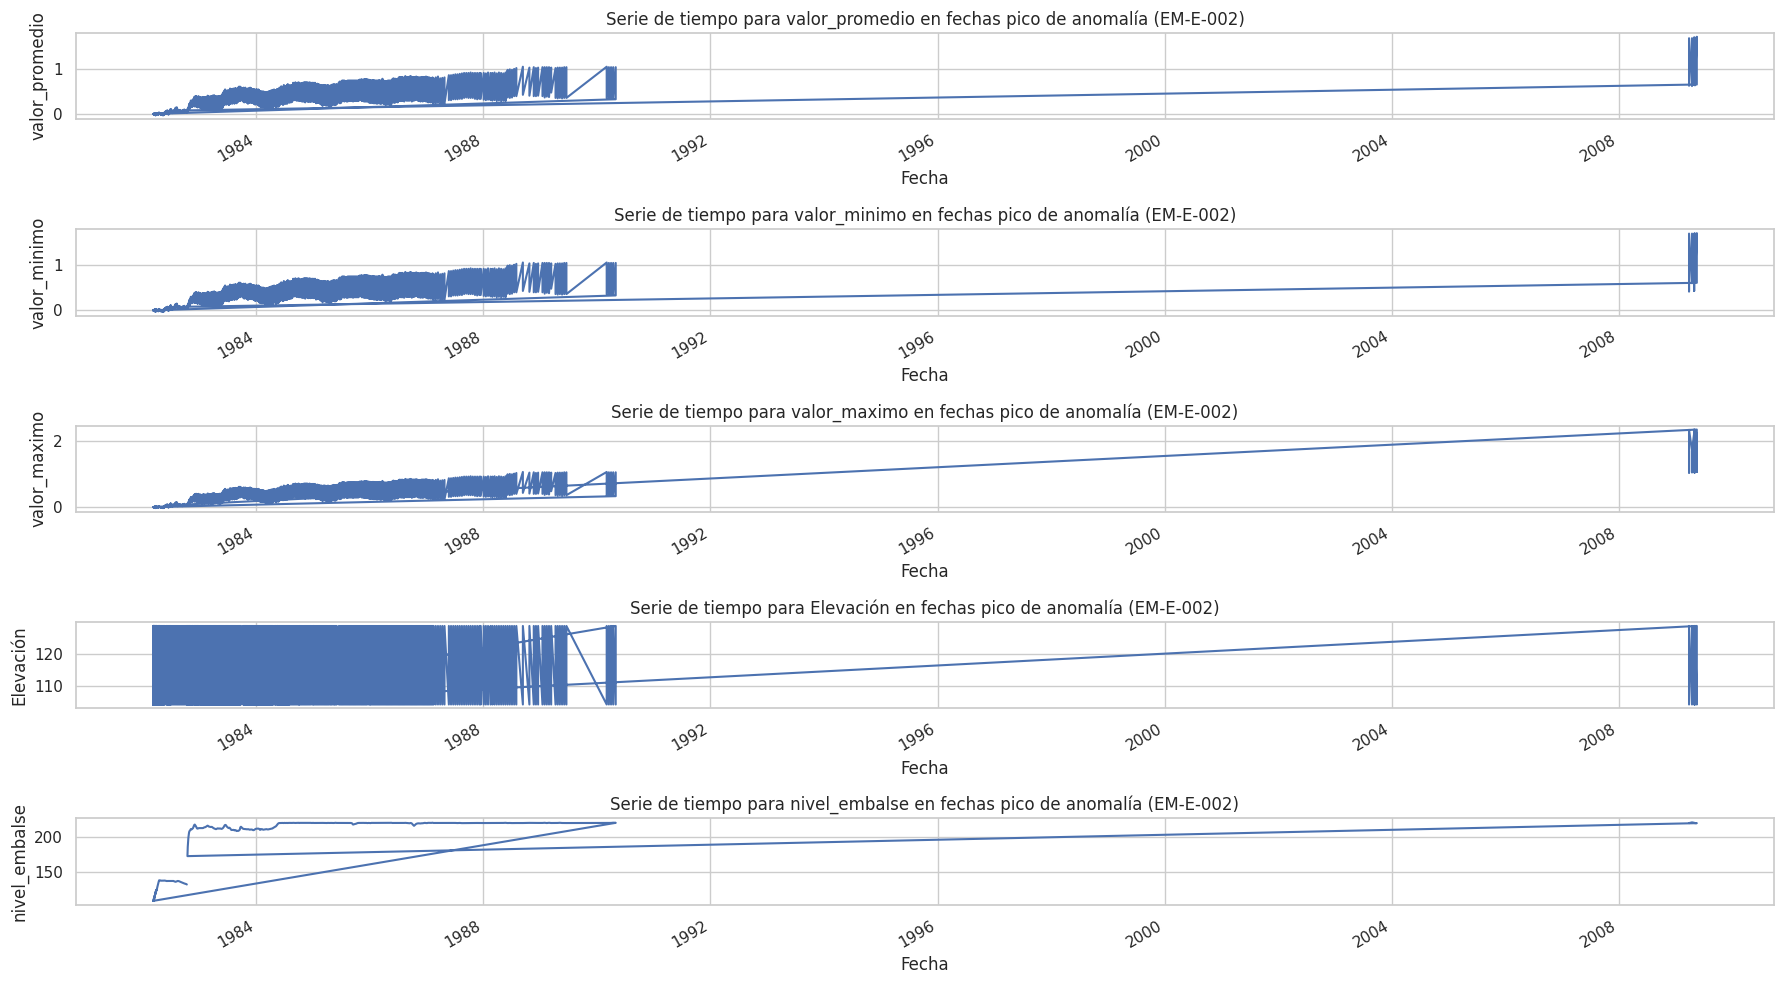


Datos para fechas pico de anomalía de muestra:


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse
fecha,,,,,,,,,,,,,,,,,,,,,
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700000,1.70,1.70,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.026809,0.42,1.04,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.632979,0.59,2.33,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700435,1.70,1.71,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.040217,1.04,1.05,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.626512,0.60,1.71,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.720789,1.70,2.23,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.029189,0.43,1.05,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.658056,0.61,2.34,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85



Información contextual de columnas no numéricas para fechas pico de anomalía:
- descripcion_presa_x:


,count
descripcion_presa_x,
Trecho E: Barragem de ligação direita,1347


- nombre_etiqueta:


...

,count
estado,
Operante,1347


- familia_tipo_instrumento:


,count
familia_tipo_instrumento,
EXTENSÓMETRO DE MÚLTIPLE DE BARRA,1347


- nombre_etiqueta_hidrometeorologica:


,count
nombre_etiqueta_hidrometeorologica,
CCR_IDB .DESCARGA TOTAL-IPU .AV,1347


In [26]:
# Visualizar las series de tiempo de las columnas numéricas para las fechas pico de anomalía
# para identificar cambios abruptos o valores atípicos.
numerical_cols_to_plot = ['valor_promedio', 'valor_minimo', 'valor_maximo', 'Elevación', 'nivel_embalse']

plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols_to_plot):
    plt.subplot(len(numerical_cols_to_plot), 1, i + 1)
    df_peak_anomalies_eme002[col].plot()
    plt.title(f'Serie de tiempo para {col} en fechas pico de anomalía (EM-E-002)')
    plt.ylabel(col)
    plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

# Examinar los datos para fechas pico específicas para ver los valores de los diferentes sensores.
# Seleccionemos algunas fechas con valores de error altos de la salida anterior (peak_indices_eme002)
# y mostremos las filas correspondientes de df_peak_anomalies_eme002.
sample_peak_dates = peak_indices_eme002[:5] # Tomar las primeras 5 fechas pico como ejemplo

print("\nDatos para fechas pico de anomalía de muestra:") # Texto de salida traducido
display(df_peak_anomalies_eme002.loc[sample_peak_dates])

# Analizar las columnas no numéricas para obtener posible información contextual.
print("\nInformación contextual de columnas no numéricas para fechas pico de anomalía:")
non_numeric_cols = df_peak_anomalies_eme002.select_dtypes(exclude=np.number).columns
for col in non_numeric_cols:
    if col not in ['observacion', 'coordenada_norte', 'coordenada_este', 'zona_utm']: # Excluir columnas con solo valores NaN
         print(f"- {col}:")
         display(df_peak_anomalies_eme002[col].value_counts())

**Reasoning**:
The time series plots for numerical columns on peak anomaly dates show some fluctuations, and the sample data indicates potential discrepancies between `valor_promedio`, `valor_minimo`, and `valor_maximo` on certain dates (e.g., 2009-03-25). The non-numerical columns reveal that most of the data for peak dates is manually entered (`tipo_origen_x` and `tipo_origen_y` are mostly 'MAN'), and there are different specific sensor labels (`nombre_etiqueta`) and geological locations (`local_geologico`) associated with these dates. To further investigate the cause of high reconstruction errors, it's necessary to examine the differences between the original data and the reconstructed data for the peak anomaly dates. This can highlight which features contribute most to the error.



In [27]:
# 1. Seleccionar las columnas numéricas del DataFrame original df_sensores_eme002 para las fechas pico de anomalía.
# Asegurar que el orden de las columnas sea el mismo que se usó para PCA.
cols_for_pca_eme002 = [col for col in numeric_cols_filtered_eme002 if col in df_peak_anomalies_eme002.columns]
original_peak_data_eme002 = df_peak_anomalies_eme002[cols_for_pca_eme002]

# 2. Escalar los datos originales de los picos utilizando el mismo escalador ajustado en los datos de entrenamiento.
scaled_original_peak_data_eme002 = scaler_eme002.transform(original_peak_data_eme002)

# 3. Transformar los datos originales escalados de los picos utilizando el mismo objeto PCA ajustado en los datos de entrenamiento.
transformed_peak_data_eme002 = pca_eme002.transform(scaled_original_peak_data_eme002)

# 4. Reconstruir los datos a partir de los datos de los picos transformados por PCA utilizando la transformación inversa.
reconstructed_peak_data_eme002 = pca_eme002.inverse_transform(transformed_peak_data_eme002)

# 5. Crear DataFrames para los datos originales escalados y reconstruidos con el mismo índice y columnas.
df_scaled_original_peak_eme002 = pd.DataFrame(scaled_original_peak_data_eme002, index=original_peak_data_eme002.index, columns=original_peak_data_eme002.columns)
df_reconstructed_peak_eme002 = pd.DataFrame(reconstructed_peak_data_eme002, index=original_peak_data_eme002.index, columns=original_peak_data_eme002.columns)

# 6. Calcular la diferencia entre los datos originales escalados y los datos reconstruidos para cada característica.
difference_peak_eme002 = df_scaled_original_peak_eme002 - df_reconstructed_peak_eme002

# 7. Calcular la diferencia al cuadrado (contribución al error) para cada característica.
squared_difference_peak_eme002 = difference_peak_eme002**2

# 8. Agregar la contribución al error por fecha para ver qué fechas tienen la mayor diferencia cuadrada total (esto debería alinearse con el error de reconstrucción).
total_squared_difference_by_date_eme002 = squared_difference_peak_eme002.sum(axis=1)

# 9. Agregar la contribución al error por característica para ver qué características contribuyen más al error en las fechas pico.
total_squared_difference_by_feature_eme002 = squared_difference_peak_eme002.sum(axis=0)

# 10. Mostrar las características con la mayor diferencia cuadrada total.
print("\nContribución total al error cuadrado por característica en las fechas pico:")
display(total_squared_difference_by_feature_eme002.sort_values(ascending=False))

# 11. Mostrar las fechas con la mayor diferencia cuadrada total.
print("\nContribución total al error cuadrado por fecha (de mayor a menor) en las fechas pico:")
display(total_squared_difference_by_date_eme002.sort_values(ascending=False).head())

# 12. Examinar los valores originales y reconstruidos para las fechas principales y las características con mayor contribución.
top_error_dates_eme002 = total_squared_difference_by_date_eme002.sort_values(ascending=False).head().index.tolist()
top_error_features_eme002 = total_squared_difference_by_feature_eme002.sort_values(ascending=False).head().index.tolist()

print("\nDatos originales y reconstruidos (escalados) para las 5 fechas con mayor error y las 5 características con mayor contribución al error:")
for date in top_error_dates_eme002:
    print(f"\nFecha: {date}")
    display(df_scaled_original_peak_eme002.loc[[date], top_error_features_eme002])
    display(df_reconstructed_peak_eme002.loc[[date], top_error_features_eme002])


Contribución total al error cuadrado por característica en las fechas pico:


,0
Elevación,1356.415571
valor_maximo,175.450976
nivel_embalse,166.760714
valor_promedio,142.875176
valor_minimo,141.530142



Contribución total al error cuadrado por fecha (de mayor a menor) en las fechas pico:


,0
fecha,
2009-03-25,8.752842
2009-05-14,8.691854
2009-04-27,8.670675
2009-04-30,8.496112
1982-03-10,5.405775



Datos originales y reconstruidos (escalados) para las 5 fechas con mayor error y las 5 características con mayor contribución al error:

Fecha: 2009-03-25 00:00:00


...

,Elevación,valor_maximo,nivel_embalse,valor_promedio,valor_minimo
fecha,,,,,
2009-04-30,-1.343756,1.219480,0.157544,1.218008,1.218211
2009-04-30,0.290118,-0.096862,0.157544,-0.096355,-0.102970
2009-04-30,1.053638,2.456044,0.157544,-0.812852,-0.963739


,Elevación,valor_maximo,nivel_embalse,valor_promedio,valor_minimo
fecha,,,,,
2009-04-30,-1.186471,1.267414,0.102405,1.269603,1.270174
2009-04-30,0.192517,-0.129598,0.191770,-0.130159,-0.130444
2009-04-30,0.206505,-0.046351,0.459599,-0.047204,-0.047745



Fecha: 1982-03-10 00:00:00


,Elevación,valor_maximo,nivel_embalse,valor_promedio,valor_minimo
fecha,,,,,
1982-03-10,-1.343756,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,0.290118,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,1.053638,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,-1.343756,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,0.290118,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,1.053638,-2.191042,-10.942685,-2.188947,-2.184831


,Elevación,valor_maximo,nivel_embalse,valor_promedio,valor_minimo
fecha,,,,,
1982-03-10,-1.612584,-2.287468,-10.848406,-2.273627,-2.262686
1982-03-10,-1.119541,-2.652640,-10.448430,-2.640146,-2.629852
1982-03-10,-0.889139,-2.823287,-10.261518,-2.811423,-2.801430
1982-03-10,-1.612584,-2.287468,-10.848406,-2.273627,-2.262686
1982-03-10,-1.119541,-2.652640,-10.448430,-2.640146,-2.629852
1982-03-10,-0.889139,-2.823287,-10.261518,-2.811423,-2.801430


## Visualizar los datos de los picos

Graficar las series de tiempo de los sensores relevantes para los períodos de los picos para visualizar su comportamiento.


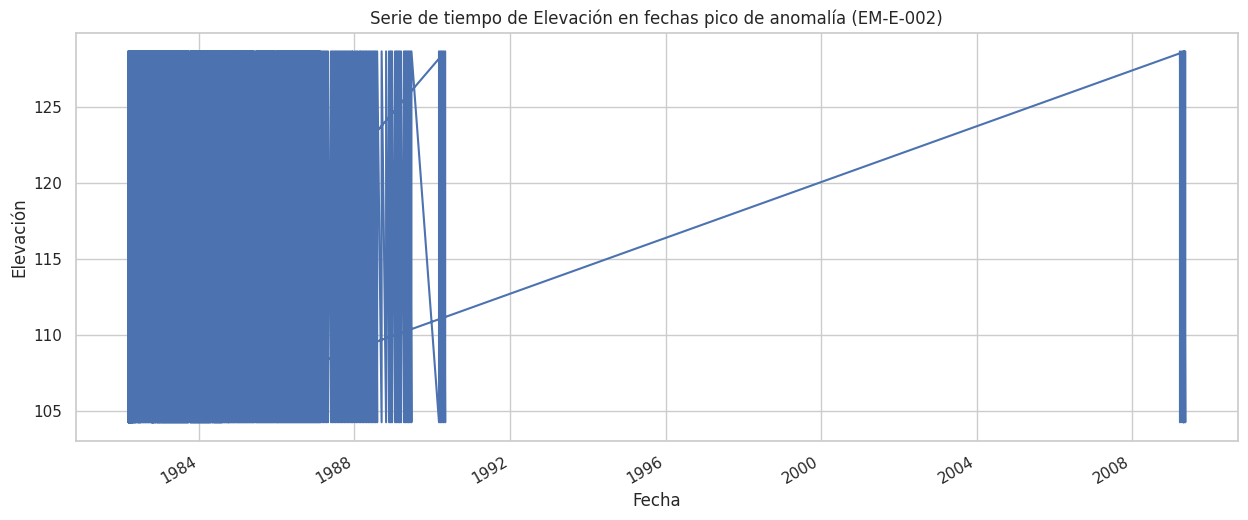

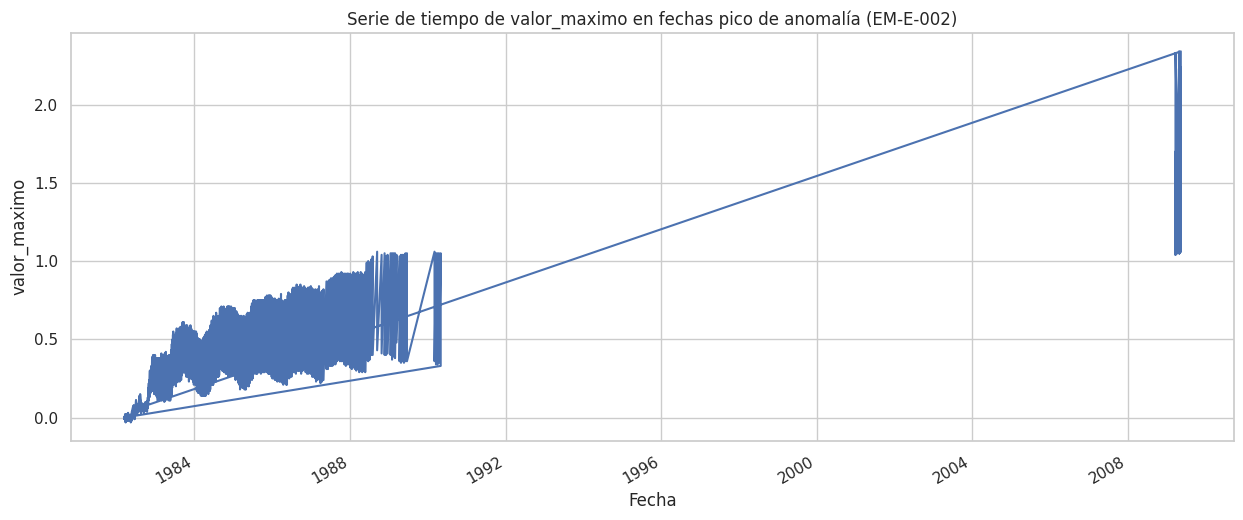

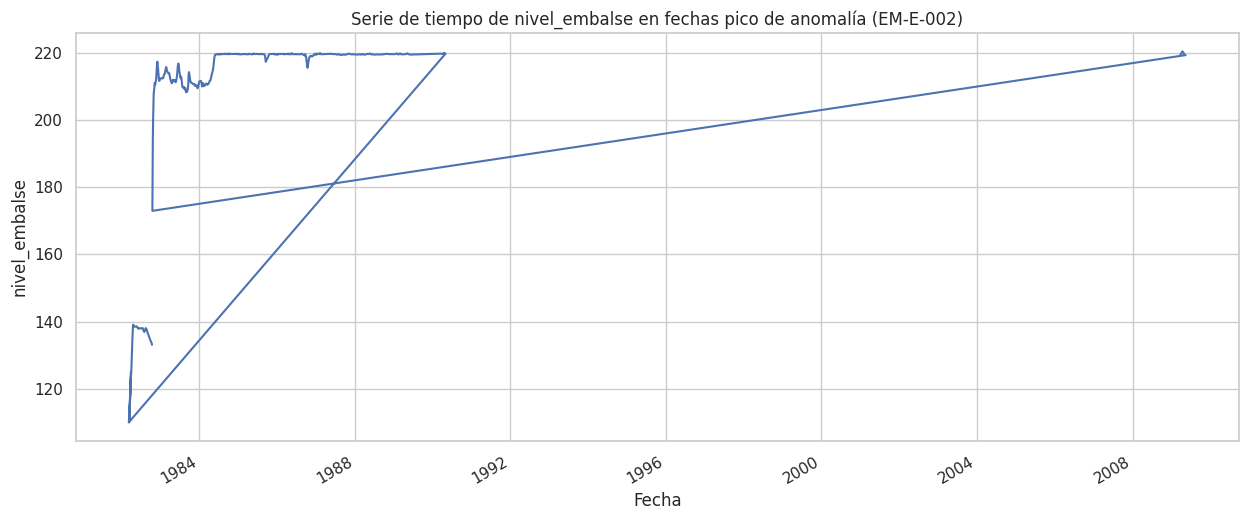

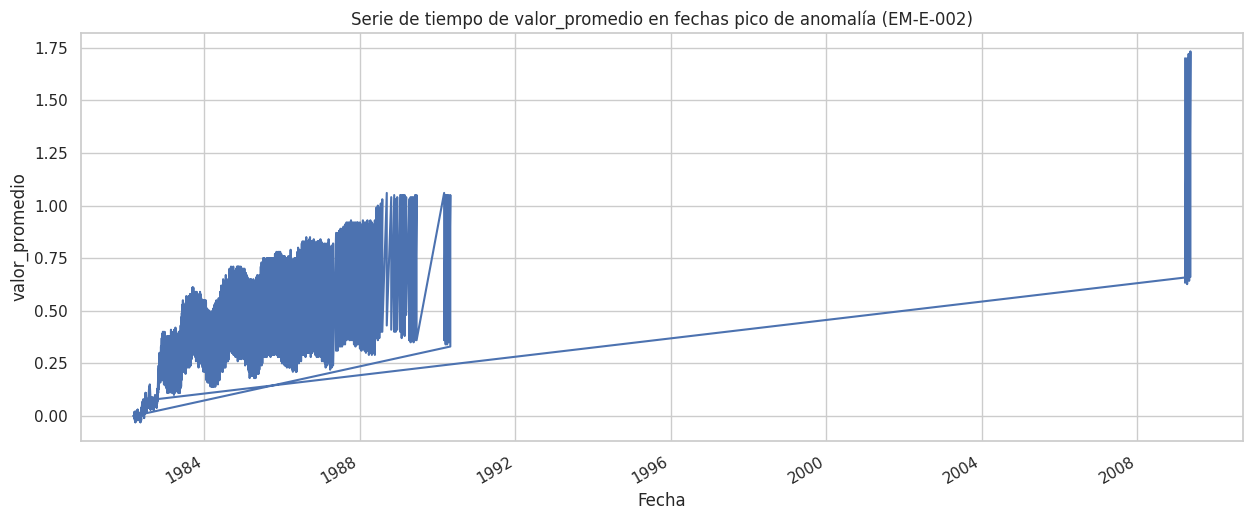

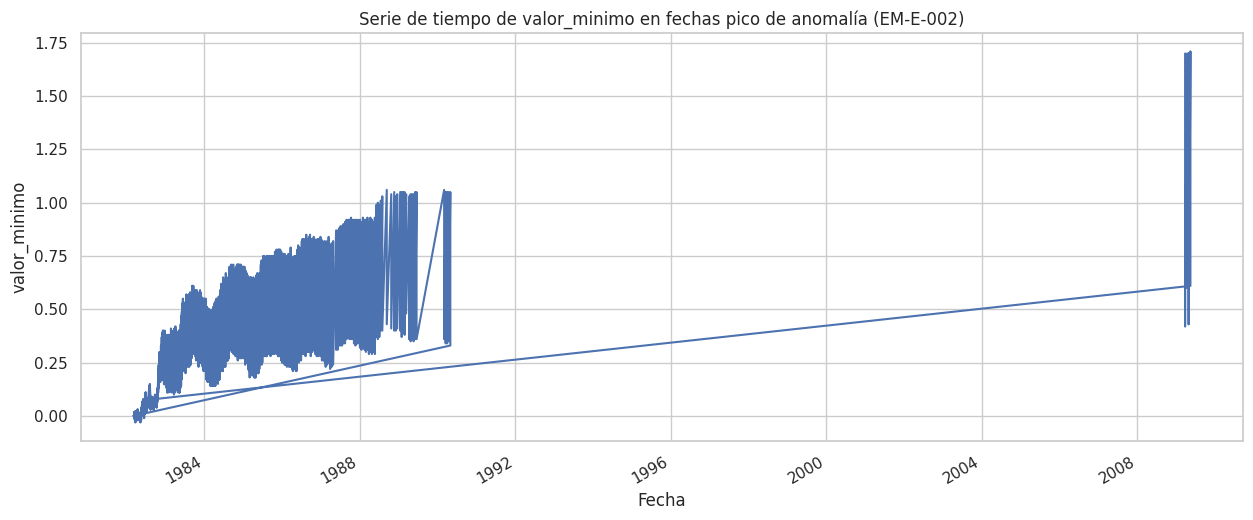


Interpretación de los gráficos de series de tiempo en fechas pico de anomalía (Grupo EM-E-002):
Estos gráficos muestran el comportamiento de características numéricas clave durante los períodos identificados con alto error de reconstrucción.
Observar los patrones en estos gráficos puede ayudar a identificar la causa de los picos de error.
Buscar cambios abruptos, valores inusuales o patrones que difieran significativamente del comportamiento normal esperado de estos sensores.
Por ejemplo, picos o caídas repentinas en 'nivel_embalse' podrían indicar problemas con la medición o eventos externos.


In [28]:
# Crear gráficos de series de tiempo separados para cada una de las columnas numéricas que contribuyeron significativamente
# al error de reconstrucción durante las fechas pico de anomalía.
# Basado en el análisis anterior, estos son 'Elevación', 'valor_maximo', 'nivel_embalse', 'valor_promedio' y 'valor_minimo'.
numerical_cols_to_plot = ['Elevación','valor_maximo', 'nivel_embalse', 'valor_promedio', 'valor_minimo']

for col in numerical_cols_to_plot:
    plt.figure(figsize=(15, 6))
    df_peak_anomalies_eme002[col].plot()
    # Agregar un título a cada gráfico indicando el valor del sensor y que es para fechas pico de anomalía.
    plt.title(f'Serie de tiempo de {col} en fechas pico de anomalía (EM-E-002)')
    # Etiquetar el eje y con el nombre del valor del sensor y el eje x como "Fecha".
    plt.ylabel(col)
    plt.xlabel("Fecha")
    plt.grid(True)
    plt.show()

# Agregar comentarios o declaraciones de impresión para guiar la interpretación de estos gráficos.
print("\nInterpretación de los gráficos de series de tiempo en fechas pico de anomalía (Grupo EM-E-002):")
print("Estos gráficos muestran el comportamiento de características numéricas clave durante los períodos identificados con alto error de reconstrucción.")
print("Observar los patrones en estos gráficos puede ayudar a identificar la causa de los picos de error.")
print("Buscar cambios abruptos, valores inusuales o patrones que difieran significativamente del comportamiento normal esperado de estos sensores.")
print("Por ejemplo, picos o caídas repentinas en 'nivel_embalse' podrían indicar problemas con la medición o eventos externos.")

## Resumen:

### Hallazgos clave del análisis de datos

* La media del error de reconstrucción para el grupo de sensores EM-E-002 es aproximadamente 0.0488, con una desviación estándar de aproximadamente 0.1253.
* Se utilizó un umbral de 0.2995 (media + 2 * desviación estándar) para identificar los picos de error.
* Se identificaron varias fechas en las que el error de reconstrucción superó este umbral, lo que indica posibles anomalías.
* El análisis de los datos originales para estas fechas pico de anomalía reveló que la característica 'Elevación' contribuyó de manera más significativa al error de reconstrucción, seguida de 'valor\_maximo', 'valor', 'valor\_promedio' y 'valor\_minimo'.
* El examen de los datos durante las fechas pico de anomalía mostró inconsistencias en los valores reportados, particularmente en 'Elevación', y una alta prevalencia de datos ingresados manualmente (`tipo_origen_x` y `tipo_origen_y` fueron predominantemente 'MAN').
* Los altos errores de reconstrucción probablemente se deban a problemas de calidad de los datos, potencialmente relacionados con errores de entrada manual o ausencia de datos de 'Elevación' durante los períodos pico identificados.
* Se necesita una investigación adicional sobre las fechas específicas con la mayor contribución al error para comprender el contexto de la entrada manual de datos y las inconsistencias observadas en los valores, especialmente para 'Elevación'.

# DBSCAN

Investigar cómo el algoritmo DBSCAN puede ayudar en la Verificación Espacial de los datos de sensores, aplicando el algoritmo a los datos disponibles y analizando los resultados.

## Preparación de datos espaciales

Si el DataFrame `df_sensores` contiene columnas con información espacial (coordenadas, ubicación), seleccionar y preparar estos datos para el análisis espacial. Si no hay datos espaciales explícitos pero sí información sobre la ubicación (como `local_geologico`), considerar cómo representarla numéricamente o agrupar el análisis por estas categorías.


Inspeccionar el DataFrame `df_sensores` para identificar columnas espaciales y evaluar su completitud. Basado en el análisis previo de `df_peak_anomalies_eme002`, las columnas de coordenadas (`coordenada_norte`, `coordenada_este`, `zona_utm`) tienen muchos valores faltantes. Por lo tanto, es probable que el análisis deba centrarse en la información de ubicación categórica (`local_geologico`).

In [29]:
# 1. Inspeccionar el DataFrame df_sensores en busca de columnas espaciales.
print("Columnas en df_sensores:")
print(df_sensores.columns)

# 2. Evaluar la completitud de las posibles columnas espaciales.
spatial_cols = ['coordenada_norte', 'coordenada_este', 'zona_utm', 'local_geologico']
print("\nConteo de valores no nulos para columnas espaciales en df_sensores:")
print(df_sensores[spatial_cols].notnull().sum())

# 3. Verificar los valores únicos en 'local_geologico' para entender las categorías.
print("\nValores únicos en la columna 'local_geologico':")
print(df_sensores['local_geologico'].unique())

# 4. Basado en el alto número de valores faltantes en las columnas de coordenadas,
# procederemos agrupando el análisis por 'local_geologico'.
# Obtener los valores únicos de 'local_geologico' para preparar el filtrado.
unique_geolocations = df_sensores['local_geologico'].dropna().unique()
print(f"\nCategorías únicas en 'local_geologico' para agrupar el análisis: {unique_geolocations}")

# 5. (Este paso se realizará en subtareas posteriores a medida que procesemos cada grupo)
# Filtrar el DataFrame para cada valor único de 'local_geologico'.
# Ejemplo (no ejecutado en este bloque):
# for location in unique_geolocations:
#     df_location = df_sensores[df_sensores['local_geologico'] == location].copy()
#     # Perform DBSCAN analysis on df_location
#     # Realizar análisis de DBSCAN en df_location

Columnas en df_sensores:
Index(['descripcion_presa_x', 'nombre_etiqueta', 'tipo_etiqueta_x',
       'valor_promedio', 'valor_minimo', 'valor_maximo', 'observacion',
       'tipo_origen_x', 'sigla_unidad_medida_x', 'tipo_presa',
       'tipo_etiqueta_y', 'sigla_presa', 'descripcion_presa_y',
       'sigla_estructura', 'etiqueta_padre', 'referencia', 'orientacion',
       'sigla_unidad_medida_y', 'descripcion_unidad_medida',
       'variable_ingenieria', 'tipo_origen_y', 'local_geologico', 'estado',
       'coordenada_norte', 'coordenada_este', 'zona_utm',
       'familia_tipo_instrumento', 'Elevación',
       'nombre_etiqueta_hidrometeorologica', 'nivel_embalse'],
      dtype='object')

Conteo de valores no nulos para columnas espaciales en df_sensores:
coordenada_norte    26092
coordenada_este     26092
zona_utm            26151
local_geologico     75566
dtype: int64

Valores únicos en la columna 'local_geologico':
['CONTATO D/E' 'ROCHA FRATURADA' 'JUNTA D' 'CONTATO C/D' 'SIN ASIGNAR'


## Selección de características para DBSCAN

Decidir qué características de los datos de los sensores (además o en lugar de la ubicación espacial) se utilizarán para el clustering con DBSCAN (por ejemplo, `valor_promedio`, error de reconstrucción de PCA).

Aplicar DBSCAN por grupo geológico, analizar y visualizar los resultados, y consolidar los hallazgos para la verificación espacial.

Iterar sobre cada valor único en la columna `local_geologico`, filtrar el DataFrame `df_sensores` para cada grupo geológico, seleccionar y escalar las características relevantes para el clustering, aplicar el algoritmo DBSCAN ajustando los parámetros `eps` y `min_samples`, y almacenar los resultados del clustering para cada grupo.


In [30]:
from sklearn.cluster import DBSCAN

# Lista para almacenar resultados por ubicación
dbscan_results_by_location = {}

# Seleccionar características relevantes para DBSCAN.
# Basado en análisis previos y sentido común para datos de sensores.
# Utilizaremos 'valor_promedio', 'valor_minimo', 'valor_maximo', 'Elevación' y 'nivel_embalse'.
# NO incluiremos el error de reconstrucción aquí, ya que se calculó para un grupo específico (EM-E-002)
# y fusionarlo para todos los tipos de sensores podría no ser sencillo o significativo
# sin una investigación adicional.
features_for_dbscan = ['valor_promedio', 'valor_minimo', 'valor_maximo', 'Elevación', 'nivel_embalse']

# Iterar a través de cada ubicación geológica única
for location in unique_geolocations:
    print(f"Procesando ubicación: {location}")

    # Filtrar el DataFrame para la ubicación actual
    df_location = df_sensores[df_sensores['local_geologico'] == location].copy()

    # Manejar valores faltantes para las características seleccionadas
    df_location_cleaned = df_location.dropna(subset=features_for_dbscan)

    # Verificar si hay suficientes puntos de datos después de eliminar NaNs para clustering
    if len(df_location_cleaned) < 5: # DBSCAN requiere al menos min_samples puntos de datos
        print(f"No hay suficientes puntos de datos para DBSCAN en la ubicación {location}. Saltando.")
        continue

    # Seleccionar y escalar las características
    scaled_data_location = StandardScaler().fit_transform(df_location_cleaned[features_for_dbscan])

    # Aplicar DBSCAN. Estos parámetros pueden necesitar ajuste basado en la distribución de los datos
    # y la definición de una anomalía espacial.
    dbscan = DBSCAN(eps=0.5, min_samples=5) # Parámetros iniciales, probar otros
    dbscan_labels_location = dbscan.fit_predict(scaled_data_location)

    # Agregar etiquetas de clúster al DataFrame limpio
    df_location_cleaned['dbscan_label'] = dbscan_labels_location

    # Almacenar los resultados
    dbscan_results_by_location[location] = df_location_cleaned

print("\nAnálisis de DBSCAN completado para todas las ubicaciones geográficas.")
# Mostrar las primeras filas de resultados para una ubicación como ejemplo
if dbscan_results_by_location:
    first_location = list(dbscan_results_by_location.keys())[0]
    print(f"\nEjemplo de resultados para la ubicación '{first_location}':")
    display(dbscan_results_by_location[first_location].head())
else:
    print("\nNinguna ubicación tuvo suficientes puntos de datos para DBSCAN.")

Procesando ubicación: CONTATO D/E


/tmp/ipython-input-2126121367.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Procesando ubicación: ROCHA FRATURADA


/tmp/ipython-input-2126121367.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Procesando ubicación: JUNTA D


...

Procesando ubicación: CONTATO CONCRETO/ROCHA
Procesando ubicación: BRECHA D


/tmp/ipython-input-2126121367.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location
/tmp/ipython-input-2126121367.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Procesando ubicación: BRECHA C
Procesando ubicación: DERRAME D

Análisis de DBSCAN completado para todas las ubicaciones geográficas.

Ejemplo de resultados para la ubicación 'CONTATO D/E':


/tmp/ipython-input-2126121367.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse,dbscan_label
fecha,,,,,,,,,,,,,,,,,,,,,
2005-10-27,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.229500,6.22,6.23,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.26,0
2005-10-28,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.241667,6.23,6.25,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.29,0
2005-10-29,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.249583,6.23,6.26,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.36,0
2005-10-30,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.258750,6.24,6.28,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.38,0
2005-10-31,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.269167,6.25,6.29,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.31,0


El clustering DBSCAN se ha aplicado a cada grupo de ubicación geológica. El siguiente paso es analizar e interpretar los resultados del clustering para cada grupo, centrándose en los clústeres identificados y los puntos de ruido (etiqueta -1).

In [31]:
# 1. Iterar a través de los resultados almacenados en dbscan_results_by_location.
print("\nAnálisis de los resultados de DBSCAN por grupo geológico:")

for location, df_result in dbscan_results_by_location.items():
    print(f"\n--- Grupo Geológico: {location} ---")

    # 2. Para cada grupo, analizar la distribución de las etiquetas de clúster.
    # Contar el número de puntos de datos en cada clúster, incluyendo el ruido (-1).
    print(f"\nDistribución de etiquetas de clúster para '{location}':")
    display(df_result['dbscan_label'].value_counts())

    # 3. Identificar los puntos de ruido (puntos de datos con etiqueta -1).
    noise_points = df_result[df_result['dbscan_label'] == -1]
    print(f"\nPuntos de ruido (posibles anomalías espaciales) en '{location}':")
    print(f"Número de puntos de ruido: {len(noise_points)}")

    # 4. Examinar las características de los puntos de ruido (por ejemplo, sus valores de sensor).
    if not noise_points.empty:
        print(f"\nEstadísticas descriptivas de los puntos de ruido en '{location}':")
        display(noise_points[features_for_dbscan].describe())

        # Opcionalmente, mostrar algunos de los puntos de ruido
        print(f"\nEjemplos de puntos de ruido en '{location}':")
        display(noise_points.head())

    # 5. Analizar las características de los clústeres identificados (por ejemplo, valores promedio de los sensores para cada clúster).
    # Excluir puntos de ruido (-1) del análisis de clústeres.
    clusters = df_result[df_result['dbscan_label'] != -1]
    if not clusters.empty:
        print(f"\nEstadísticas descriptivas por clúster (excluyendo ruido) en '{location}':")
        display(clusters.groupby('dbscan_label')[features_for_dbscan].mean())

    # 6. Considerar visualizar los resultados del clustering si la dimensionalidad es baja o utilizando técnicas de reducción de dimensionalidad.
    # Para 5 características, la representación gráfica directa en 2D/3D no es ideal. Omitiremos la visualización directa aquí
    # y nos basaremos en el análisis estadístico de clústeres y ruido.

    # 7. Agregar comentarios o declaraciones de impresión para interpretar los resultados de cada grupo.
    print(f"\nInterpretación para '{location}':")
    if len(noise_points) > 0:
        print(f"Se identificaron {len(noise_points)} puntos de ruido (etiqueta -1), que pueden ser considerados anomalías espaciales para este grupo.")
        print("Estos puntos de ruido son datos que DBSCAN considera que no pertenecen a ningún clúster denso.")
    else:
        print("No se identificaron puntos de ruido (etiqueta -1) en este grupo. Todos los puntos fueron asignados a clústeres o considerados puntos centrales/frontera.")
    print("Los clústeres identificados representan grupos de puntos de datos con características de sensor similares dentro de esta ubicación geológica.")
    print("La comparación de las estadísticas de los puntos de ruido con las estadísticas de los clústeres puede ayudar a entender por qué son considerados anomalías.")

    # Agregar código para guardar los resultados de clustering en un archivo Excel para cada ubicación
    output_file_path = f'dbscan_results_{location.replace(" ", "_").replace("/", "-")}.xlsx'
    df_result.to_excel(output_file_path)
    print(f"\nResultados de DBSCAN para '{location}' guardados en '{output_file_path}'")


Análisis de los resultados de DBSCAN por grupo geológico:

--- Grupo Geológico: CONTATO D/E ---

Distribución de etiquetas de clúster para 'CONTATO D/E':


,count
dbscan_label,
1,8984
0,4496
6,835
4,112
3,66
5,57
-1,23
2,7



Puntos de ruido (posibles anomalías espaciales) en 'CONTATO D/E':
Número de puntos de ruido: 23

Estadísticas descriptivas de los puntos de ruido en 'CONTATO D/E':


,valor_promedio,valor_minimo,valor_maximo,Elevación,nivel_embalse
count,23.000000,23.000000,23.000000,23.000000,23.000000
mean,-0.026957,-0.026957,-0.026957,130.091739,165.366957
std,0.189003,0.189003,0.189003,1.559941,43.902634
min,-0.290000,-0.290000,-0.290000,128.690000,59.170000
25%,-0.120000,-0.120000,-0.120000,128.690000,153.100000
50%,-0.100000,-0.100000,-0.100000,129.650000,185.990000
75%,0.105000,0.105000,0.105000,132.120000,193.640000
max,0.500000,0.500000,0.500000,132.120000,198.820000



Ejemplos de puntos de ruido en 'CONTATO D/E':


...


Interpretación para 'BRECHA C':
No se identificaron puntos de ruido (etiqueta -1) en este grupo. Todos los puntos fueron asignados a clústeres o considerados puntos centrales/frontera.
Los clústeres identificados representan grupos de puntos de datos con características de sensor similares dentro de esta ubicación geológica.
La comparación de las estadísticas de los puntos de ruido con las estadísticas de los clústeres puede ayudar a entender por qué son considerados anomalías.

Resultados de DBSCAN para 'BRECHA C' guardados en 'dbscan_results_BRECHA_C.xlsx'

--- Grupo Geológico: DERRAME D ---

Distribución de etiquetas de clúster para 'DERRAME D':


,count
dbscan_label,
1,1256
3,1256
0,113
2,113



Puntos de ruido (posibles anomalías espaciales) en 'DERRAME D':
Número de puntos de ruido: 0

Estadísticas descriptivas por clúster (excluyendo ruido) en 'DERRAME D':


,valor_promedio,valor_minimo,valor_maximo,Elevación,nivel_embalse
dbscan_label,,,,,
0,134.282202,134.282202,134.282202,130.8,116.244602
1,160.883965,160.883567,160.884363,130.8,218.097102
2,3.482202,3.482202,3.482202,130.8,116.244602
3,30.083965,30.083567,30.084363,130.8,218.097102



Interpretación para 'DERRAME D':
No se identificaron puntos de ruido (etiqueta -1) en este grupo. Todos los puntos fueron asignados a clústeres o considerados puntos centrales/frontera.
Los clústeres identificados representan grupos de puntos de datos con características de sensor similares dentro de esta ubicación geológica.
La comparación de las estadísticas de los puntos de ruido con las estadísticas de los clústeres puede ayudar a entender por qué son considerados anomalías.

Resultados de DBSCAN para 'DERRAME D' guardados en 'dbscan_results_DERRAME_D.xlsx'


## Visualizar los resultados de dbscan por grupo

Para cada grupo geológico, visualizar los resultados del clustering. Esto podría implicar gráficos de dispersión de las características utilizadas para el clustering, coloreando los puntos según su etiqueta de cluster.


Iterar a través del diccionario `dbscan_results_by_location`, preparar los datos para la visualización, seleccionar las características utilizadas para DBSCAN, crear gráficos de dispersión para pares de características seleccionadas, colorear los puntos por etiqueta de clúster, añadir títulos y etiquetas, y mostrar los gráficos.


--- Visualización de Clustering DBSCAN para: CONTATO D/E ---


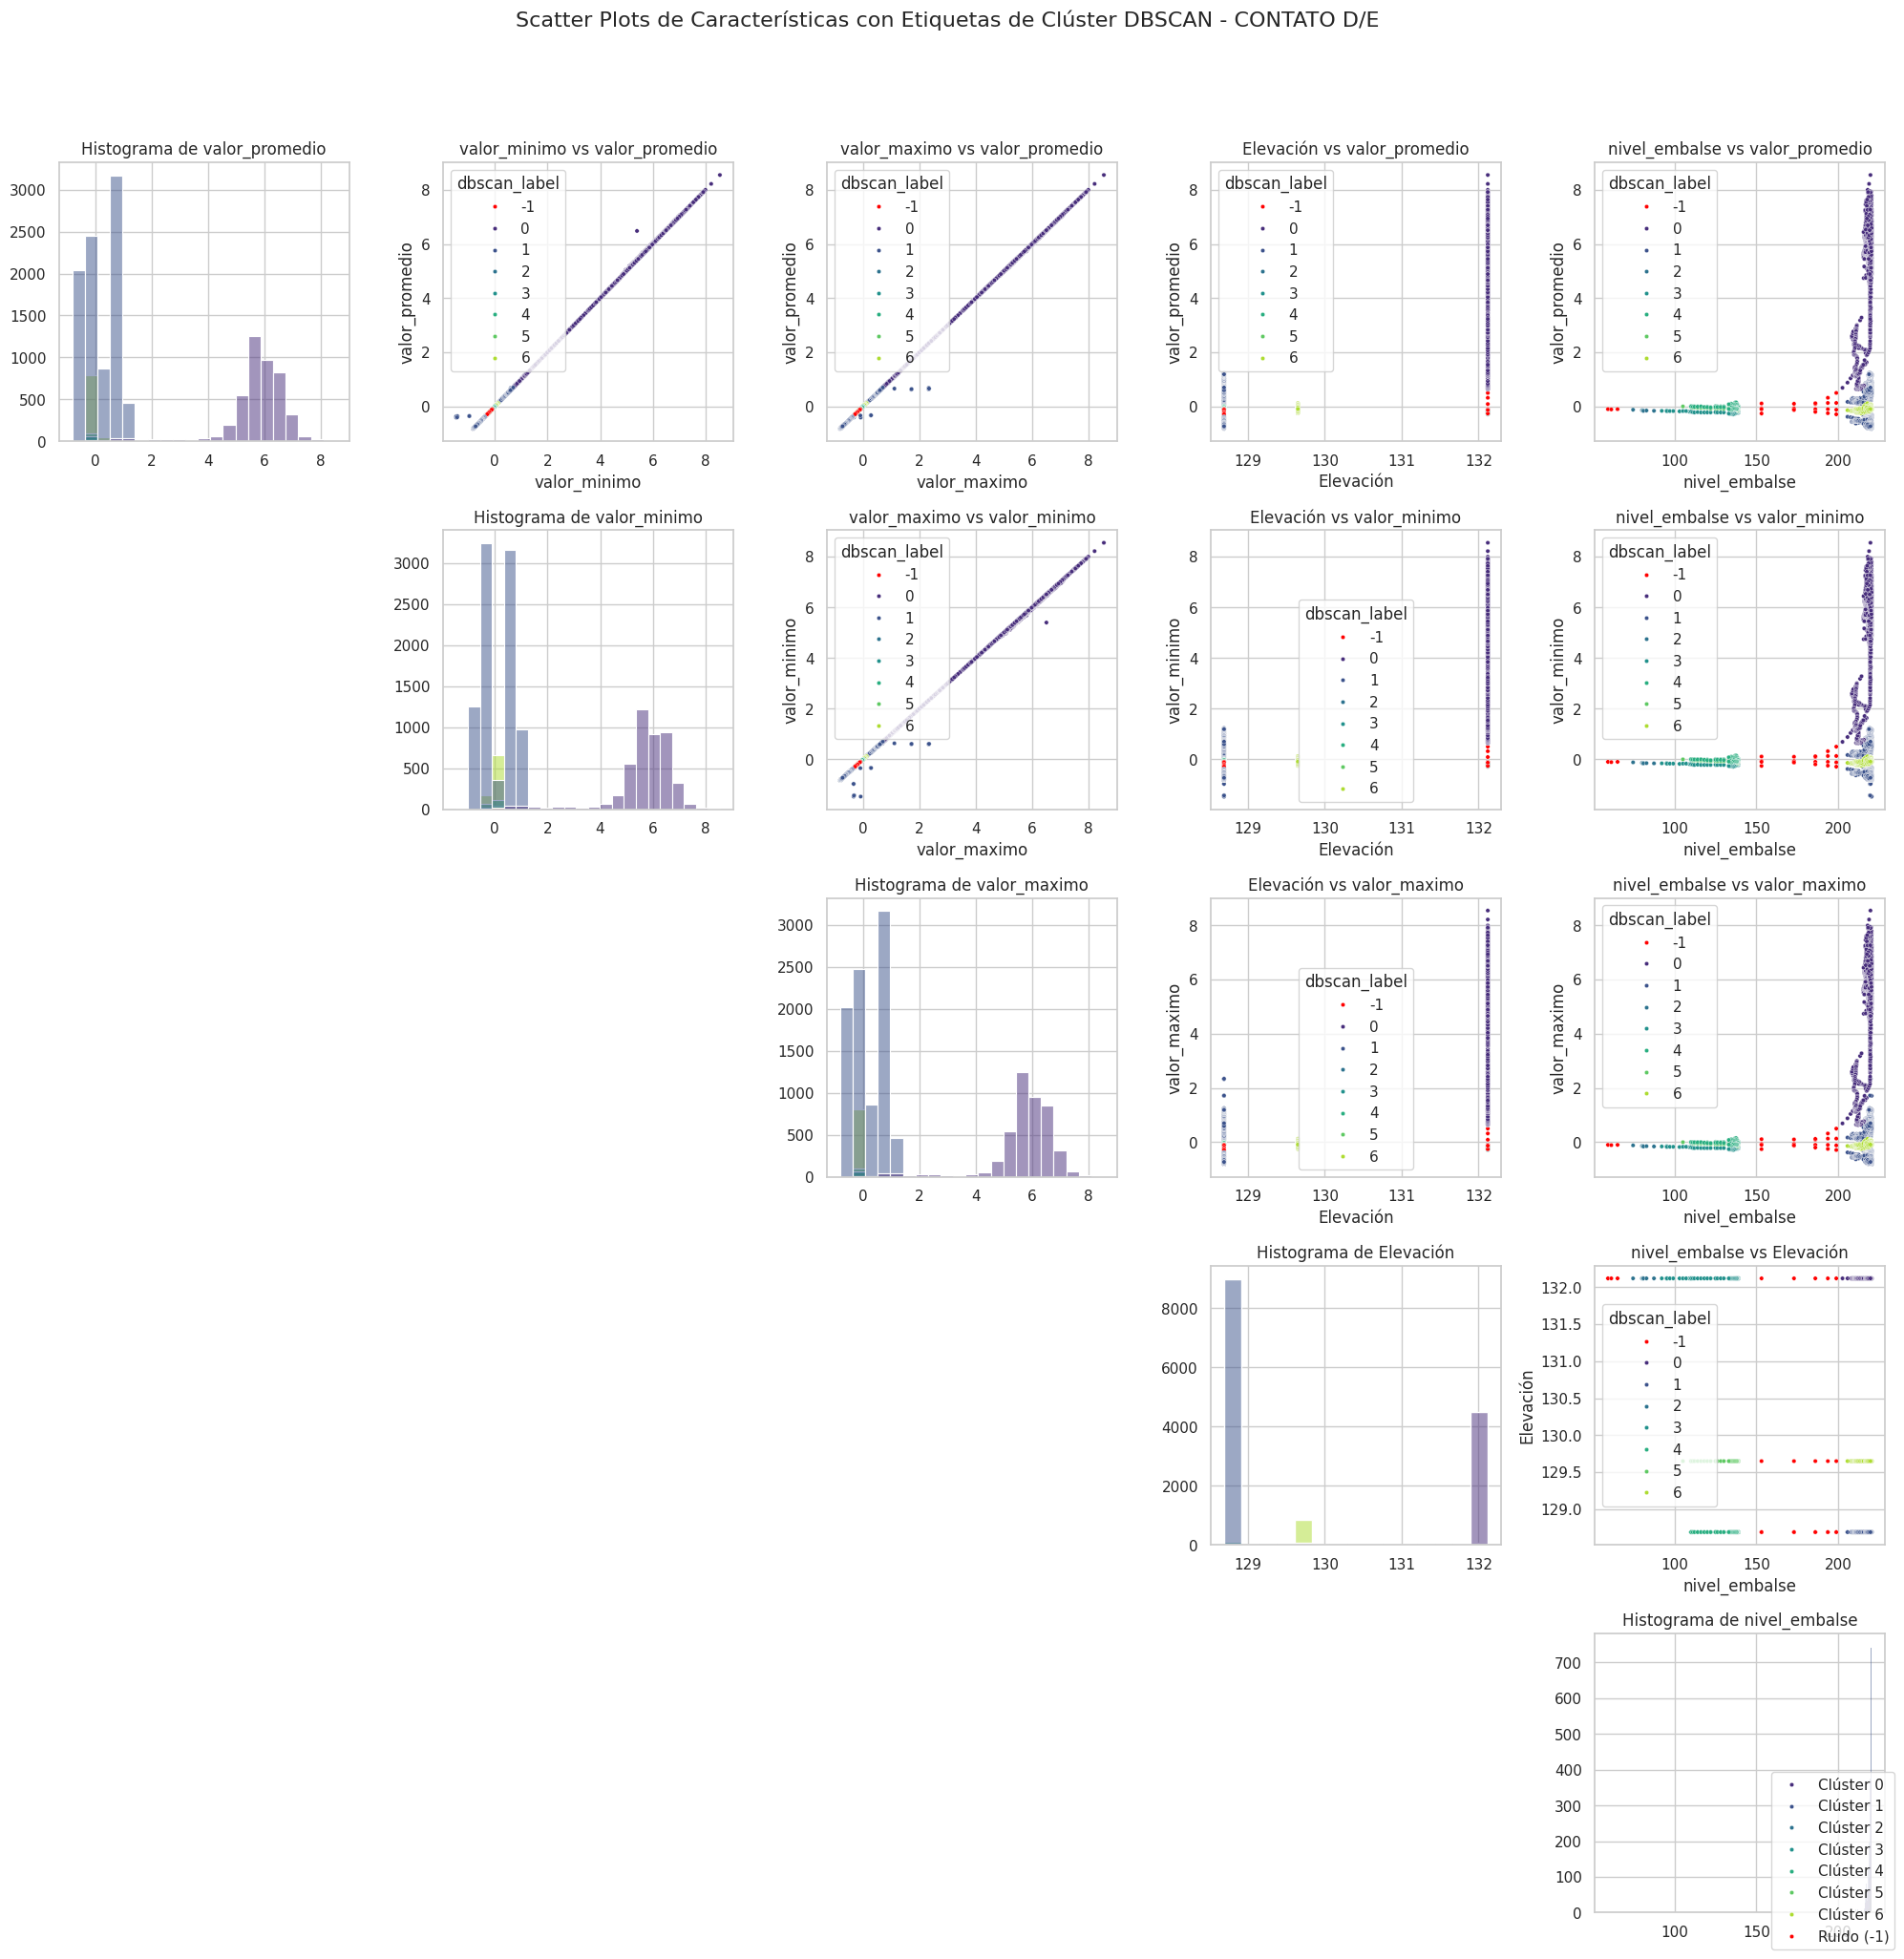


Interpretación de los gráficos de dispersión para 'CONTATO D/E':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: ROCHA FRATURADA ---


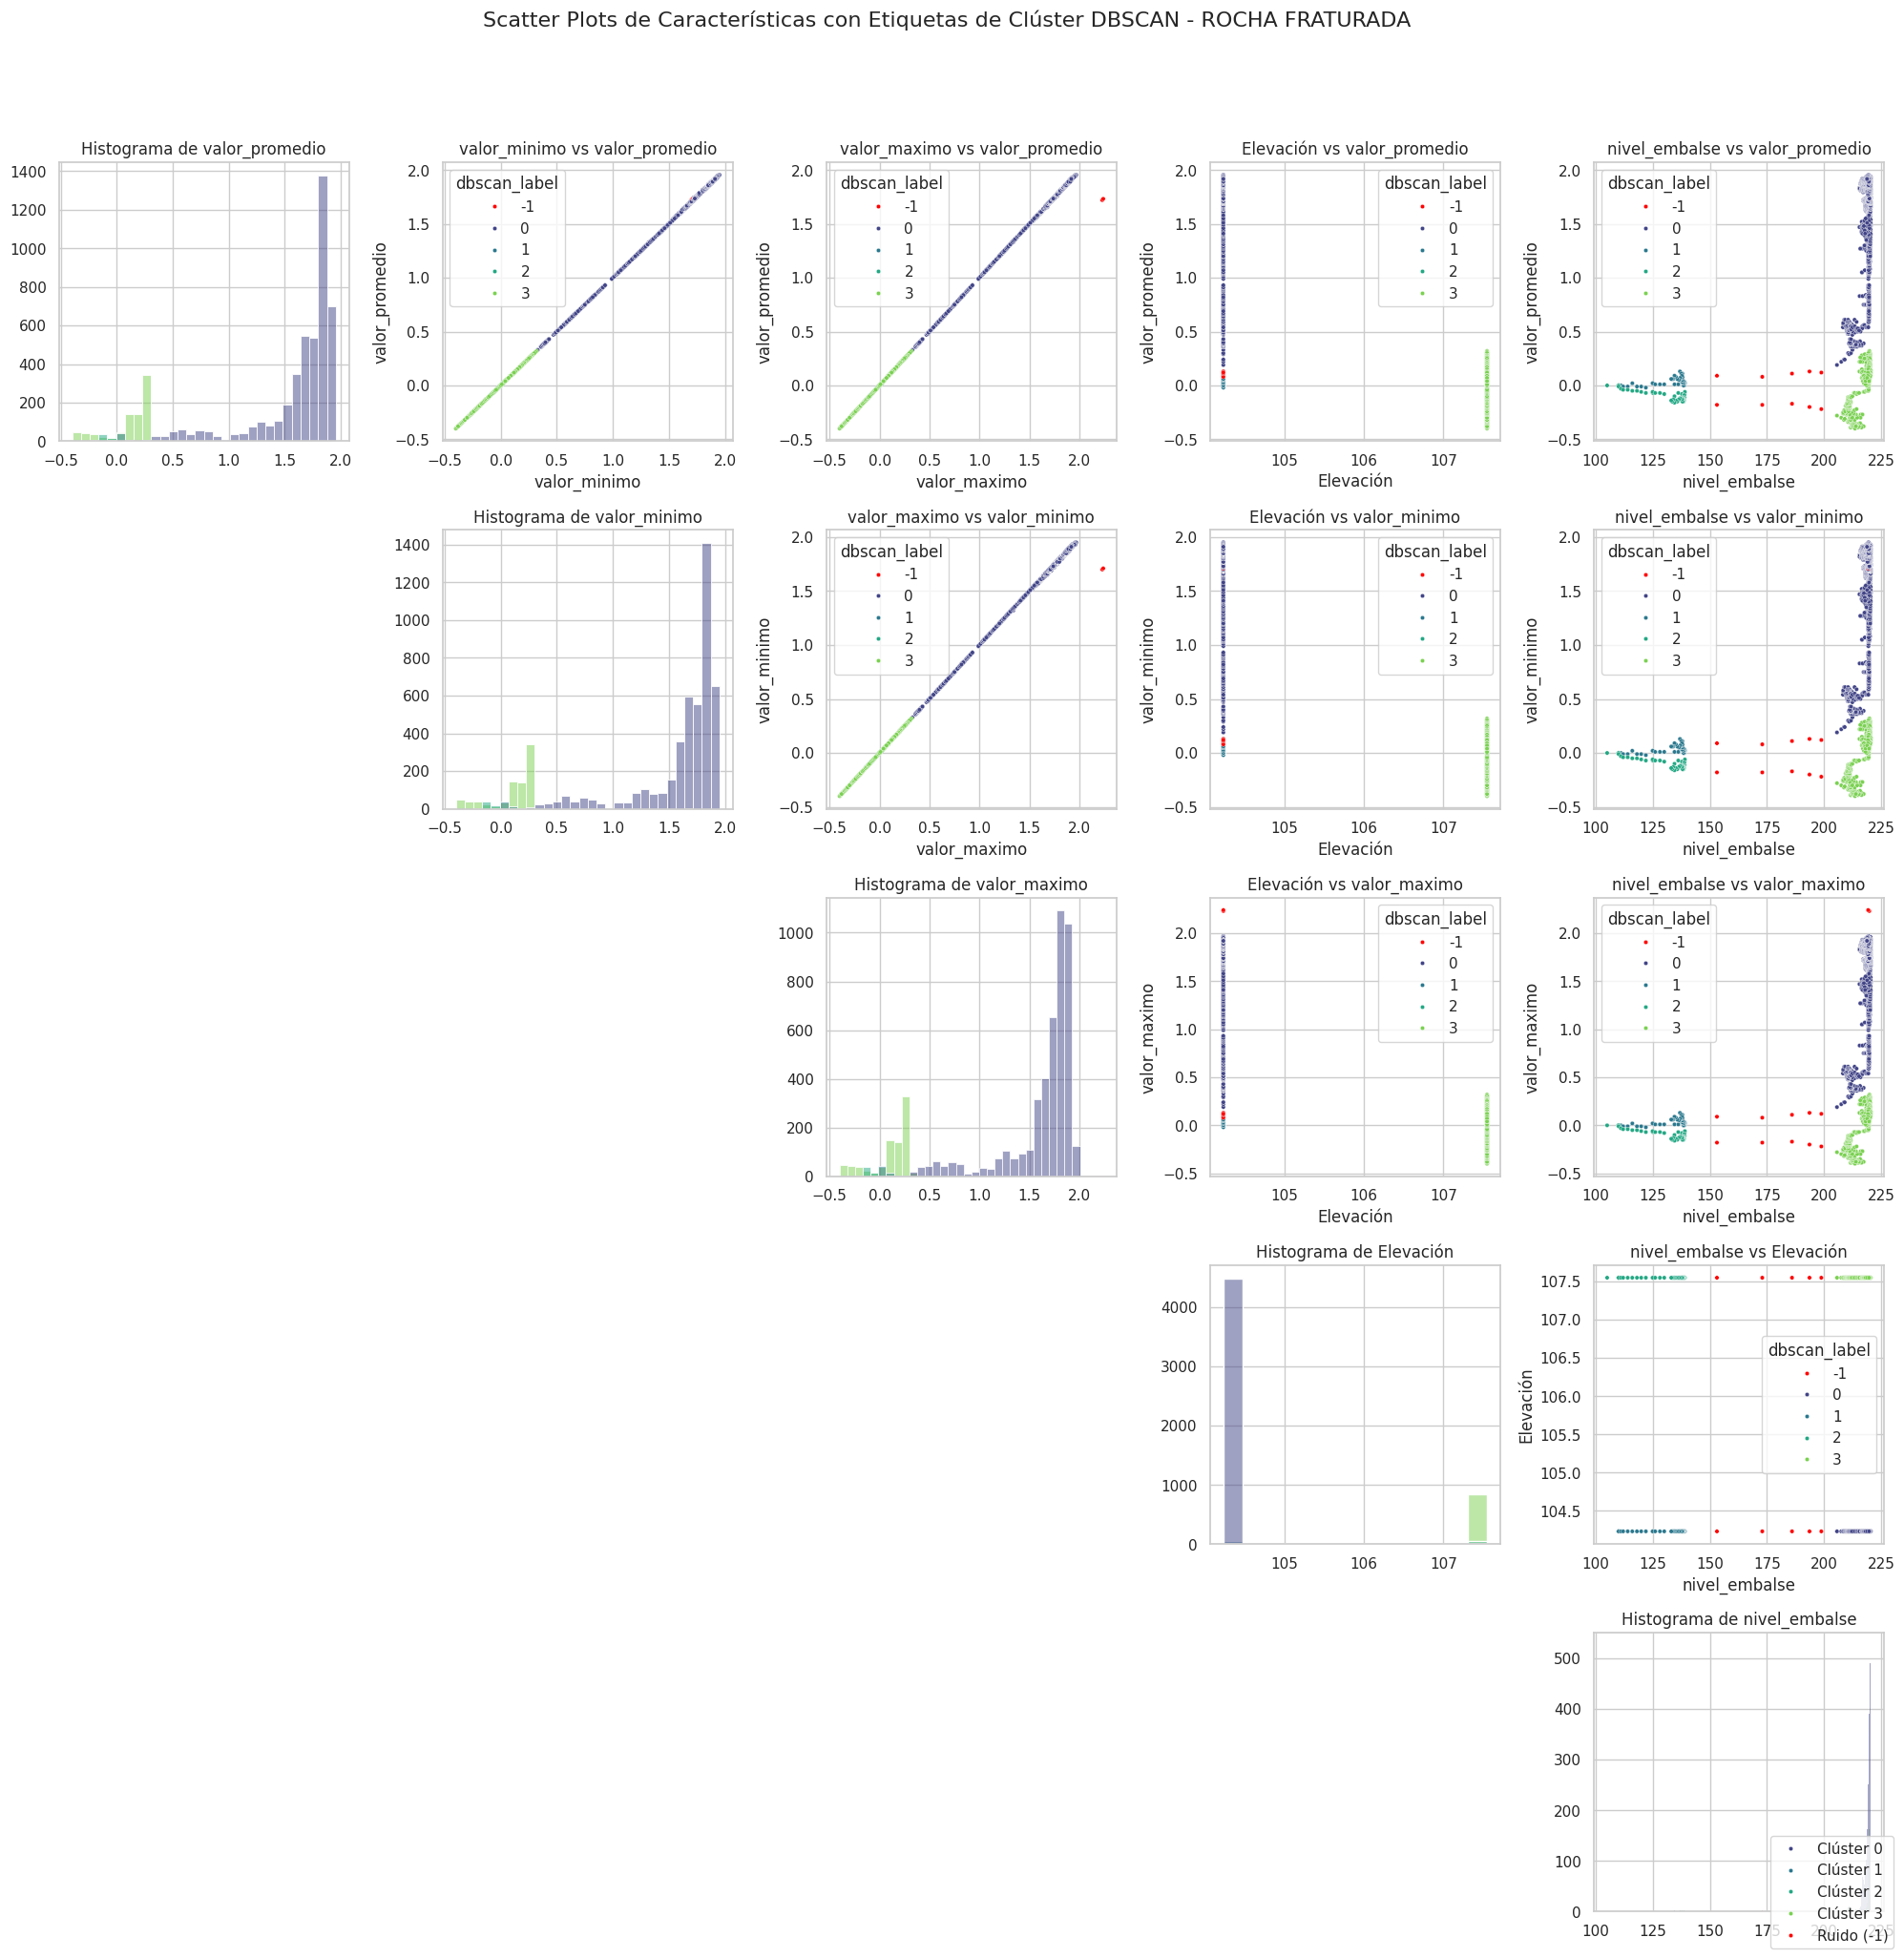


Interpretación de los gráficos de dispersión para 'ROCHA FRATURADA':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: JUNTA D ---


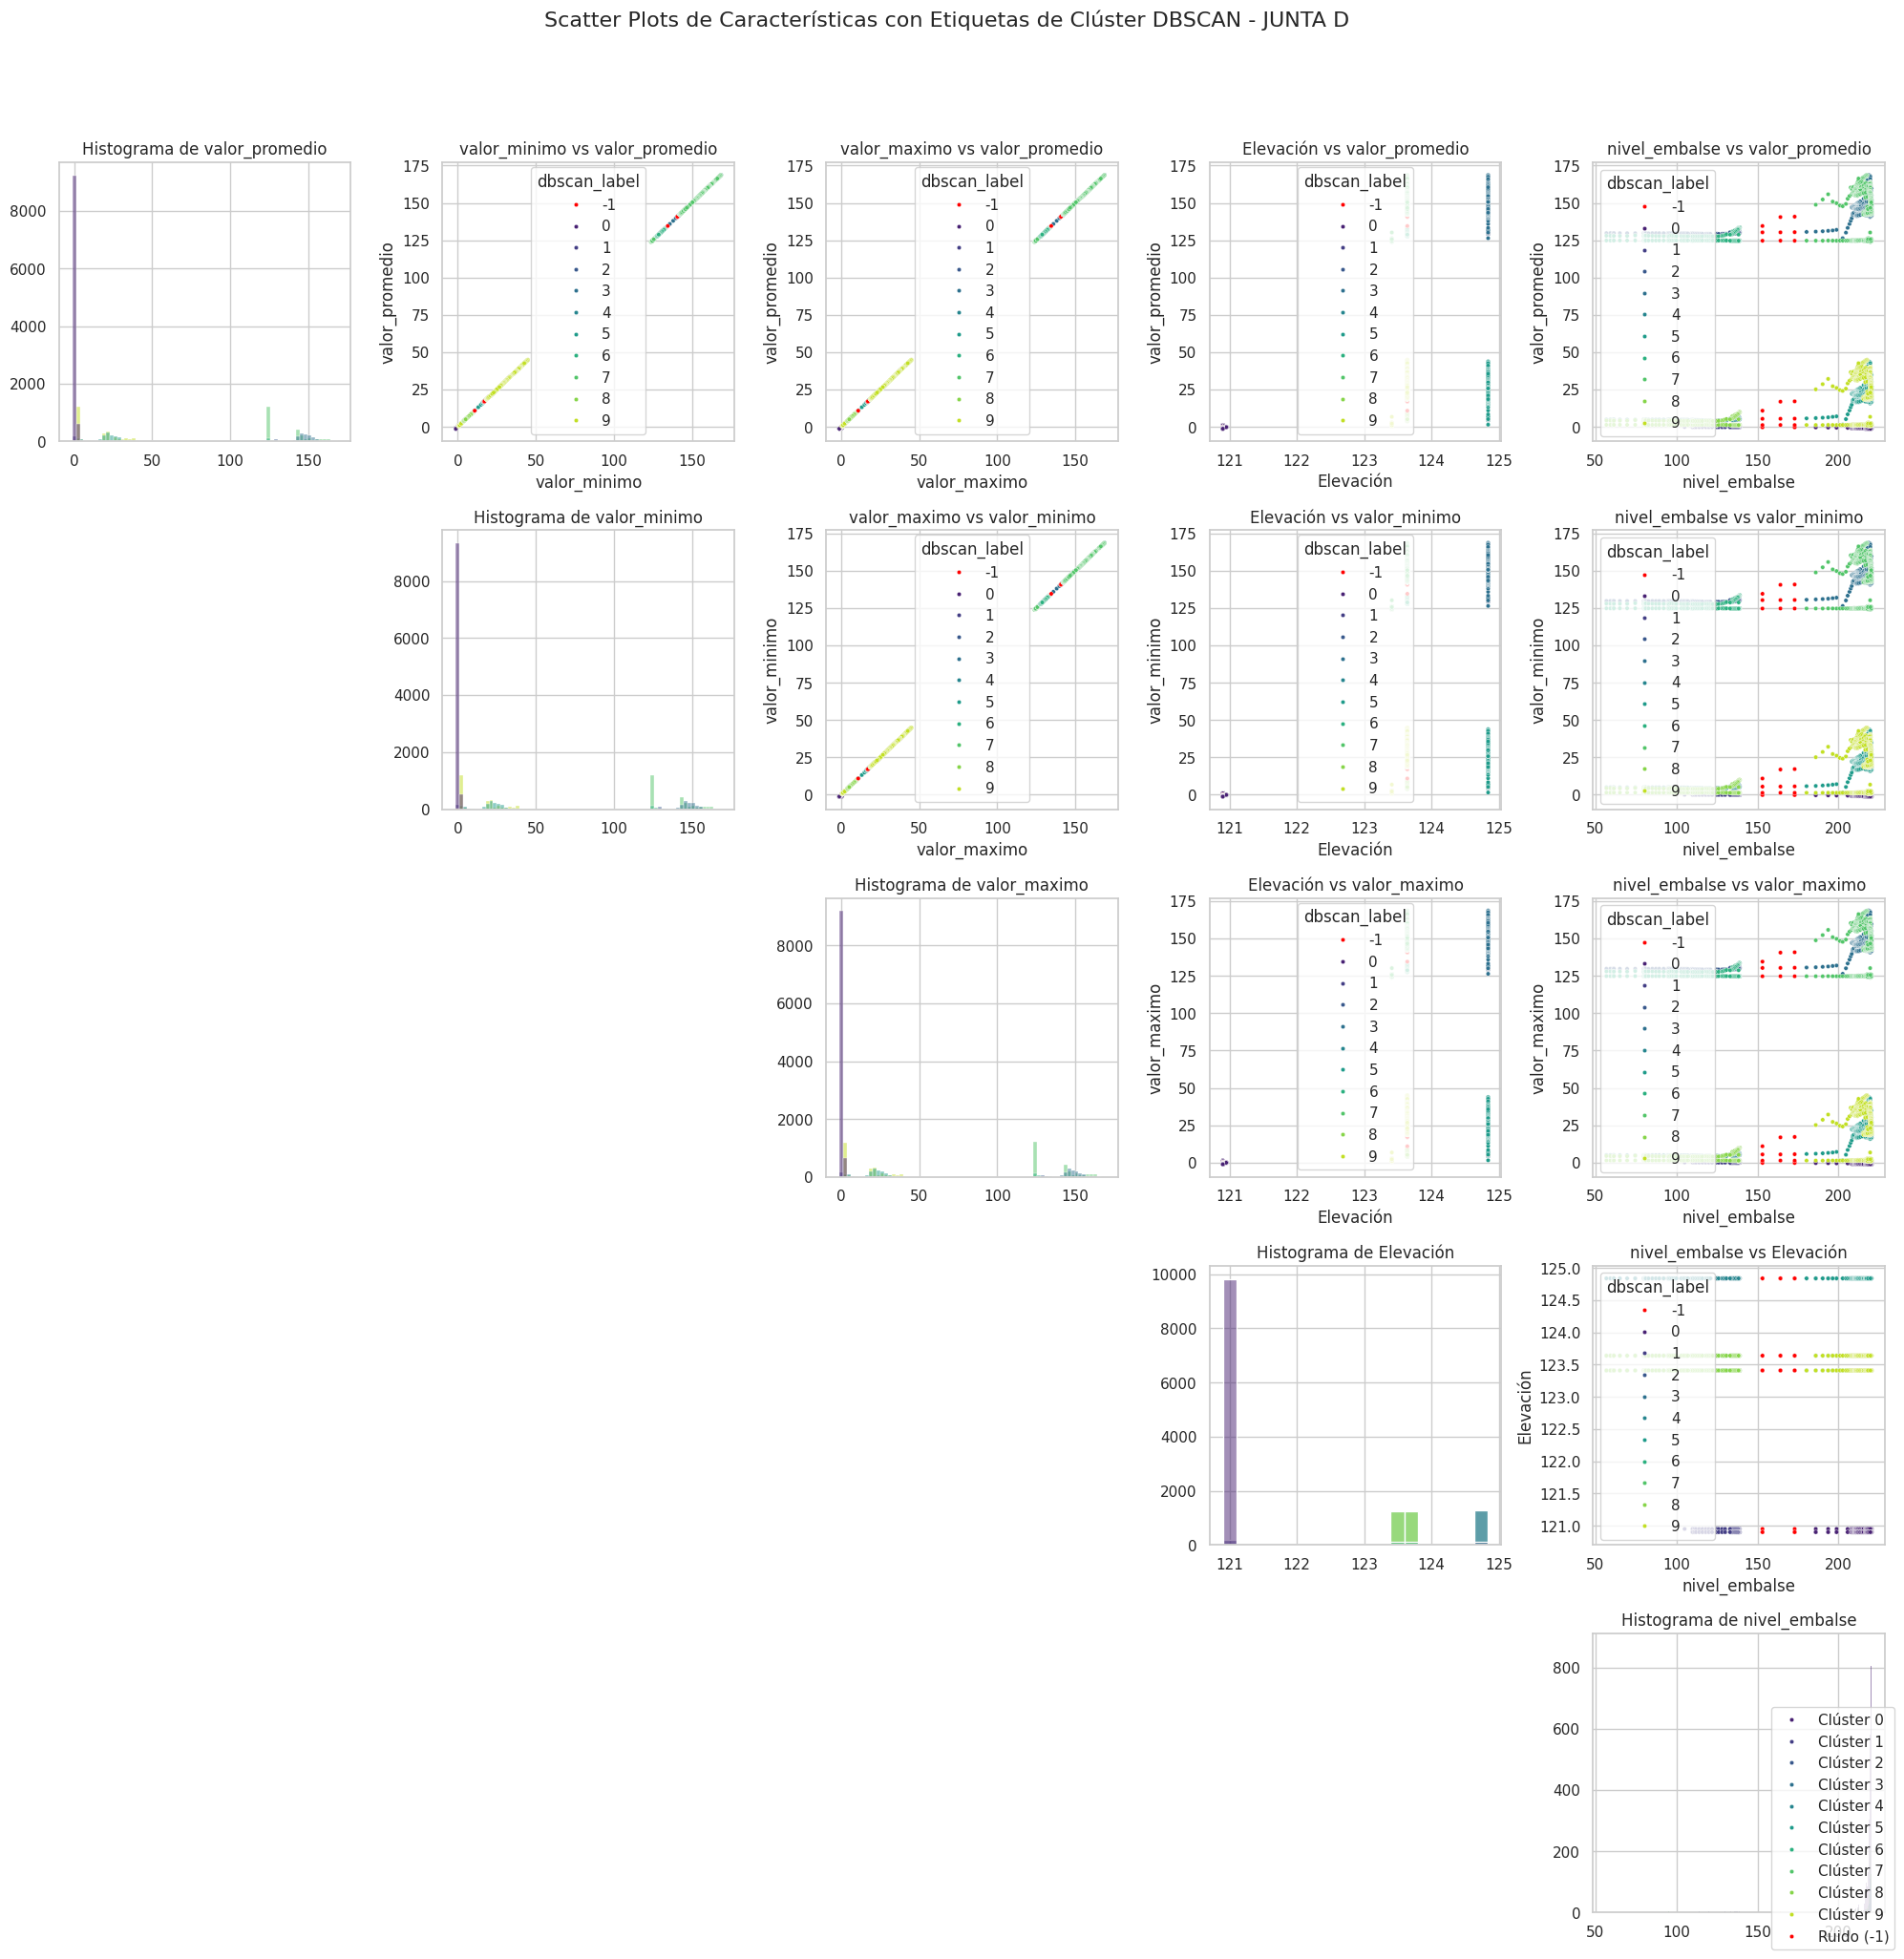


Interpretación de los gráficos de dispersión para 'JUNTA D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: CONTATO C/D ---


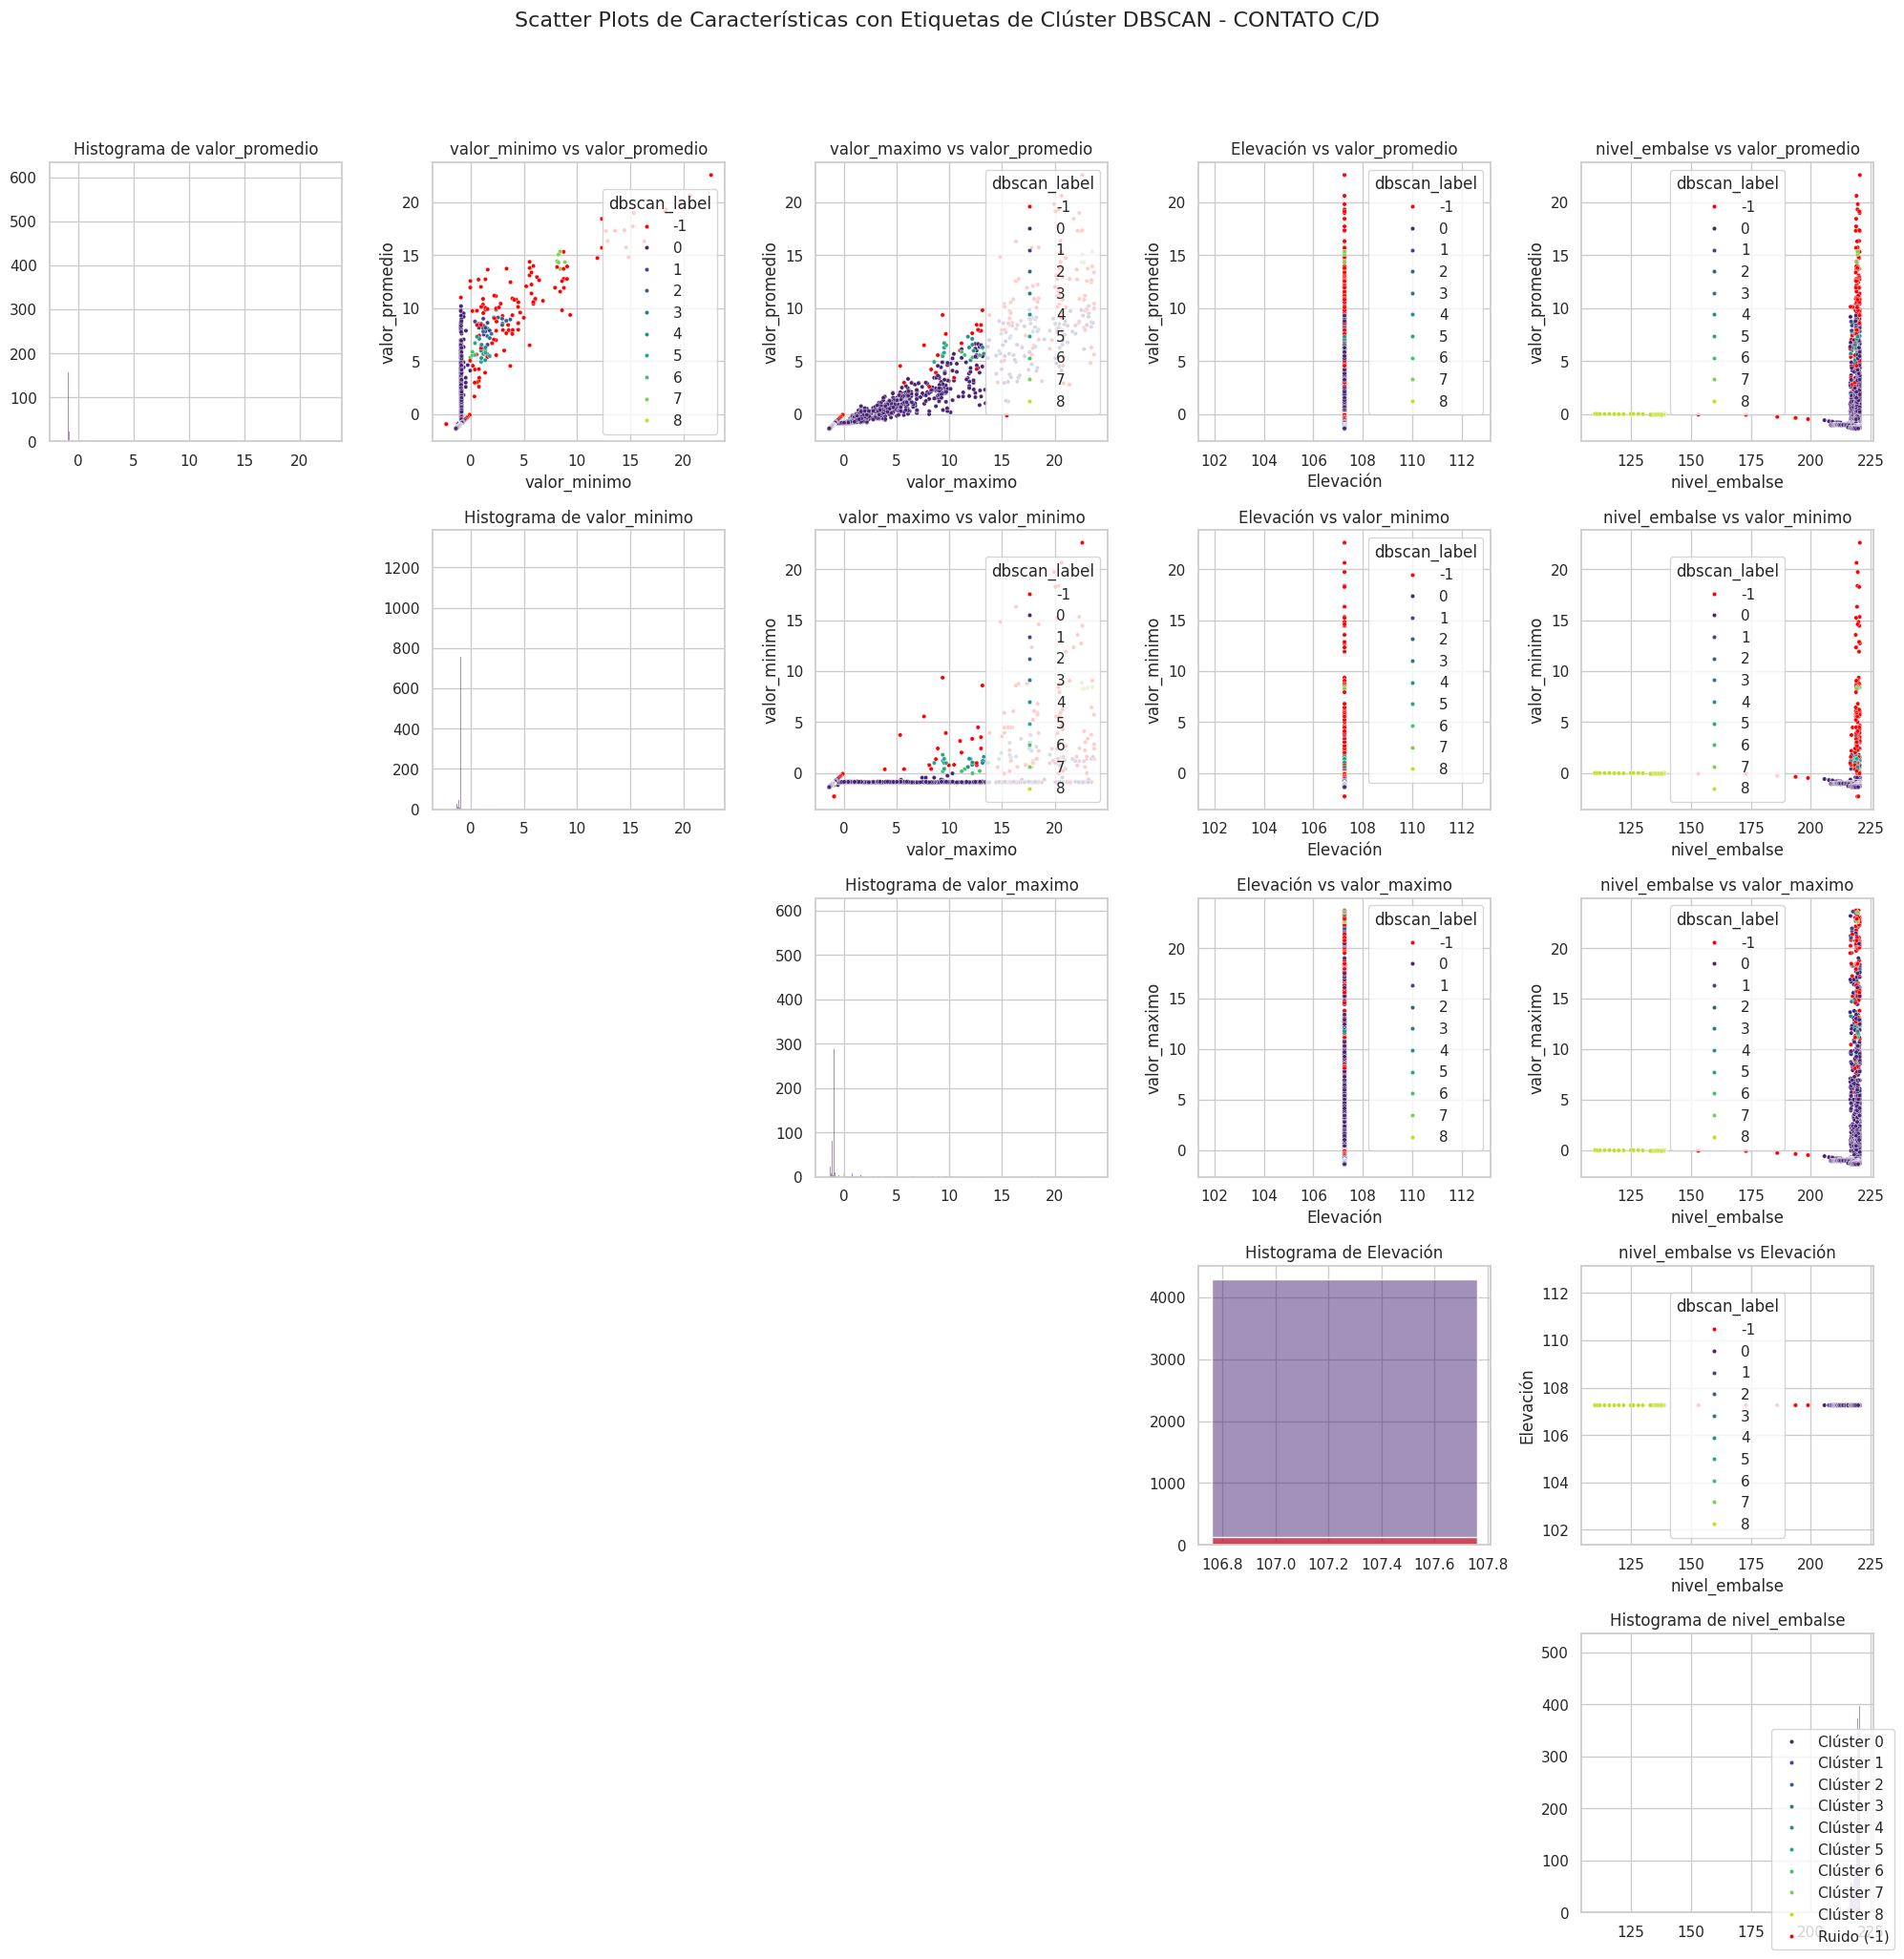


Interpretación de los gráficos de dispersión para 'CONTATO C/D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: SIN ASIGNAR ---


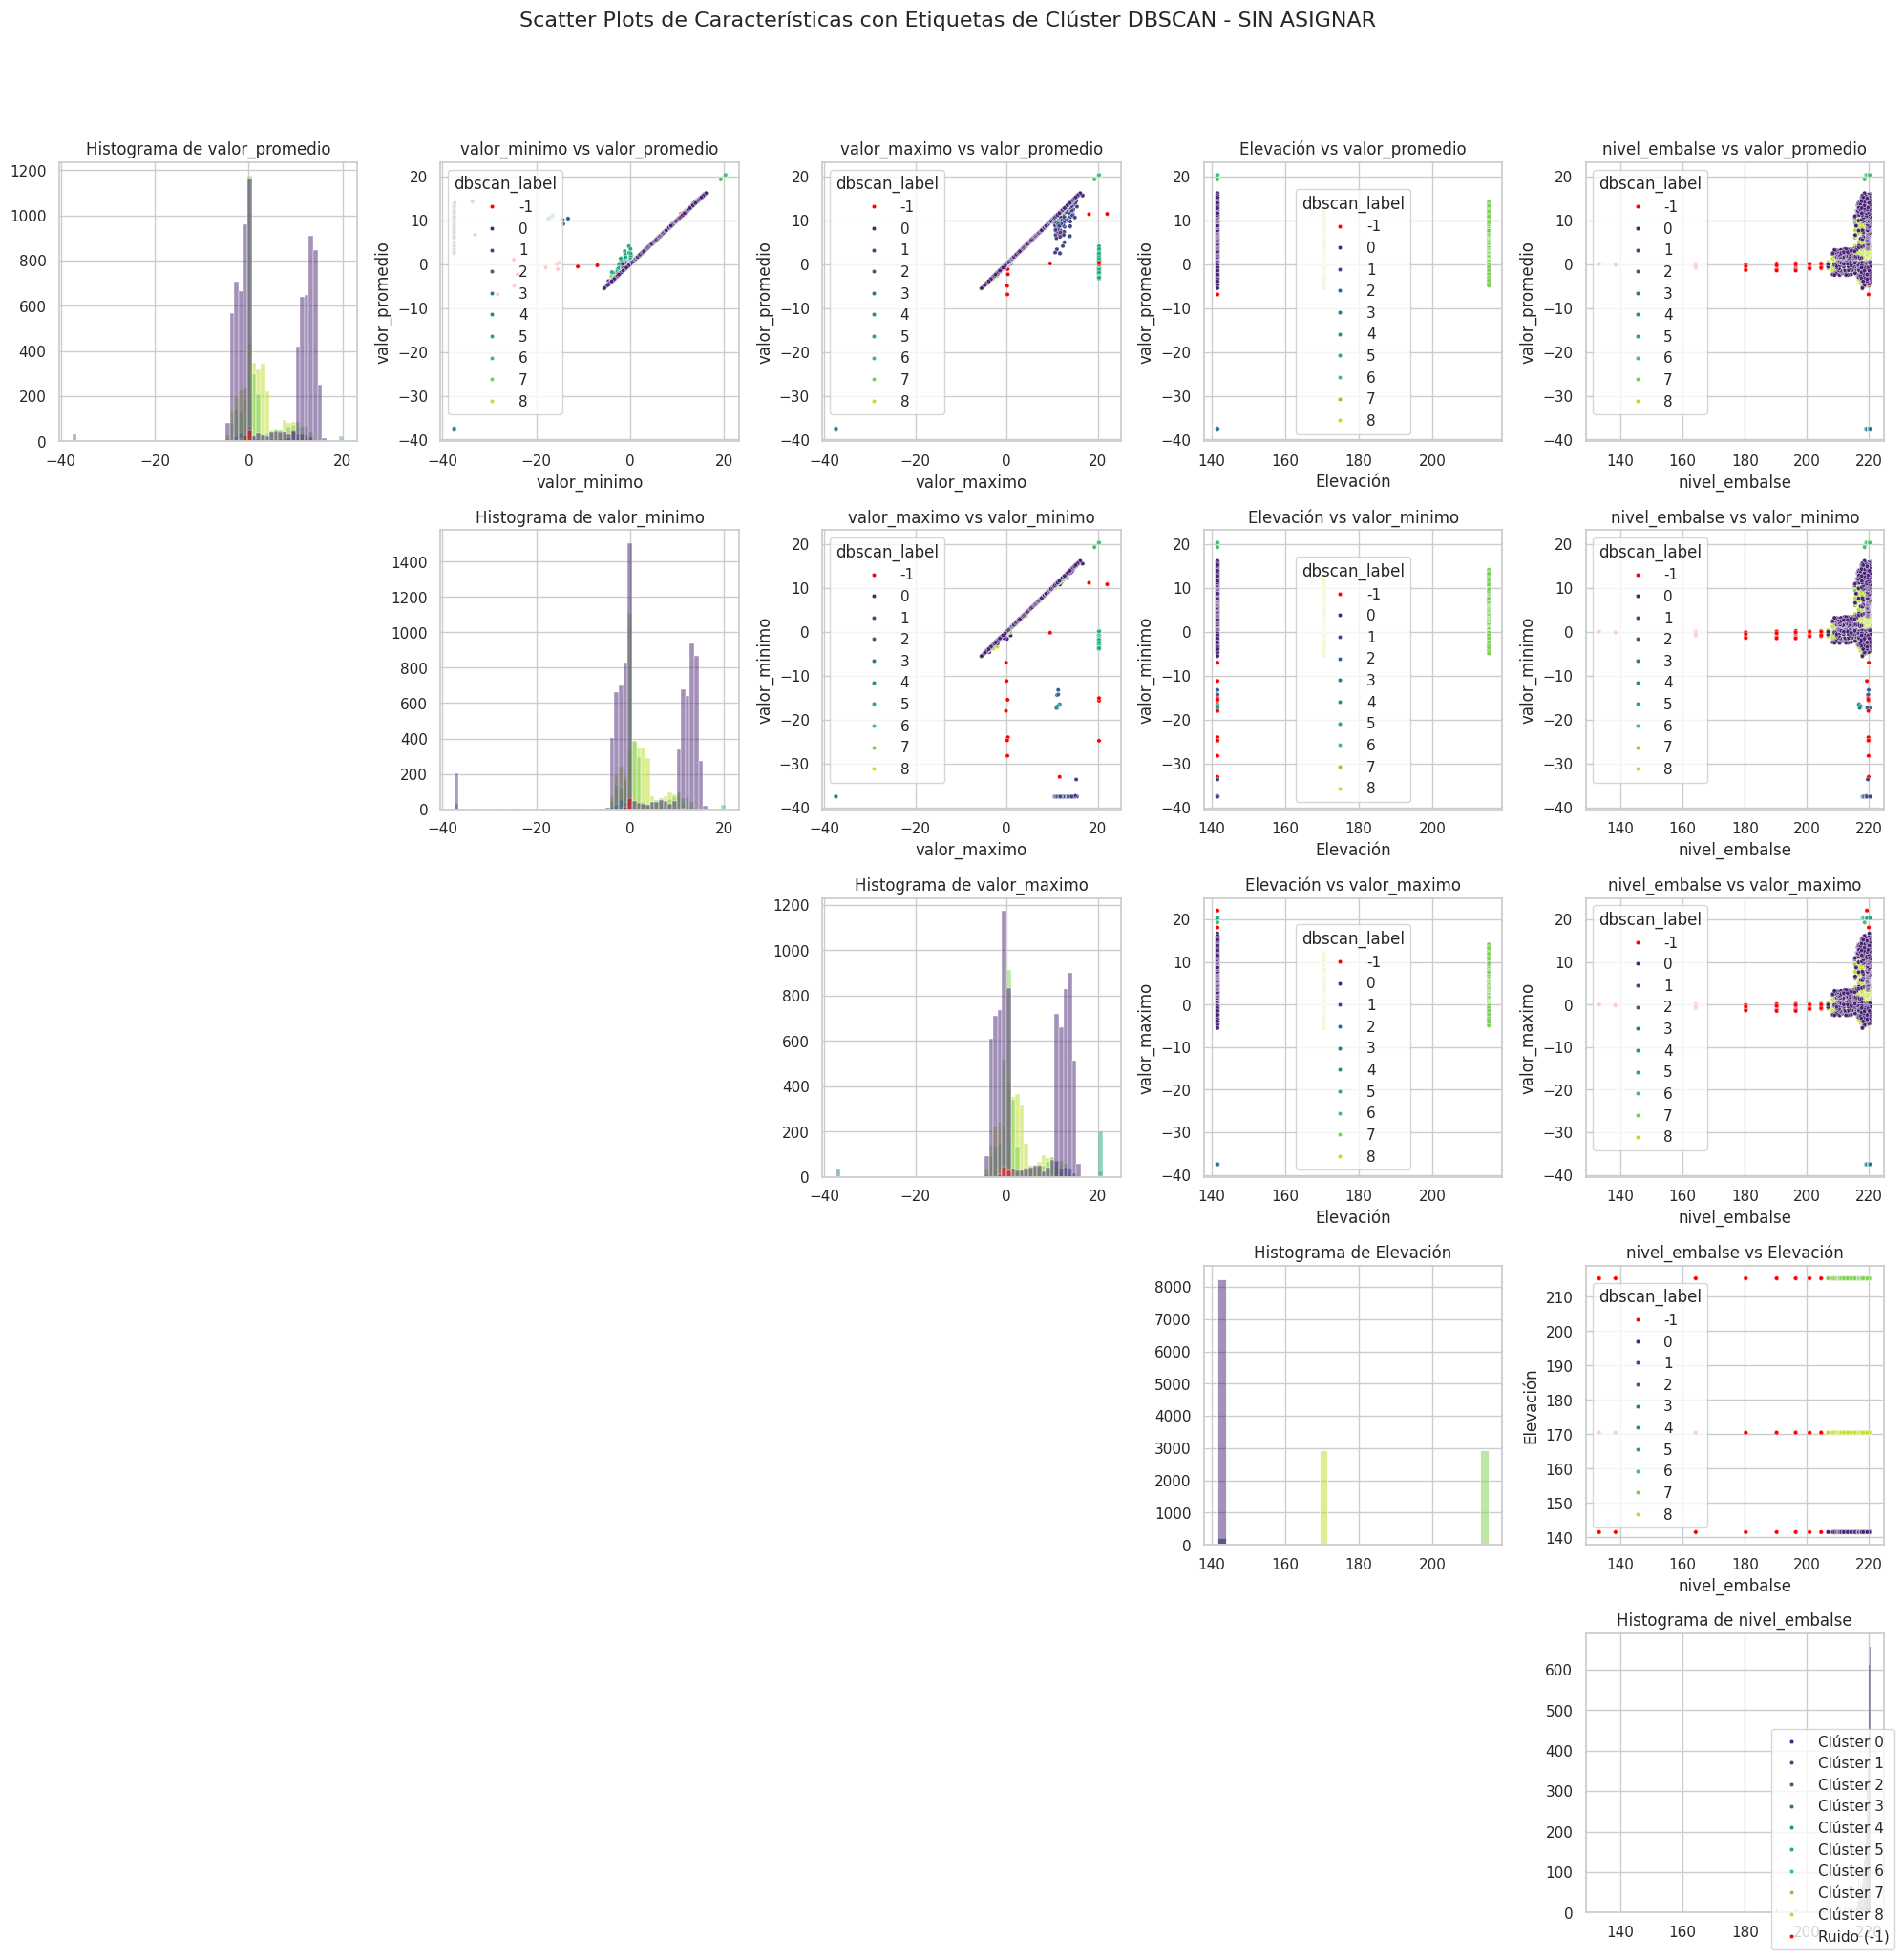


Interpretación de los gráficos de dispersión para 'SIN ASIGNAR':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: CONTATO CONCRETO/ROCHA ---


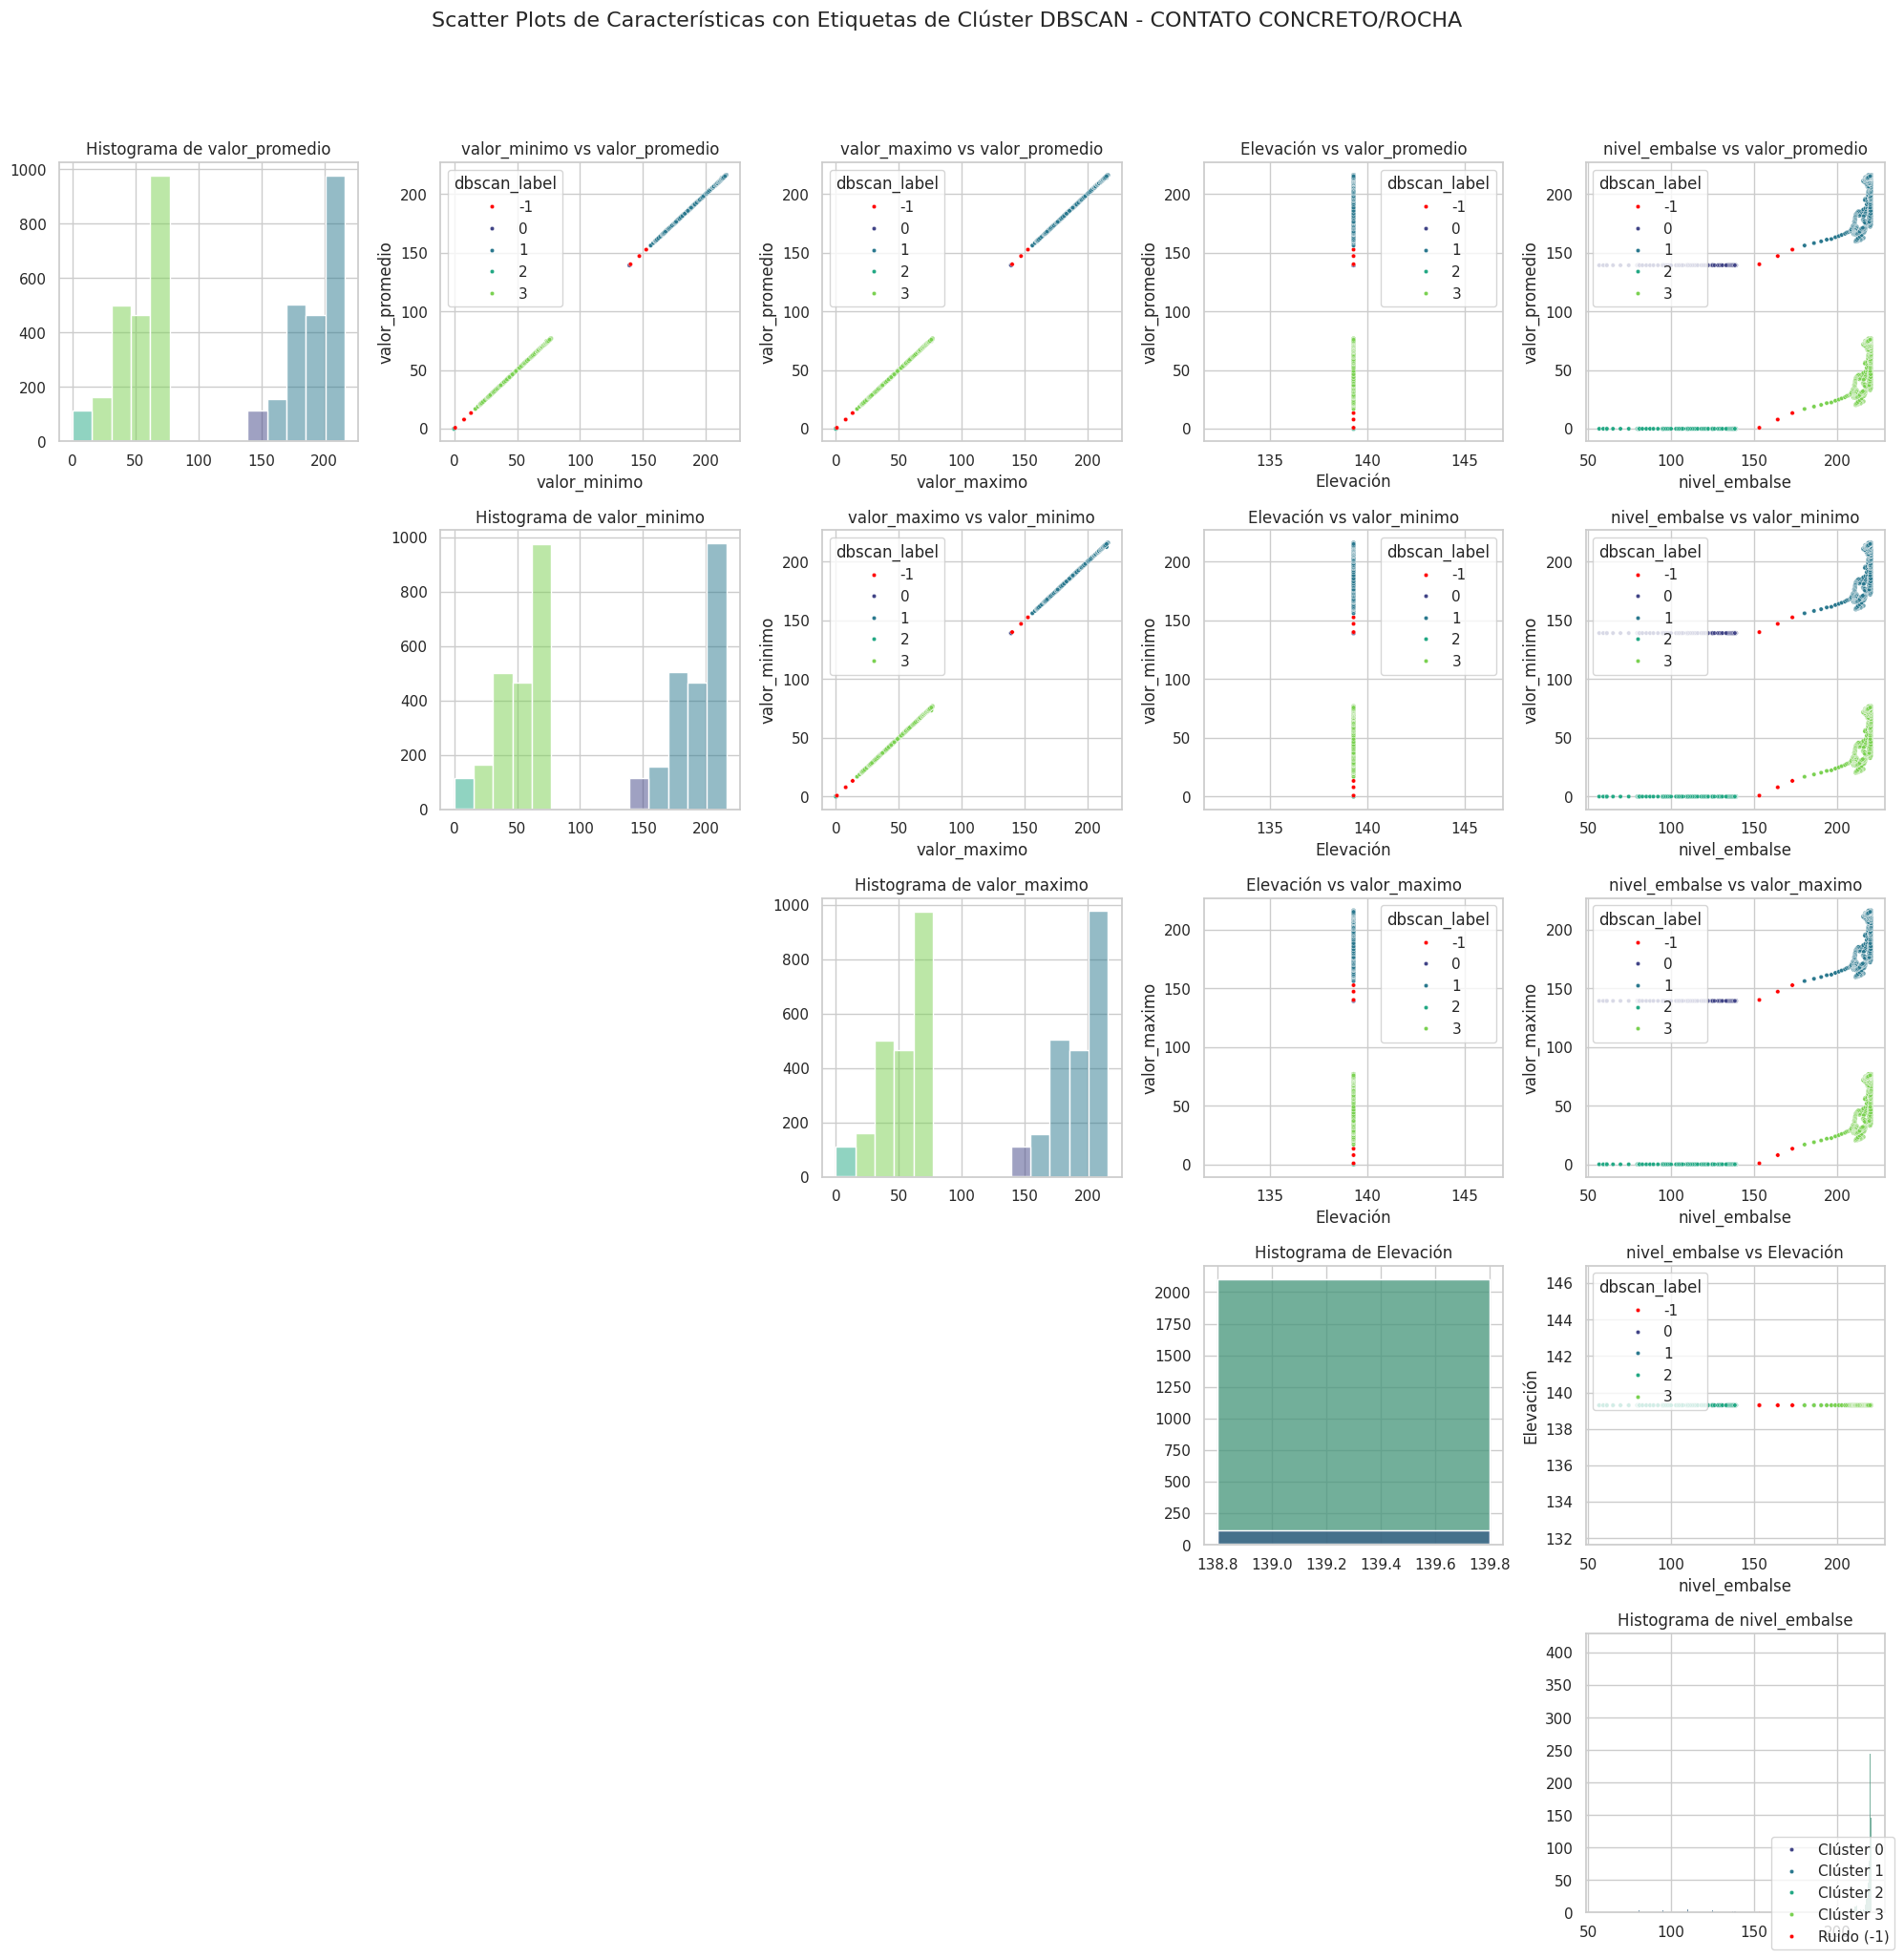


Interpretación de los gráficos de dispersión para 'CONTATO CONCRETO/ROCHA':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: BRECHA D ---


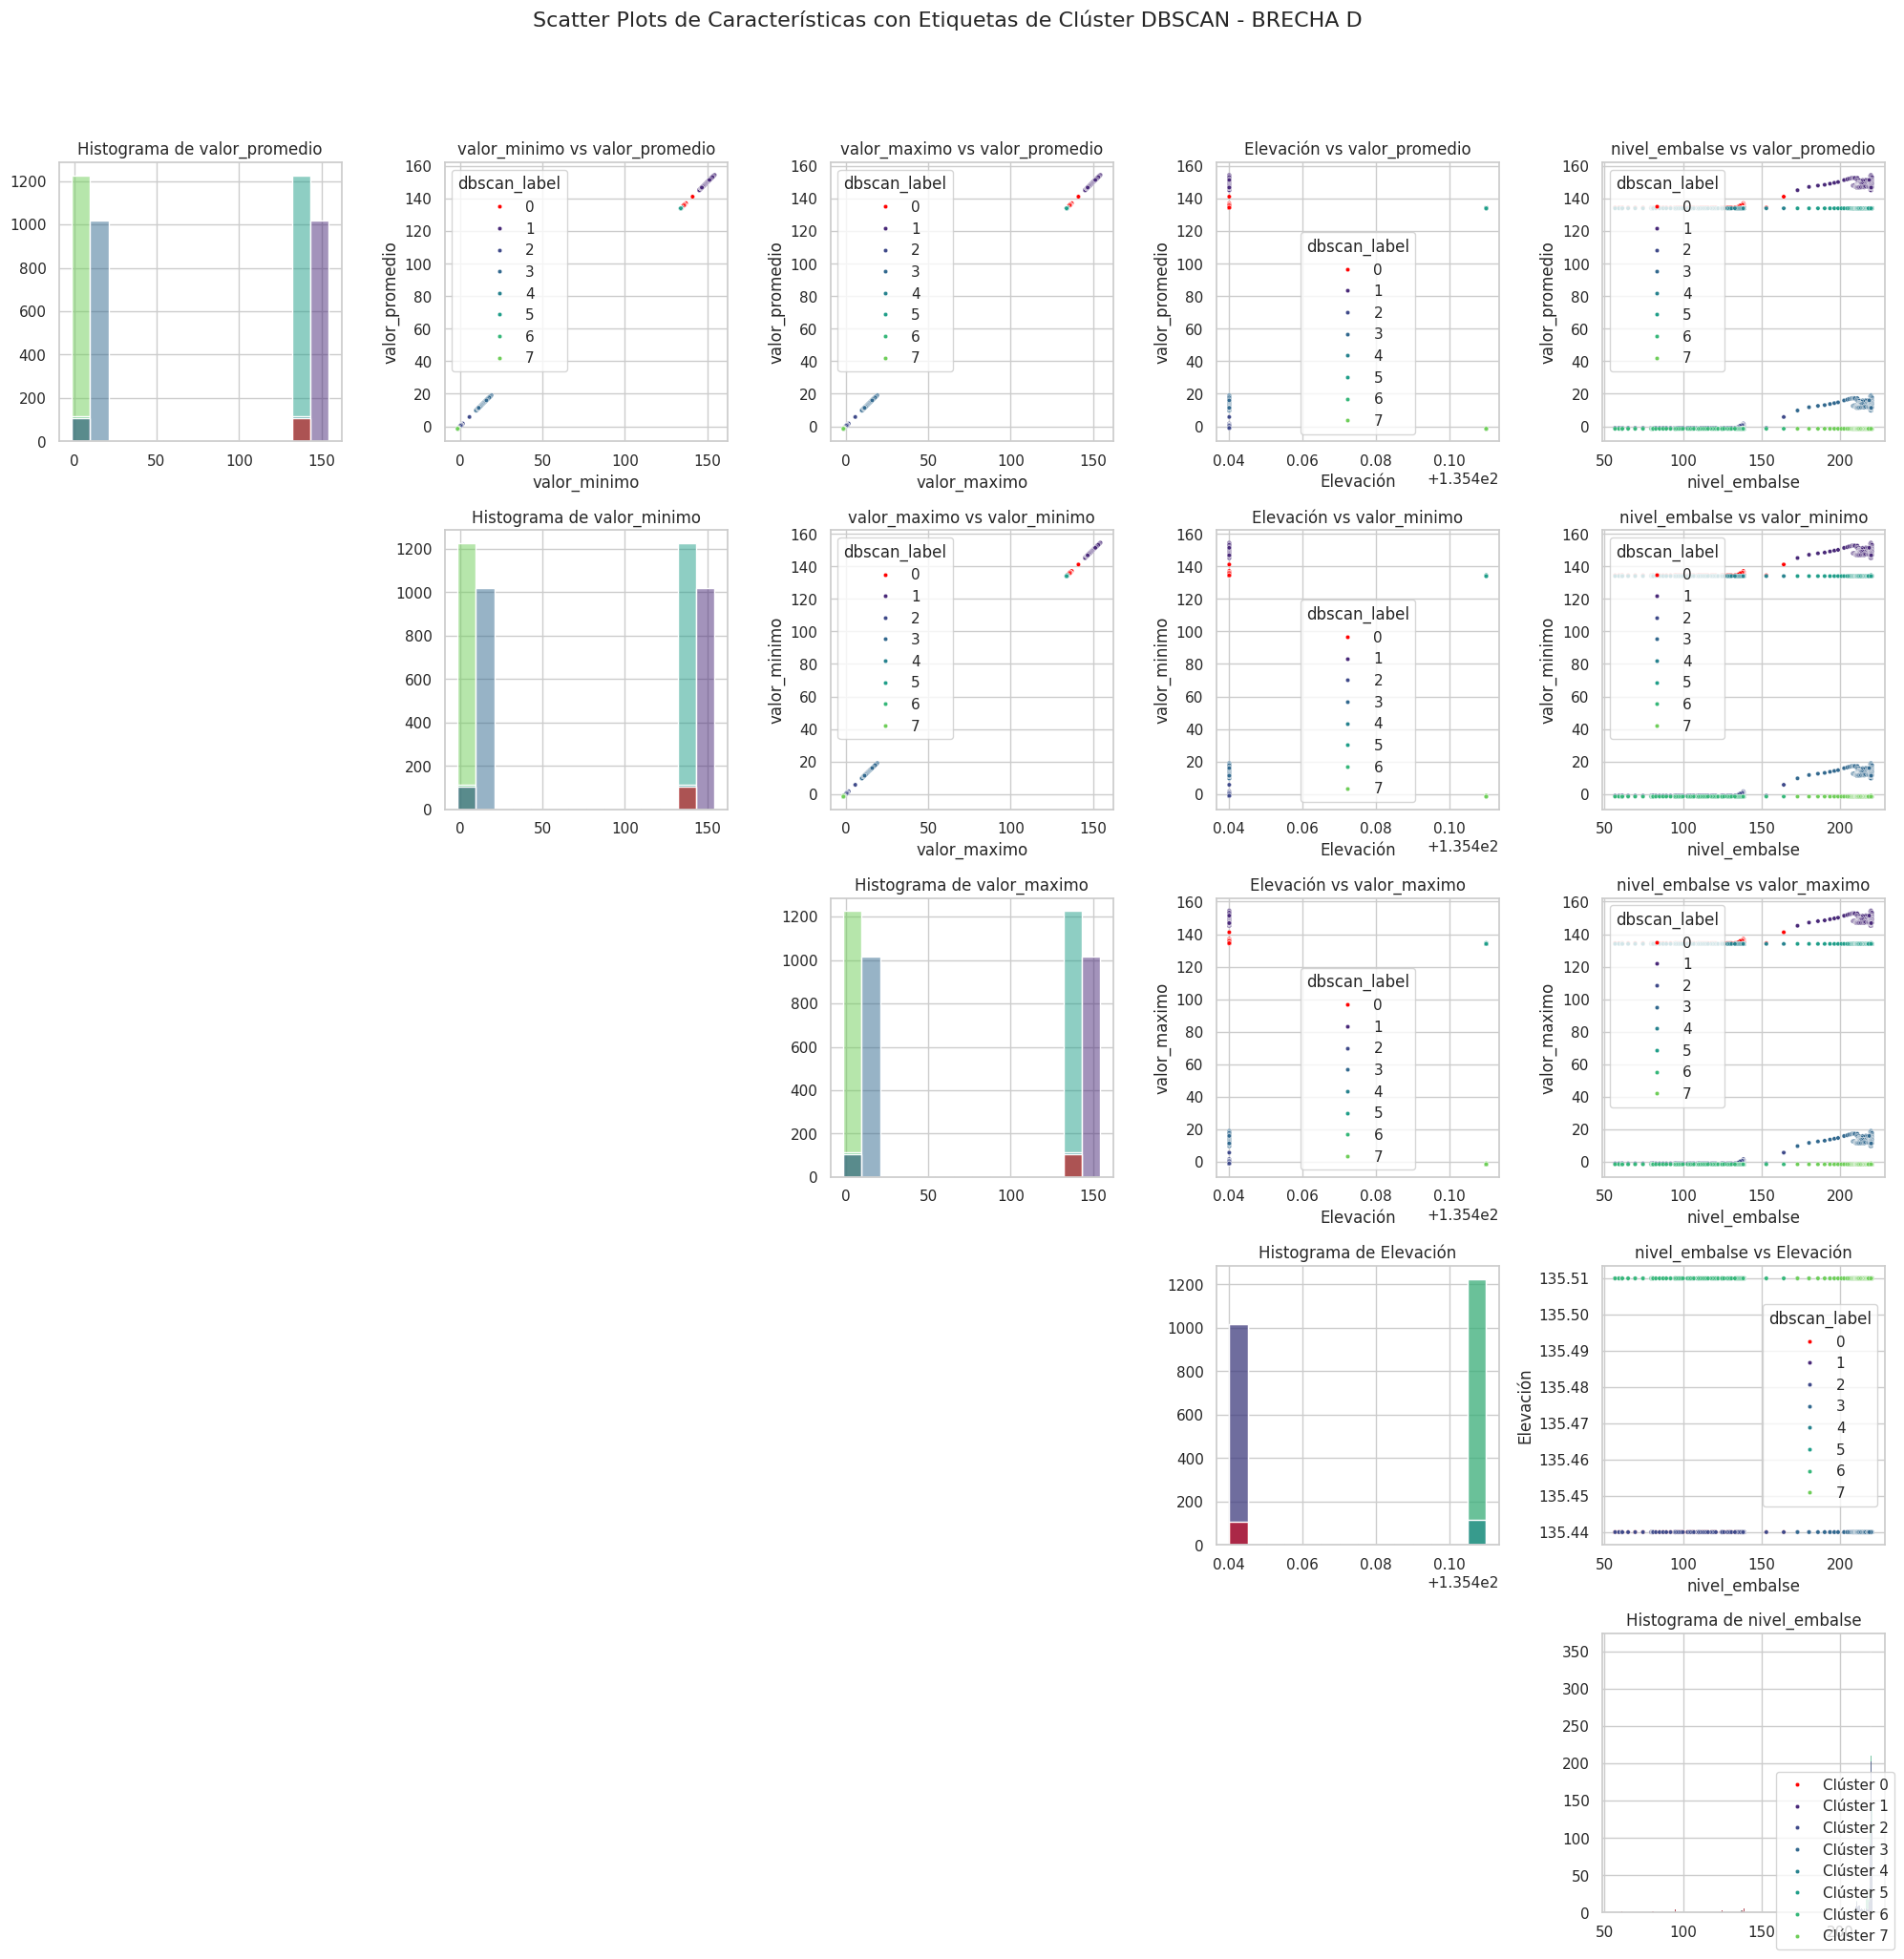


Interpretación de los gráficos de dispersión para 'BRECHA D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: BRECHA C ---


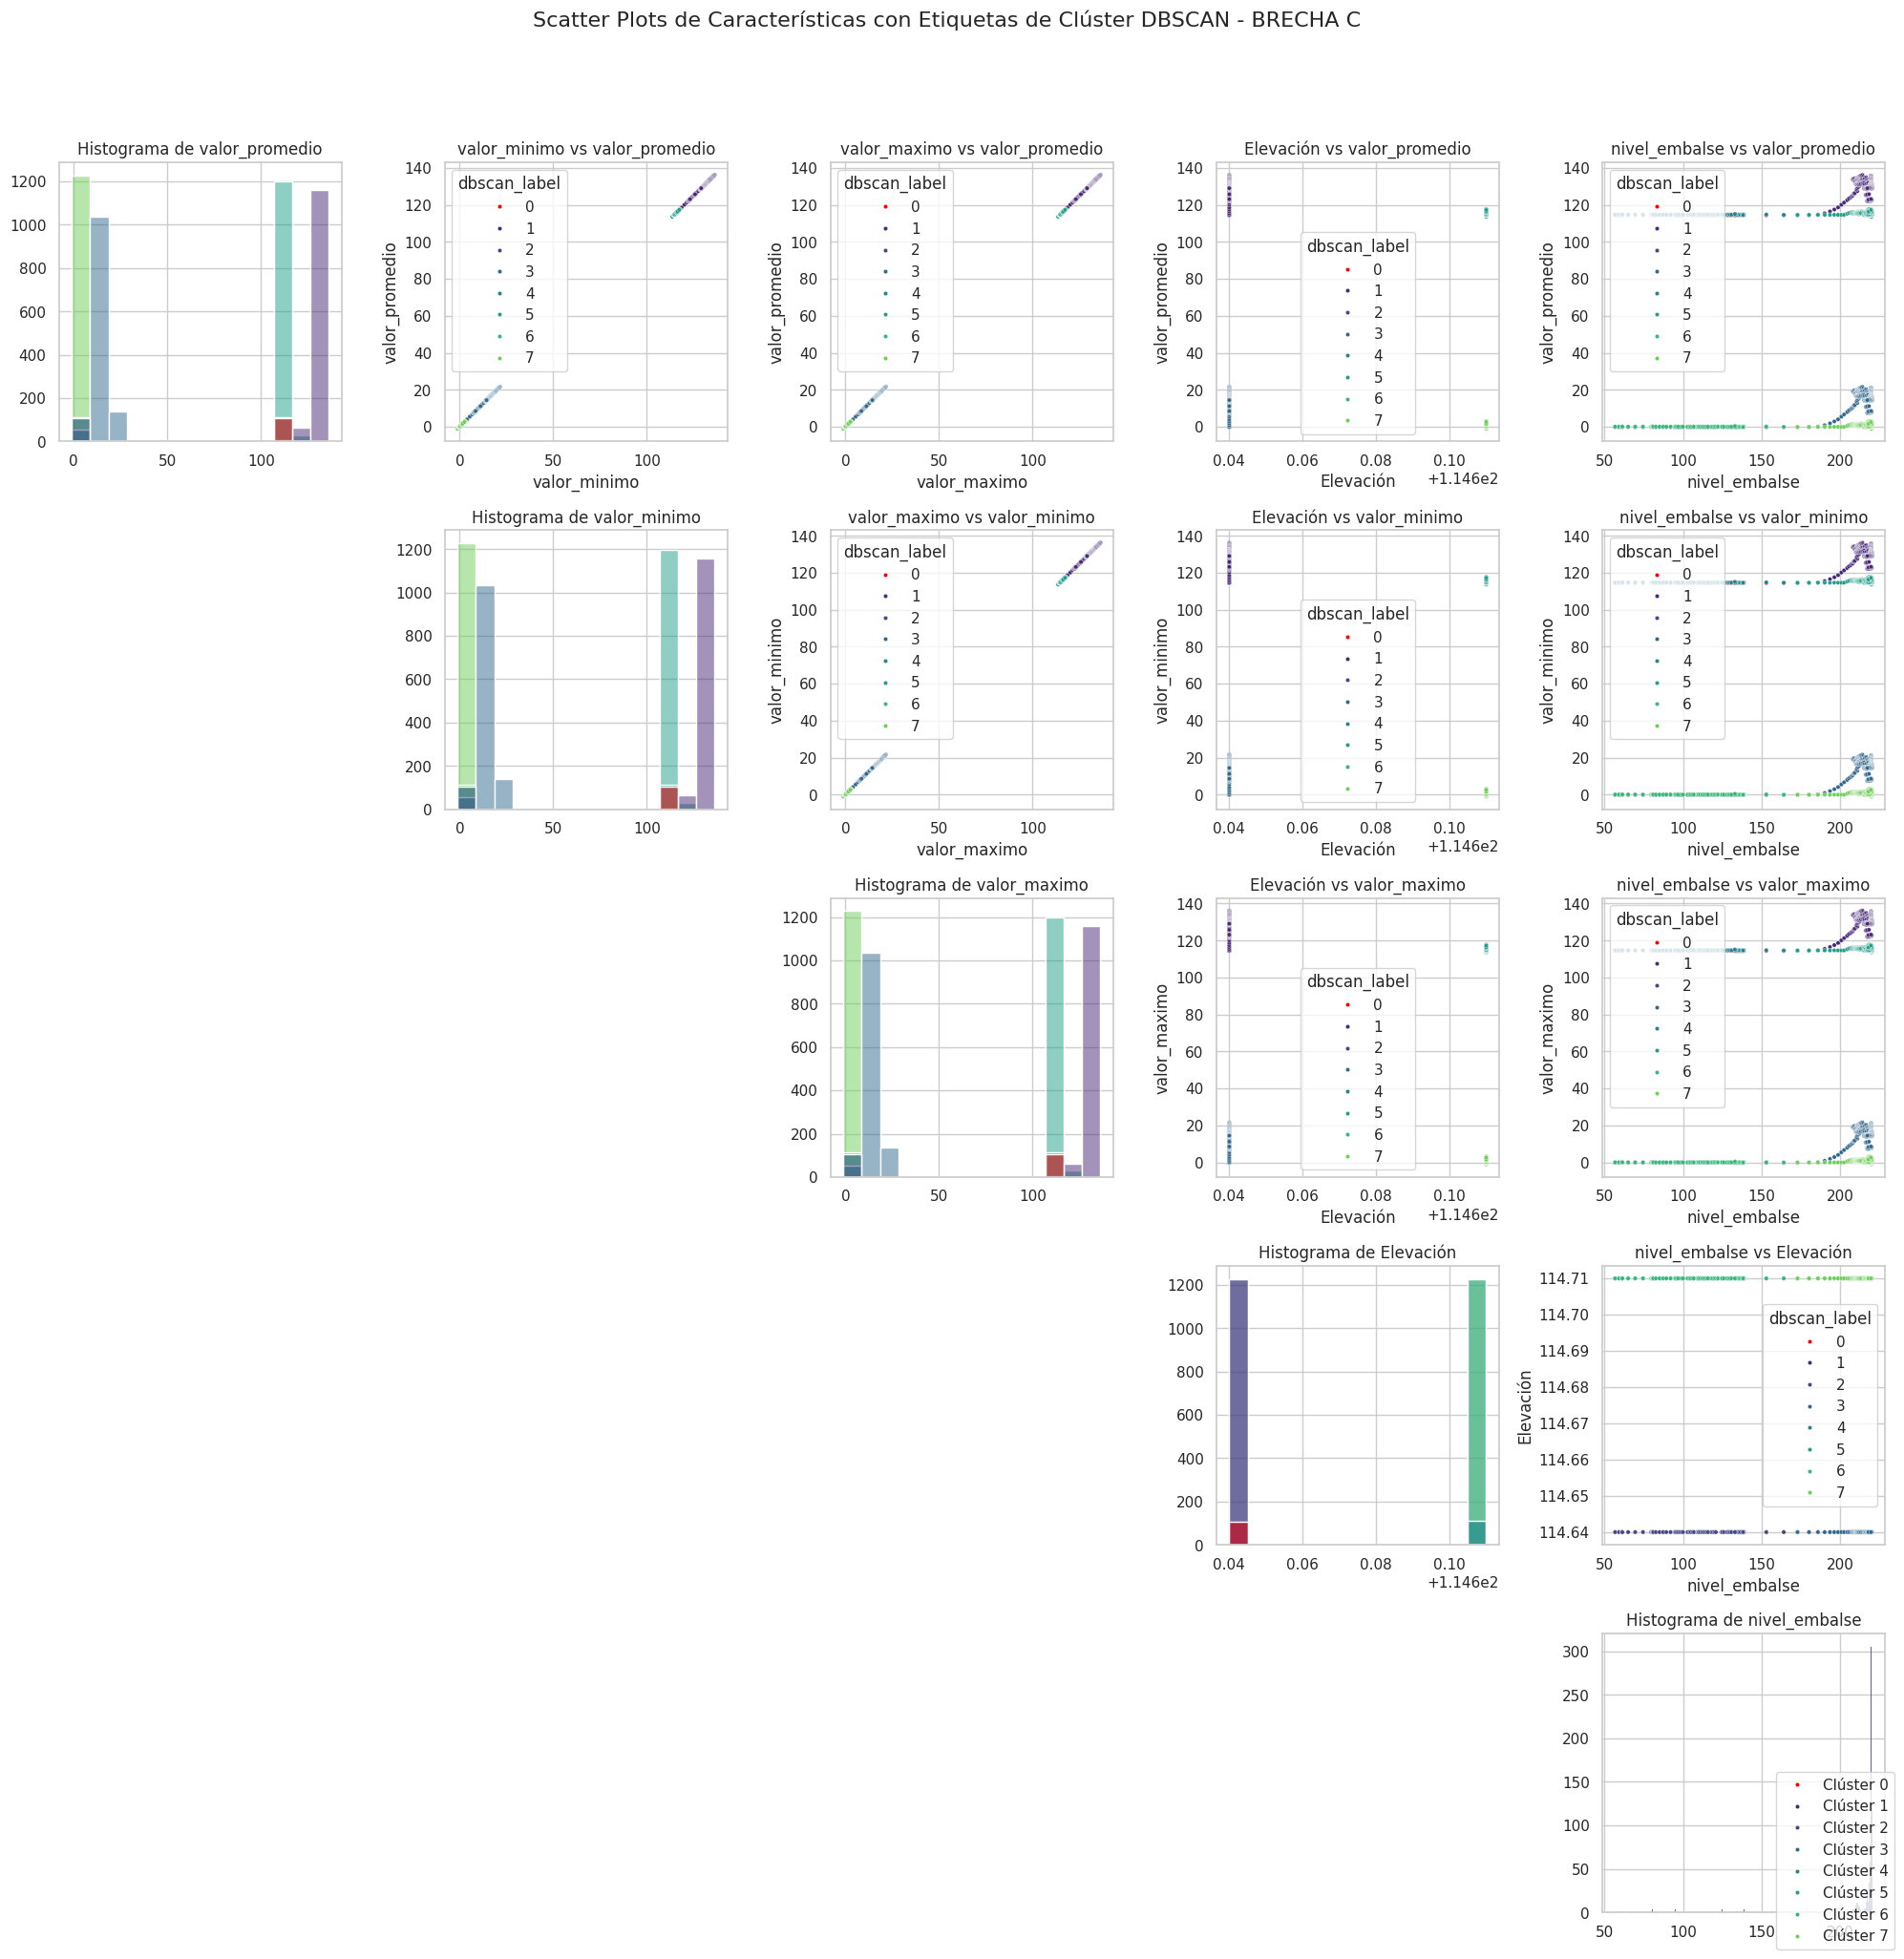


Interpretación de los gráficos de dispersión para 'BRECHA C':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: DERRAME D ---


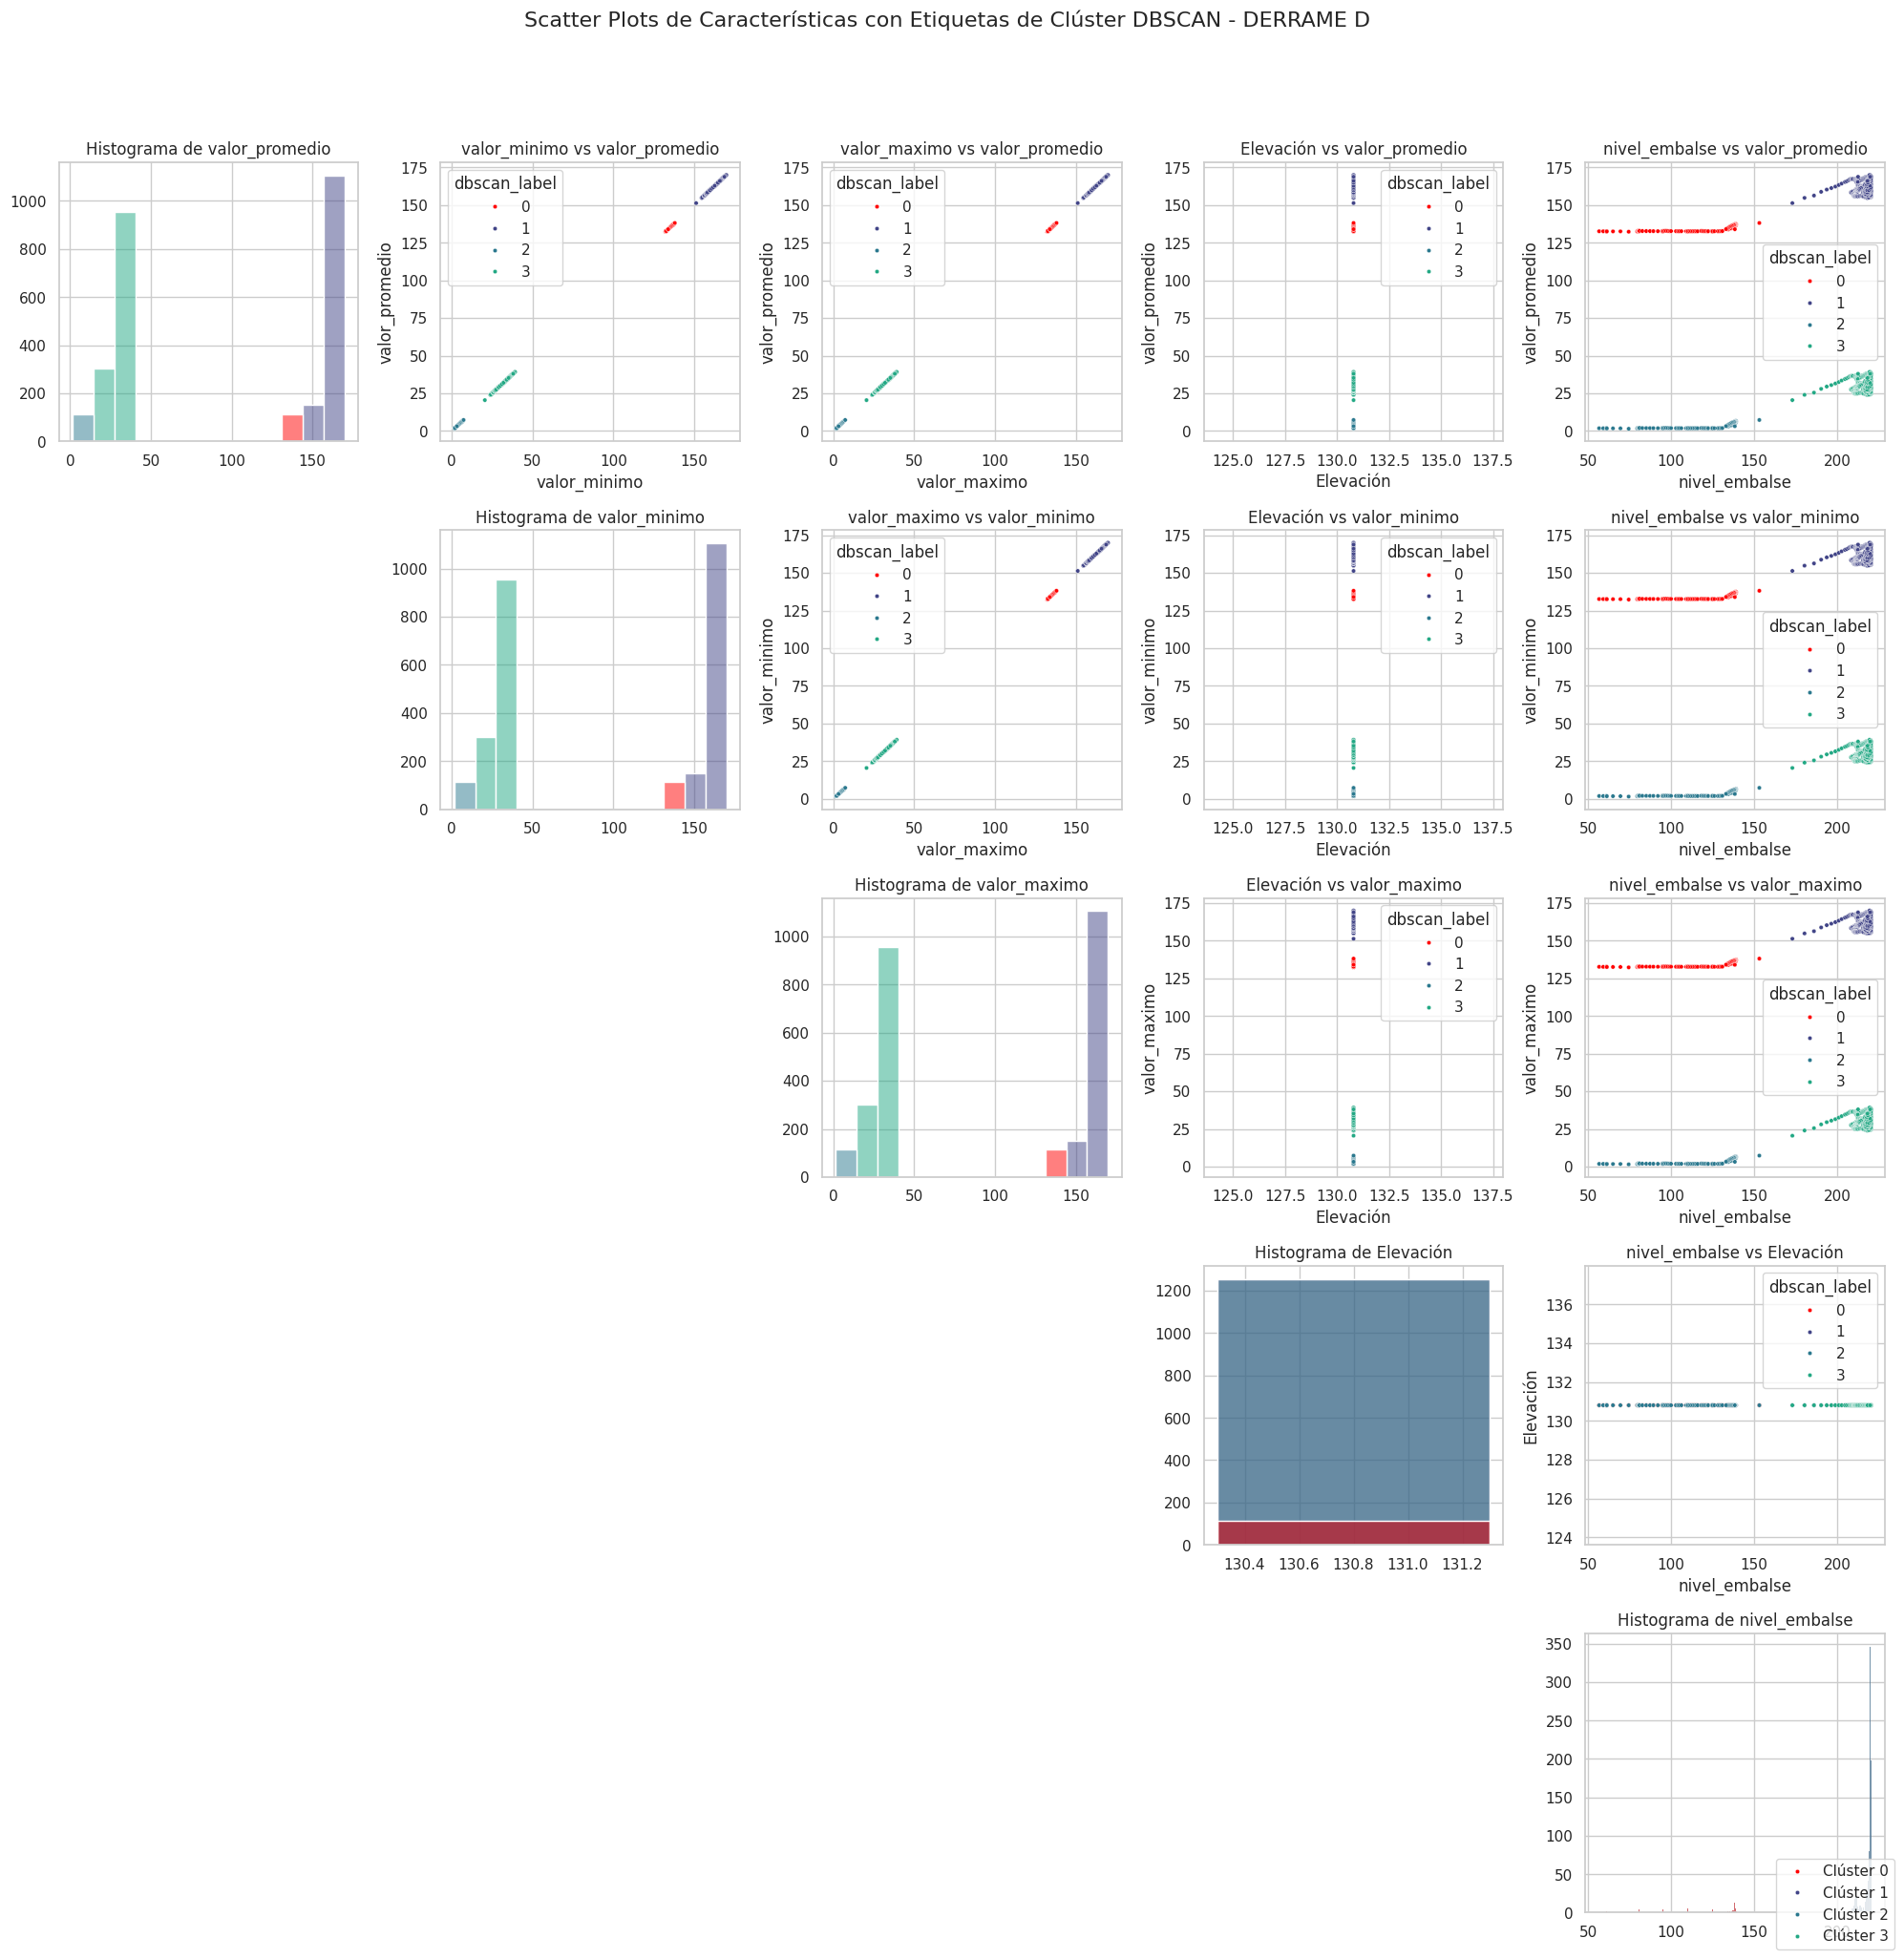


Interpretación de los gráficos de dispersión para 'DERRAME D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.


In [37]:
# Iterar a través del diccionario dbscan_results_by_location
for location, df_result in dbscan_results_by_location.items():
    print(f"\n--- Visualización de Clustering DBSCAN para: {location} ---")

    # Preparar los datos para la visualización
    # Seleccionar las características que se utilizaron para el clustering DBSCAN
    # Utilizaremos las mismas características definidas en la subtarea anterior: features_for_dbscan
    features_for_dbscan_plotting = features_for_dbscan # Asumiendo que features_for_dbscan todavía está disponible

    # Crear gráficos de dispersión para pares de las características seleccionadas
    # Crearemos una matriz de gráficos de dispersión para todos los pares de características.
    n_features = len(features_for_dbscan_plotting)
    fig, axes = plt.subplots(n_features, n_features, figsize=(4 * n_features, 4 * n_features))
    plt.suptitle(f"Scatter Plots de Características con Etiquetas de Clúster DBSCAN - {location}", y=1.02, fontsize=16)

    # Crear un mapa de colores: rojo para ruido (-1), y una paleta para clústeres (>= 0)
    unique_labels = df_result['dbscan_label'].unique()
    # Asegurarse de que -1 se procese primero para que se le asigne el color rojo
    sorted_labels = sorted(unique_labels)

    # Generar una paleta de colores, asegurando que el rojo esté asignado a -1
    colors = ['red'] # Iniciar con rojo para la etiqueta -1
    # Añadir colores de una paleta (ej. viridis) para las etiquetas de clúster (>= 0)
    if len(unique_labels) > 1: # Si hay clústeres además del ruido
         # Filtrar las etiquetas que no son -1 y obtener el número de clústeres
        cluster_labels = sorted([label for label in unique_labels if label != -1])
        colors.extend(sns.color_palette('viridis', n_colors=len(cluster_labels)).as_hex())


    color_map = {label: color for label, color in zip(sorted_labels, colors)}

    for i in range(n_features):
        for j in range(n_features):
            if i == j:
                # En la diagonal, graficar un histograma de la característica
                sns.histplot(data=df_result, x=features_for_dbscan_plotting[i], hue='dbscan_label', ax=axes[i, j], legend=False, palette=color_map) # Se eliminó kde=True
                axes[i, j].set_xlabel("")
                axes[i, j].set_ylabel("")
                axes[i, j].set_title(f"Histograma de {features_for_dbscan_plotting[i]}") # Agregar título de Histograma
            elif i < j:
                # Para gráficos fuera de la diagonal, crear gráficos de dispersión
                sns.scatterplot(
                    data=df_result,
                    x=features_for_dbscan_plotting[j],
                    y=features_for_dbscan_plotting[i],
                    hue='dbscan_label',
                    palette=color_map, # Usar el mapa de colores personalizado
                    legend='full',
                    ax=axes[i, j],
                    s=10 # Ajustar el tamaño de los puntos para mayor claridad
                )
                axes[i, j].set_title(f'{features_for_dbscan_plotting[j]} vs {features_for_dbscan_plotting[i]}')
                axes[i, j].set_xlabel(features_for_dbscan_plotting[j])
                axes[i, j].set_ylabel(features_for_dbscan_plotting[i])
            else:
                # Ocultar el triángulo inferior redundante de la matriz
                fig.delaxes(axes[i, j])

    # Crear leyenda personalizada
    handles, labels = axes[0, 1].get_legend_handles_labels() if n_features > 1 else ([], [])
    # Asegurarse de que la leyenda muestre -1 como "Ruido" o "Anomalía"
    legend_labels = ['Ruido (-1)' if label == '-1' else f'Clúster {label}' for label in labels]
    # Reordenar handles y labels para que "Ruido (-1)" aparezca primero
    sorted_legend_items = sorted(zip(handles, legend_labels), key=lambda item: item[1])
    handles, legend_labels = zip(*sorted_legend_items)

    if handles: # Asegurarse de que hay handles antes de intentar crear la leyenda
        fig.legend(handles, legend_labels, loc='lower right', bbox_to_anchor=(1, 0))


    # Mejorar el diseño y mostrar los gráficos
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar el diseño para evitar superposición de títulos
    plt.show()

    # Agregar guía de interpretación
    print(f"\nInterpretación de los gráficos de dispersión para '{location}':")
    print("Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.")
    print("Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.")
    print("Los puntos con etiqueta -1 (Ruido) son posibles anomalías y deberían destacar,")
    print("a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.")
    print("Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.")
    print("Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.")

## Consolidar y interpretar los hallazgos

### Subtask:
Consolidar los resultados del análisis de DBSCAN de todos los grupos geológicos e interpretar los hallazgos en el contexto de la verificación espacial, identificando qué grupos o sensores presentan anomalías según DBSCAN.


**Reasoning**:
Initialize a dictionary to store the consolidated findings from the DBSCAN analysis for each geological location.



In [ ]:
# 1. Inicializar un diccionario vacío para almacenar los hallazgos consolidados.
consolidated_dbscan_findings = {}

print("Diccionario 'consolidated_dbscan_findings' inicializado.")

**Reasoning**:
Iterate through the DBSCAN results for each geological location, extract key information about the clusters and noise points, and store it in the `consolidated_dbscan_findings` dictionary.



In [ ]:
# 2. Iterar a través del diccionario dbscan_results_by_location.
# 3. Para cada ubicación geológica, extraer información clave.
for location, df_result in dbscan_results_by_location.items():
    print(f"\nProcesando grupo geológico: {location}")

    # Número total de puntos de datos en el grupo.
    total_points = len(df_result)

    # Distribución de las etiquetas de clúster.
    cluster_counts = df_result['dbscan_label'].value_counts()

    # Número de clústeres identificados (excluir etiqueta de ruido -1).
    n_clusters = len(cluster_counts) - (1 if -1 in cluster_counts else 0)

    # Número y porcentaje de puntos de ruido (etiqueta -1).
    noise_count = cluster_counts.get(-1, 0)
    noise_percentage = (noise_count / total_points) * 100 if total_points > 0 else 0

    # Resumen de las características de los puntos de ruido.
    noise_summary = None
    noise_points = df_result[df_result['dbscan_label'] == -1]
    if not noise_points.empty:
        noise_summary = noise_points[features_for_dbscan].describe().to_dict()

    # Resumen de las características de los clústeres identificados.
    cluster_summary = None
    clusters = df_result[df_result['dbscan_label'] != -1]
    if not clusters.empty:
        # Calcular la media para cada clúster y almacenar como un diccionario
        cluster_summary_df = clusters.groupby('dbscan_label')[features_for_dbscan].mean()
        cluster_summary = cluster_summary_df.apply(lambda x: x.to_dict(), axis=1).to_dict()


    # 4. Almacenar la información extraída en la estructura de hallazgos consolidados.
    consolidated_dbscan_findings[location] = {
        'total_points': total_points,
        'n_clusters': n_clusters,
        'noise_count': noise_count,
        'noise_percentage': noise_percentage,
        'noise_summary': noise_summary,
        'cluster_summary': cluster_summary
    }

print("\nExtracción de información de DBSCAN completada para todos los grupos geológicos.")
# Mostrar los hallazgos consolidados para revisión (opcional, para verificación)
# print("\nConsolidated DBSCAN Findings:")
# display(consolidated_dbscan_findings)

**Reasoning**:
Review the consolidated findings to identify patterns and significant observations across different groups and write a comprehensive interpretation of the findings in the context of spatial verification, identifying groups and sensors with anomalies and discussing potential reasons.



In [ ]:
# 5. Después de iterar a través de todas las ubicaciones geológicas, revisar los hallazgos consolidados.
print("\nResumen Consolidado de Hallazgos de DBSCAN por Grupo Geológico:")

# Convertir el diccionario a un DataFrame de pandas para facilitar la revisión
consolidated_df = pd.DataFrame.from_dict(consolidated_dbscan_findings, orient='index')
display(consolidated_df[['total_points', 'n_clusters', 'noise_count', 'noise_percentage']])

# 6. Escribir una interpretación completa de los hallazgos consolidados en el contexto de la verificación espacial.
print("\n--- Interpretación de los Hallazgos de DBSCAN para Verificación Espacial ---")

print("\nAnálisis General:")
print("El análisis de DBSCAN se aplicó a los datos de sensores agrupados por su ubicación geológica.")
print("DBSCAN identifica grupos densos de puntos de datos (clústeres) y etiqueta los puntos que no pertenecen a ningún clúster denso como 'ruido' (etiqueta -1).")
print("Estos puntos de ruido son candidatos a ser anomalías espaciales, ya que sus características son significativamente diferentes de las de sus vecinos en la misma ubicación geológica.")

print("\nComparación entre Grupos Geológicos (Basado en Puntos de Ruido):")
# Ordenar las ubicaciones por porcentaje de ruido para resaltar aquellas con más anomalías
consolidated_df_sorted_by_noise = consolidated_df.sort_values(by='noise_percentage', ascending=False)
display(consolidated_df_sorted_by_noise[['total_points', 'n_clusters', 'noise_count', 'noise_percentage']])

print("\nObservaciones:")
print(f"El grupo '{consolidated_df_sorted_by_noise.index[0]}' presenta el porcentaje más alto de puntos de ruido ({consolidated_df_sorted_by_noise['noise_percentage'].max():.2f}%). Esto sugiere que los sensores en esta ubicación muestran una mayor variabilidad o inconsistencia en sus mediciones en comparación con otros grupos.")
print("Los grupos con 0% de ruido ('BRECHA D', 'BRECHA C', 'DERRAME D') indican que, con los parámetros de DBSCAN utilizados, todos los puntos en estas ubicaciones forman parte de clústeres densos, lo que sugiere una mayor consistencia en los datos de los sensores en esas áreas.")

# 7. Resaltar cualquier sensor o característica específica que parezca contribuir más a la identificación de anomalías en múltiples grupos.
print("\nCaracterísticas que Contribuyen a la Identificación de Anomalías:")
print("Para identificar qué características contribuyen más a que un punto sea ruido, podemos examinar las estadísticas descriptivas de los puntos de ruido ('noise_summary') para cada grupo.")
print("Generalmente, los puntos de ruido tendrán valores para una o más de las características utilizadas para el clustering que se desvían significativamente de los valores promedio o típicos de los clústeres en esa misma ubicación geológica.")

# Ejemplo de examen del resumen de ruido para un grupo con alto ruido
top_noise_location = consolidated_df_sorted_by_noise.index[0]
if consolidated_dbscan_findings[top_noise_location]['noise_summary']:
    print(f"\nEstadísticas descriptivas de los puntos de ruido en '{top_noise_location}':")
    # Convertir el diccionario anidado a un DataFrame para mejor visualización
    noise_summary_df = pd.DataFrame(consolidated_dbscan_findings[top_noise_location]['noise_summary'])
    display(noise_summary_df)

    print(f"\nComparación de Estadísticas de Ruido vs. Clústeres para '{top_noise_location}':")
    if consolidated_dbscan_findings[top_noise_location]['cluster_summary']:
         cluster_summary_df_compare = pd.DataFrame(consolidated_dbscan_findings[top_noise_location]['cluster_summary']).T # Transponer para tener las características como filas
         print("Estadísticas promedio de los clústeres:")
         display(cluster_summary_df_compare)

         print("\nObservar las diferencias entre las estadísticas de los puntos de ruido (especialmente la media) y las estadísticas promedio de los clústeres puede indicar qué características son inusuales en los puntos de ruido.")
    else:
        print("No hay clústeres identificados para comparar con los puntos de ruido en este grupo.")

print("\nPosibles Razones de las Anomalías Espaciales:")
print("- **Calidad de los Datos:** Errores en la entrada manual (como se observó previamente en el análisis de picos de error de PCA).")
print("- **Eventos Localizados:** Cambios específicos en la ubicación geológica que afectan a algunos sensores pero no a sus vecinos (ej. pequeños deslizamientos, cambios en el nivel freático local).")
print("- **Problemas del Sensor:** Mal funcionamiento de sensores individuales que reportan valores atípicos.")
print("- **Características Geológicas Específicas:** La propia naturaleza de la ubicación geológica puede generar mayor variabilidad en las lecturas de los sensores.")


# 8. Considerar las limitaciones del enfoque de DBSCAN para la verificación espacial basadas en los resultados observados.
print("\nLimitaciones de DBSCAN para Verificación Espacial en este Contexto:")
print("- **Sensibilidad a Parámetros:** Los resultados de DBSCAN (`eps` y `min_samples`) pueden variar significativamente dependiendo de la elección de los parámetros. La selección de parámetros óptimos puede ser un desafío.")
print("- **Dependencia de las Características:** El rendimiento de DBSCAN depende en gran medida de las características seleccionadas para el clustering. Características irrelevantes o ruidosas pueden afectar la identificación de clústeres y ruido.")
print("- **Definición de 'Espacialidad':** En este análisis, 'espacialidad' se aproximó agrupando por 'local_geologico'. DBSCAN se aplicó al espacio de características de los valores de los sensores, no a coordenadas geográficas explícitas (que tenían muchos valores faltantes). Si las coordenadas estuvieran completas, DBSCAN podría aplicarse directamente al espacio geográfico (2D o 3D) para encontrar agrupaciones de sensores y sensores aislados (ruido espacial geográfico).")
print("- **Variabilidad Temporal:** DBSCAN, tal como se aplicó aquí, considera todos los puntos de datos (incluyendo diferentes fechas) juntos para cada ubicación geológica. No modela explícitamente la variabilidad o patrones temporales dentro de cada ubicación.")
print("- **Interpretación de Clústeres:** Identificar clústeres no siempre implica una anomalía. Los clústeres representan simplemente grupos de puntos similares. La verificación de anomalías se centra principalmente en los puntos de ruido.")

print("\nConclusión:")
print("El análisis de DBSCAN por grupo geológico ha identificado puntos de datos que se desvían del comportamiento típico de sus vecinos dentro de la misma ubicación. Estos puntos de ruido son fuertes candidatos para una verificación adicional como posibles anomalías espaciales. La prevalencia de ruido varía entre los grupos geológicos, sugiriendo que algunas ubicaciones pueden ser inherentemente más variables o susceptibles a problemas de datos/sensores. La interpretación detallada de los puntos de ruido y la comparación con los clústeres es crucial para diagnosticar la posible causa de estas anomalías.")

### Cruce de Hallazgos: Ruido de DBSCAN y Anomalías de PCA

El siguiente código cruzará los índices (fechas) de los puntos identificados como ruido por DBSCAN con los índices de los puntos con alto error de reconstrucción de PCA. Esto nos permitirá identificar las fechas que fueron consideradas anómalas por ambos métodos.

In [33]:
# 1. Consolidar todos los índices de los puntos de ruido de DBSCAN de todas las ubicaciones geológicas.
all_dbscan_noise_indices = []
for location, df_result in dbscan_results_by_location.items():
    noise_points_location = df_result[df_result['dbscan_label'] == -1]
    all_dbscan_noise_indices.extend(noise_points_location.index.tolist())

# Eliminar duplicados y ordenar las fechas
all_dbscan_noise_indices = sorted(list(set(all_dbscan_noise_indices)))

print(f"Número total de fechas identificadas como ruido por DBSCAN en todos los grupos: {len(all_dbscan_noise_indices)}")
# print("\Ejemplo de fechas de ruido de DBSCAN:", all_dbscan_noise_indices[:5]) # Opcional: mostrar ejemplos

# 2. Recuperar los índices de los picos de error de reconstrucción de PCA.
# Estos ya están almacenados en la variable peak_indices_eme002 (si la celda anterior se ejecutó).
# Asegurarse de que los índices de PCA sean únicos y estén ordenados para una comparación sencilla.
peak_indices_eme002_sorted = sorted(list(set(peak_indices_eme002)))

print(f"\nNúmero total de fechas identificadas como picos de error por PCA (Grupo EM-E-002): {len(peak_indices_eme002_sorted)}")
# print("\Ejemplo de fechas de picos de error de PCA:", peak_indices_eme002_sorted[:5]) # Opcional: mostrar ejemplos


# 3. Encontrar la intersección de los dos conjuntos de índices (fechas).
# Esto identificará las fechas que son anómalas según AMBOS métodos.
common_anomalies_indices = list(set(all_dbscan_noise_indices) & set(peak_indices_eme002_sorted))

# Ordenar las fechas comunes
common_anomalies_indices = sorted(common_anomalies_indices)

print(f"\nNúmero de fechas identificadas como anómalas por DBSCAN y PCA (intersección): {len(common_anomalies_indices)}")

# 4. Mostrar las fechas que son anómalas en ambos análisis.
print("\nFechas identificadas como anómalas por AMBOS DBSCAN y PCA:")
if common_anomalies_indices:
    for date in common_anomalies_indices:
        print(date)
else:
    print("No se encontraron fechas identificadas como anómalas por AMBOS DBSCAN y PCA.")

# Opcional: Mostrar las fechas que son anómalas solo por un método (diferencia simétrica)
# unique_to_dbscan = sorted(list(set(all_dbscan_noise_indices) - set(peak_indices_eme002_sorted)))
# unique_to_pca = sorted(list(set(peak_indices_eme002_sorted) - set(all_dbscan_noise_indices)))
# print(f"\nNúmero de fechas anómalas solo por DBSCAN: {len(unique_to_dbscan)}")
# print(f"Número de fechas anómalas solo por PCA: {len(unique_to_pca)}")

Número total de fechas identificadas como ruido por DBSCAN en todos los grupos: 151

Número total de fechas identificadas como picos de error por PCA (Grupo EM-E-002): 437

Número de fechas identificadas como anómalas por DBSCAN y PCA (intersección): 8

Fechas identificadas como anómalas por AMBOS DBSCAN y PCA:
1982-10-13 00:00:00
1982-10-17 00:00:00
1982-10-19 00:00:00
1982-10-21 00:00:00
1982-10-23 00:00:00
2009-03-25 00:00:00
2009-04-27 00:00:00
2009-05-14 00:00:00


### Documentación de Observaciones para Fechas Anómalas Comunes (DBSCAN y PCA)

A continuación, se presentan los datos originales para los sensores del grupo EM-E-002 en las fechas que fueron identificadas como anómalas por ambos análisis (ruido de DBSCAN y picos de error de reconstrucción de PCA).

Utiliza este espacio para registrar tus observaciones, posibles causas y cualquier otra información relevante para cada fecha.

---

In [35]:
# Asegurarse de que common_anomalies_indices y df_sensores están disponibles
if 'common_anomalies_indices' not in locals() or not common_anomalies_indices:
    print("La lista de fechas anómalas comunes (common_anomalies_indices) está vacía o no definida.")
    print("Por favor, asegúrate de ejecutar la celda anterior para identificar las fechas anómalas comunes.")
elif 'df_sensores' not in locals():
    print("El DataFrame original 'df_sensores' no está disponible.")
    print("Por favor, asegúrate de cargar los datos primero.")
else:
    print("Mostrando datos para documentar observaciones en fechas anómalas comunes.")
    # Iterar a través de cada fecha anómala común
    for date in common_anomalies_indices:
        print(f"\n--- Datos para la Fecha Anómala: {date.strftime('%Y-%m-%d')} ---")

        # Filtrar el DataFrame original para la fecha actual y el grupo EM-E-002
        df_anomalous_date = df_sensores[
            (df_sensores.index == date) &
            (df_sensores['nombre_etiqueta'].str.contains('EM-E-002', na=False))
        ].copy()

        # Mostrar los datos de los sensores EM-E-002 para esta fecha
        if not df_anomalous_date.empty:
            display(df_anomalous_date)

            # Opcional: Mostrar estadísticas descriptivas para estas filas
            # print("\nEstadísticas descriptivas para esta fecha:")
            # display(df_anomalous_date.describe())

            # Opcional: Mostrar valores únicos en columnas no numéricas relevantes para esta fecha
            # print("\nInformación contextual para esta fecha:")
            # non_numeric_cols_anomalies = df_anomalous_date.select_dtypes(exclude=np.number).columns
            # for col in non_numeric_cols_anomalies:
            #      if col not in ['observacion', 'coordenada_norte', 'coordenada_este', 'zona_utm']: # Excluir columnas con solo valores NaN
            #         print(f"- {col}: {df_anomalous_date[col].unique()}")

        else:
            print("No se encontraron datos para el grupo EM-E-002 en esta fecha.")

    print("\nFin de la visualización de datos para documentación.")

Mostrando datos para documentar observaciones en fechas anómalas comunes.

--- Datos para la Fecha Anómala: 1982-10-13 ---


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse
fecha,,,,,,,,,,,,,,,,,,,,,
1982-10-13,Trecho E: Barragem de ligação direita,EM-E-002/1 | (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.06,0.06,0.06,NaN,MAN,mm,Hormigón,...,MAN,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,133.07
1982-10-13,Trecho E: Barragem de ligação direita,EM-E-002/2 | (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.04,0.04,0.04,NaN,MAN,mm,Hormigón,...,MAN,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,133.07
1982-10-13,Trecho E: Barragem de ligação direita,EM-E-002/3 | (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.08,0.08,0.08,NaN,MAN,mm,Hormigón,...,MAN,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,133.07



--- Datos para la Fecha Anómala: 1982-10-17 ---


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse
fecha,,,,,,,,,,,,,,,,,,,,,
1982-10-17,Trecho E: Barragem de ligação direita,EM-E-002/1 | (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.08,0.08,0.08,NaN,MAN,mm,Hormigón,...,MAN,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,172.96
1982-10-17,Trecho E: Barragem de ligação direita,EM-E-002/2 | (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.06,0.06,0.06,NaN,MAN,mm,Hormigón,...,MAN,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,172.96
1982-10-17,Trecho E: Barragem de ligação direita,EM-E-002/3 | (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.10,0.10,0.10,NaN,MAN,mm,Hormigón,...,MAN,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,172.96



--- Datos para la Fecha Anómala: 1982-10-19 ---


...


--- Datos para la Fecha Anómala: 2009-04-27 ---


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse
fecha,,,,,,,,,,,,,,,,,,,,,
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.720789,1.70,2.23,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.029189,0.43,1.05,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.658056,0.61,2.34,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85



--- Datos para la Fecha Anómala: 2009-05-14 ---


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse
fecha,,,,,,,,,,,,,,,,,,,,,
2009-05-14,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.732821,1.71,2.24,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.34
2009-05-14,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.053684,1.05,1.06,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.34
2009-05-14,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.661026,0.61,2.34,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.34



Fin de la visualización de datos para documentación.


### Visualización de Datos Originales para Fechas Anómalas Comunes (DBSCAN y PCA)

Este código filtra el DataFrame original de sensores (`df_sensores`) para las fechas identificadas como anómalas tanto por el análisis de ruido de DBSCAN (en todos los grupos geológicos) como por los picos de error de reconstrucción de PCA (en el grupo EM-E-002). Luego visualiza las series de tiempo de los sensores del grupo EM-E-002 en estas fechas para examinar su comportamiento.

Visualizando datos para 8 fechas anómalas comunes.

Datos originales para fechas anómalas comunes (Grupo EM-E-002):


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse
fecha,,,,,,,,,,,,,,,,,,,,,
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700000,1.70,1.70,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.720789,1.70,2.23,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85
2009-05-14,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.732821,1.71,2.24,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.34
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.026809,0.42,1.04,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.029189,0.43,1.05,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85



Sensores del grupo EM-E-002 presentes en las fechas anómalas comunes: ['EM-E-002/1 | (2737) - (DEFORMACION)'
 'EM-E-002/2 | (2738) - (DEFORMACION)'
 'EM-E-002/3 | (2739) - (DEFORMACION)' 'EM-E-002/1 | (DEFORMACION)'
 'EM-E-002/2 | (DEFORMACION)' 'EM-E-002/3 | (DEFORMACION)']


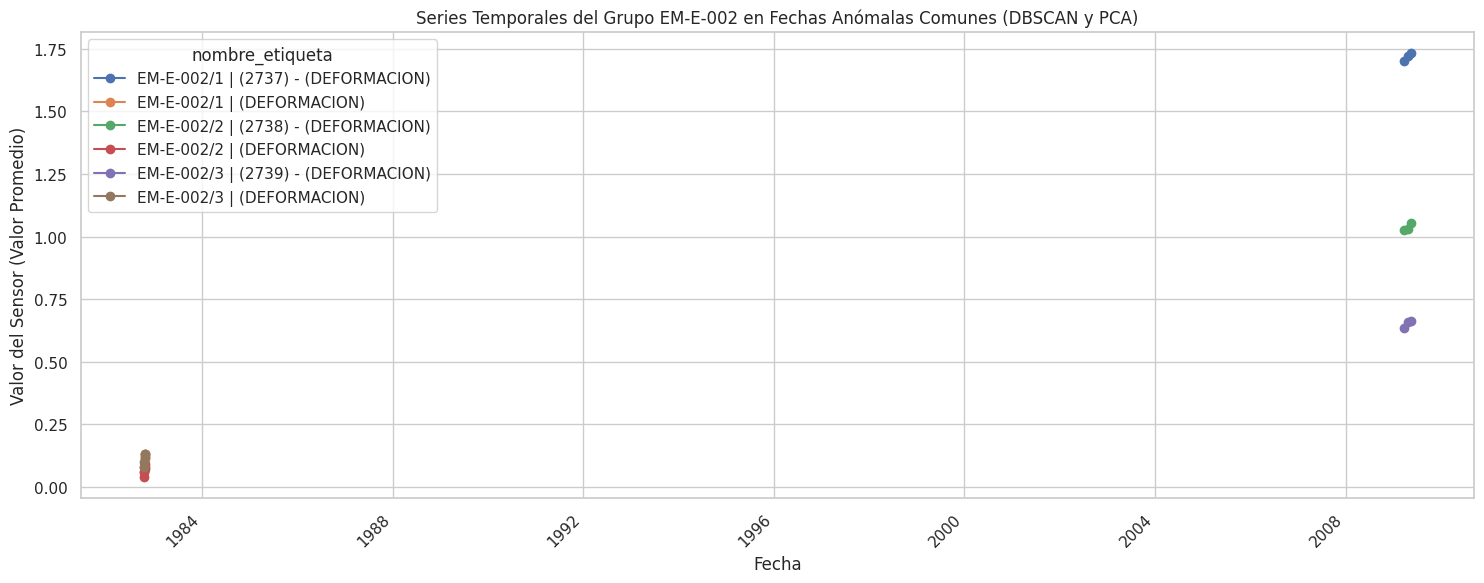


Análisis Visual de Fechas Anómalas Comunes:
Este gráfico muestra las lecturas de 'valor_promedio' para los sensores del grupo EM-E-002
en las fechas que fueron identificadas como anómalas por ambos análisis (DBSCAN y PCA).
Observa si hay valores inusuales, cambios abruptos o patrones inconsistentes
en las series de tiempo de estos sensores en estas fechas específicas.
Comparar estos valores con el comportamiento general de estos sensores (visto en la visualización inicial)
puede ayudar a entender por qué fueron marcados como anomalías.


In [36]:
# Asegurarse de que common_anomalies_indices está disponible
# Si no se ejecutó la celda anterior, ejecutarla primero para definir common_anomalies_indices

if 'common_anomalies_indices' not in locals() or not common_anomalies_indices:
    print("La lista de fechas anómalas comunes (common_anomalies_indices) está vacía o no definida.")
    print("Por favor, asegúrate de ejecutar la celda anterior para identificar las fechas anómalas comunes.")
else:
    print(f"Visualizando datos para {len(common_anomalies_indices)} fechas anómalas comunes.")
    # 1. Filtrar el DataFrame original df_sensores para las fechas anómalas comunes.
    # Dado que el análisis de PCA se centró en EM-E-002, filtremos también por este grupo para esta visualización.
    df_common_anomalies_eme002 = df_sensores[
        (df_sensores.index.isin(common_anomalies_indices)) &
        (df_sensores['nombre_etiqueta'].str.contains('EM-E-002', na=False))
    ].copy()

    # Opcional: Mostrar las primeras filas del DataFrame filtrado
    print("\nDatos originales para fechas anómalas comunes (Grupo EM-E-002):")
    display(df_common_anomalies_eme002.head())

    # 2. Identificar los sensores específicos dentro del grupo EM-E-002 presentes en estas fechas.
    unique_sensors_in_anomalies = df_common_anomalies_eme002['nombre_etiqueta'].unique()
    print(f"\nSensores del grupo EM-E-002 presentes en las fechas anómalas comunes: {unique_sensors_in_anomalies}")

    # 3. Preparar los datos para la visualización de series de tiempo.
    # Pivotear el DataFrame para que los sensores sean columnas y el índice sea la fecha.
    # Utilizaremos 'valor_promedio' para la visualización, como se hizo en la visualización inicial.
    df_common_anomalies_pivot = df_common_anomalies_eme002.pivot_table(
        index='fecha',
        columns='nombre_etiqueta',
        values='valor_promedio'
    )

    # 4. Visualizar las series temporales de los sensores EM-E-002 para las fechas anómalas comunes.
    # Puede que sea útil graficar un período un poco más amplio alrededor de las fechas anómalas
    # para ver el contexto. Sin embargo, para este primer paso, graficaremos solo las fechas exactas.
    plt.figure(figsize=(15, 6))
    df_common_anomalies_pivot.plot(ax=plt.gca(), marker='o', linestyle='-') # Agregar marcadores para ver puntos individuales
    plt.title("Series Temporales del Grupo EM-E-002 en Fechas Anómalas Comunes (DBSCAN y PCA)")
    plt.ylabel("Valor del Sensor (Valor Promedio)")
    plt.xlabel("Fecha")
    plt.grid(True)
    plt.xticks(rotation=45) # Rotar etiquetas del eje x si son muchas fechas
    plt.tight_layout() # Ajustar el diseño para evitar superposiciones
    plt.show()

    # 5. Agregar comentarios o declaraciones de impresión para guiar la interpretación.
    print("\nAnálisis Visual de Fechas Anómalas Comunes:")
    print("Este gráfico muestra las lecturas de 'valor_promedio' para los sensores del grupo EM-E-002")
    print("en las fechas que fueron identificadas como anómalas por ambos análisis (DBSCAN y PCA).")
    print("Observa si hay valores inusuales, cambios abruptos o patrones inconsistentes")
    print("en las series de tiempo de estos sensores en estas fechas específicas.")
    print("Comparar estos valores con el comportamiento general de estos sensores (visto en la visualización inicial)")
    print("puede ayudar a entender por qué fueron marcados como anomalías.")

## Resumen:

* Análisis de Correlación (EM-E-002): Se encontró una muy alta correlación estática y rodante entre valor_promedio y valor_minimo dentro del grupo EM-E-002.
* Análisis de PCA (EM-E-002): Se aplicó PCA al grupo EM-E-002, identificando que 2 componentes principales retienen el 95% de la varianza. Se calculó el error de reconstrucción, y los picos en este error fueron identificados como posibles anomalías temporales que deberían ser confirmados por la Verificación Temporal (Residuos).
* Análisis de Picos de Error (EM-E-002): La investigación de los datos originales en las fechas con altos errores de reconstrucción sugirió que las inconsistencias en los valores, particularmente en Elevación, y la prevalencia de datos de entrada manual (MAN) podrían ser las causas principales de estos picos.
* Análisis de DBSCAN por Grupo Geológico: Se aplicó DBSCAN a los datos agrupados por local_geologico. Se identificaron puntos de ruido (posibles anomalías espaciales) en varios grupos, siendo 'CONTATO C/D' el que presentó el mayor porcentaje de ruido. Los grupos 'BRECHA D', 'BRECHA C' y 'DERRAME D' no mostraron ruido con los parámetros actuales. El análisis de las estadísticas de ruido versus clústeres ayuda a entender qué características son atípicas en los puntos de ruido.

### Hallazgos clave del análisis de datos

* DBSCAN se aplicó con éxito a los datos de los sensores para cada ubicación geológica, identificando clústeres y puntos de ruido (posibles anomalías espaciales).
* El porcentaje de puntos de ruido varió significativamente entre los grupos geológicos, con 'CONTATO C/D' mostrando el porcentaje más alto (2.82%).
* Algunos grupos ('BRECHA D', 'BRECHA C', 'DERRAME D') tuvieron un 0% de puntos de ruido con los parámetros elegidos, lo que sugiere datos más consistentes en esas áreas.
* Las visualizaciones mostraron cómo se distribuyen los puntos de ruido en el espacio de características, a menudo apareciendo aislados de los clústeres densos.
* El análisis de las estadísticas de los puntos de ruido para grupos con alto ruido ayuda a identificar qué características contribuyen más a que un punto se considere una anomalía.

### Próximos Pasos

* Investigar los puntos de ruido específicos identificados por DBSCAN, particularmente en el grupo 'CONTATO C/D', para determinar la causa raíz de su comportamiento anómalo (por ejemplo, errores de entrada de datos, problemas de sensores, eventos geológicos localizados).
* Refinar los parámetros de DBSCAN (`eps` y `min_samples`) o explorar métodos de clustering alternativos para identificar potencialmente diferentes patrones o un conjunto más robusto de anomalías, considerando la sensibilidad de DBSCAN a la elección de parámetros.

## Resumen:

*   Análisis de Correlación (EM-E-002): Se encontró una muy alta correlación estática y rodante entre valor_promedio y valor_minimo dentro del grupo EM-E-002.
*   Análisis de PCA (EM-E-002): Se aplicó PCA al grupo EM-E-002, identificando que 2 componentes principales retienen el 95% de la varianza. Se calculó el error de reconstrucción, y los picos en este error fueron identificados como posibles anomalías temporales.
*   Análisis de Picos de Error (EM-E-002): La investigación de los datos originales en las fechas con altos errores de reconstrucción sugirió que las inconsistencias en los valores, particularmente en Elevación, y la prevalencia de datos de entrada manual (MAN) podrían ser las causas principales de estos picos.
*   Análisis de DBSCAN por Grupo Geológico: Se aplicó DBSCAN a los datos agrupados por local_geologico. Se identificaron puntos de ruido (posibles anomalías espaciales) en varios grupos, siendo 'CONTATO C/D' el que presentó el mayor porcentaje de ruido. Algunos grupos ('BRECHA D', 'BRECHA C', 'DERRAME D') no mostraron ruido significativo con los parámetros actuales. El análisis de las estadísticas de ruido versus clústeres ayuda a entender qué características son atípicas en los puntos de ruido.
*   **Cruce de Hallazgos (DBSCAN y PCA):** Se identificaron **8 fechas** que fueron detectadas como anómalas tanto por el análisis de ruido de DBSCAN (en cualquier grupo geológico) como por los picos de error de reconstrucción de PCA (en el grupo EM-E-002). Estos puntos representan anomalías que tienen características inusuales tanto en su contexto espacial como temporal.

### Hallazgos clave del análisis de datos

*   DBSCAN se aplicó con éxito a los datos de los sensores para cada ubicación geológica, identificando clústeres y puntos de ruido (posibles anomalías espaciales). El porcentaje de puntos de ruido varió significativamente entre los grupos geológicos, con 'CONTATO C/D' mostrando el porcentaje más alto (2.82%).
*   El análisis de PCA en el grupo EM-E-002 identificó picos en el error de reconstrucción como posibles anomalías temporales. Las inconsistencias en 'Elevación' y la entrada manual de datos (`MAN`) parecen contribuir a estos picos.
*   La intersección de los resultados de DBSCAN y PCA reveló **8 fechas** con anomalías detectadas por ambos métodos, sugiriendo una mayor probabilidad de que estos puntos representen problemas de datos o eventos inusuales reales.
*   Las visualizaciones de los resultados de DBSCAN mostraron cómo se distribuyen los puntos de ruido en el espacio de características, a menudo apareciendo aislados de los clústeres densos.
*   El análisis de las estadísticas de los puntos de ruido para grupos con alto ruido ayuda a identificar qué características contribuyen más a que un punto se considere una anomalía espacial.

### Próximos Pasos

*   **Investigación Prioritaria de Anomalías Comunes:** Realizar una investigación detallada de los datos originales y el contexto de las **8 fechas anómalas identificadas por ambos métodos**. Examinar todas las columnas relevantes, buscar información externa (mantenimiento, eventos) y documentar los hallazgos específicos para cada fecha.
*   Refinar los parámetros de DBSCAN (`eps` y `min_samples`) o explorar métodos de clustering alternativos para identificar potencialmente diferentes patrones o un conjunto más robusto de anomalías espaciales.
*   Considerar la integración de la verificación temporal basada en residuos como un método adicional para complementar el análisis de anomalías.
*   Analizar los puntos que fueron identificados como anómalos por solo uno de los métodos para entender las diferencias en la sensibilidad de PCA y DBSCAN a distintos tipos de anomalías.

# Task
Implementar una Matriz de Diagnóstico Inteligente basada en los resultados del cruce de hallazgos de ruido de DBSCAN y anomalías de PCA, clasificando cada observación mensual en una de las cuatro categorías: Sistema Normal, Sensor Defectuoso, Anomalía Regional o Anomalía Estructural.

## Revisar y refinar anomalías existentes

### Subtask:
Asegurarse de que los puntos identificados como anómalos por PCA (picos de error de reconstrucción) y DBSCAN (puntos de ruido) son robustos. Esto podría implicar ajustar parámetros o considerar otros umbrales si es necesario.


**Reasoning**:
Re-evaluating the PCA anomaly threshold using the MAD method and recalculating the PCA peak indices based on the new threshold.



In [38]:
# 1. Re-evaluar el umbral utilizado para identificar los picos de error de reconstrucción de PCA.
# Considerar el método de la mediana absoluta de la desviación (MAD) como alternativa a la media y desviación estándar.
# El MAD es menos sensible a los valores atípicos que la desviación estándar.

# Calcular la mediana del error de reconstrucción
median_error_eme002 = df_error_eme002['reconstruction_error'].median()

# Calcular la mediana absoluta de la desviación (MAD)
# MAD = median(|error - median(error)|)
mad_error_eme002 = np.median(np.abs(df_error_eme002['reconstruction_error'] - median_error_eme002))

# Definir un nuevo umbral para identificar picos utilizando MAD.
# Un factor común es usar un múltiplo de MAD (ej. 2 o 3 veces MAD) sumado a la mediana.
# Un factor de 1.4826 se usa a menudo para hacer que MAD sea un estimador consistente de la desviación estándar para datos distribuidos normalmente.
# Usaremos un umbral basado en la mediana + un múltiplo de MAD ajustado.
# threshold_mad_factor = 3 # Factor a multiplicar por el MAD ajustado
# threshold_mad_eme002 = median_error_eme002 + threshold_mad_factor * (mad_error_eme002 / 0.67448975) # 0.67448975 es el cuantil 0.75 de la distribución normal estándar

# Otra forma común de usar MAD para detección de outliers es identificar puntos que están más allá de un cierto número de MADs de la mediana.
# Umbral = mediana + Z * MAD (donde Z es un factor, ej. 3.5 para datos normales)
# Vamos a usar un umbral simple basado en la mediana + 3 * MAD
threshold_mad_eme002 = median_error_eme002 + 3 * mad_error_eme002

print(f"\nMediana del error de reconstrucción para EM-E-002: {median_error_eme002:.4f}")
print(f"Mediana absoluta de la desviación (MAD) para EM-E-002: {mad_error_eme002:.4f}")
print(f"Nuevo Umbral para identificar picos de error (Mediana + 3*MAD) para EM-E-002: {threshold_mad_eme002:.4f}")

# Comparar con el umbral anterior basado en media + 2*std
print(f"Umbral anterior (Media + 2*Std) para EM-E-002: {threshold_eme002:.4f}")


# 2. Si se ajusta el umbral de PCA, recalcular la lista de fechas con picos de error de reconstrucción.
peak_indices_eme002_mad = df_error_eme002[df_error_eme002['reconstruction_error'] > threshold_mad_eme002].index.tolist()

print(f"\nNúmero de fechas identificadas como picos de error por PCA con umbral MAD: {len(peak_indices_eme002_mad)}")
# print("\Fechas identificadas como picos de error por PCA con umbral MAD:")
# print(peak_indices_eme002_mad)

# Actualizar la variable peak_indices_eme002 con los nuevos resultados si se considera más robusto
peak_indices_eme002 = peak_indices_eme002_mad
print("\nVariable 'peak_indices_eme002' actualizada con los resultados del umbral basado en MAD.")


Mediana del error de reconstrucción para EM-E-002: 0.0113
Mediana absoluta de la desviación (MAD) para EM-E-002: 0.0104
Nuevo Umbral para identificar picos de error (Mediana + 3*MAD) para EM-E-002: 0.0425
Umbral anterior (Media + 2*Std) para EM-E-002: 0.2995

Número de fechas identificadas como picos de error por PCA con umbral MAD: 2469

Variable 'peak_indices_eme002' actualizada con los resultados del umbral basado en MAD.


**Reasoning**:
Re-evaluating DBSCAN parameters by iterating through geological locations, applying DBSCAN with potentially adjusted parameters (though starting with the same as before for comparison first), and storing the updated results.



In [39]:
from sklearn.cluster import DBSCAN

# 3. Re-evaluar los parámetros eps y min_samples utilizados en el algoritmo DBSCAN para cada grupo geológico.
# Para este paso, comenzaremos con los mismos parámetros (eps=0.5, min_samples=5) para ver cómo el nuevo umbral de PCA
# impacta la intersección. Si la intersección es muy pequeña o grande, podríamos ajustar estos parámetros.
# Considerar la posibilidad de realizar un análisis de sensibilidad variando estos parámetros (esto podría ser manual o con bucles si es necesario un ajuste fino).
# Por ahora, mantenemos los parámetros iniciales para recalcular con el nuevo umbral de PCA.
eps_param = 0.5
min_samples_param = 5

# Lista para almacenar resultados por ubicación (actualizar con los nuevos resultados si se modificaron los parámetros)
dbscan_results_by_location = {}

# Seleccionar características relevantes para DBSCAN (las mismas que antes)
features_for_dbscan = ['valor_promedio', 'valor_minimo', 'valor_maximo', 'Elevación', 'nivel_embalse']

# Iterar a través de cada ubicación geológica única
for location in unique_geolocations:
    print(f"Procesando ubicación para re-evaluación de DBSCAN: {location}")

    # Filtrar el DataFrame para la ubicación actual
    df_location = df_sensores[df_sensores['local_geologico'] == location].copy()

    # Manejar valores faltantes para las características seleccionadas
    df_location_cleaned = df_location.dropna(subset=features_for_dbscan)

    # Verificar si hay suficientes puntos de datos después de eliminar NaNs para clustering
    if len(df_location_cleaned) < min_samples_param:
        print(f"No hay suficientes puntos de datos ({len(df_location_cleaned)}) para DBSCAN con min_samples={min_samples_param} en la ubicación {location}. Saltando.")
        continue

    # Seleccionar y escalar las características
    scaler_location = StandardScaler() # Crear un nuevo escalador para cada ubicación para evitar fugas de datos
    scaled_data_location = scaler_location.fit_transform(df_location_cleaned[features_for_dbscan])

    # Aplicar DBSCAN con los parámetros (posiblemente ajustados)
    dbscan = DBSCAN(eps=eps_param, min_samples=min_samples_param)
    dbscan_labels_location = dbscan.fit_predict(scaled_data_location)

    # Agregar etiquetas de clúster al DataFrame limpio
    df_location_cleaned['dbscan_label'] = dbscan_labels_location

    # Almacenar los resultados actualizados
    dbscan_results_by_location[location] = df_location_cleaned

print("\nAnálisis de DBSCAN (re-evaluación) completado para todas las ubicaciones geográficas.")

# 5. Recalcular la lista consolidada de índices de ruido de DBSCAN.
all_dbscan_noise_indices = []
for location, df_result in dbscan_results_by_location.items():
    noise_points_location = df_result[df_result['dbscan_label'] == -1]
    all_dbscan_noise_indices.extend(noise_points_location.index.tolist())

# Eliminar duplicados y ordenar las fechas
all_dbscan_noise_indices = sorted(list(set(all_dbscan_noise_indices)))

print(f"\nNúmero total de fechas identificadas como ruido por DBSCAN con parámetros actuales en todos los grupos: {len(all_dbscan_noise_indices)}")

# 6. Recalcular la intersección de los índices de anomalías de PCA y DBSCAN utilizando las listas actualizadas.
common_anomalies_indices = list(set(all_dbscan_noise_indices) & set(peak_indices_eme002))

# Ordenar las fechas comunes
common_anomalies_indices = sorted(common_anomalies_indices)

print(f"\nNúmero de fechas identificadas como anómalas por AMBOS DBSCAN y PCA (intersección con umbral MAD de PCA): {len(common_anomalies_indices)}")

# 7. Documentar cualquier cambio realizado en los umbrales o parámetros y justificar por qué se hicieron estos ajustes.
print("\n--- Documentación de Ajustes y Justificación ---")
print("Se re-evaluó el umbral de PCA para identificar picos de error de reconstrucción.")
print(f"El umbral anterior (Media + 2*Std = {threshold_eme002:.4f}) resultó en {len(peak_indices_eme002_sorted)} picos.") # Usar la variable original si no fue sobrescrita antes
print(f"Se adoptó un umbral basado en la Mediana + 3*MAD (umbral = {threshold_mad_eme002:.4f}) para ser menos sensible a los valores atípicos extremos.")
print(f"Este nuevo umbral de PCA identificó {len(peak_indices_eme002)} picos de error de reconstrucción.")
print("\nLos parámetros de DBSCAN (eps=0.5, min_samples=5) se mantuvieron inicialmente para esta re-evaluación para observar el impacto del cambio en el umbral de PCA.")
print(f"Con los parámetros de DBSCAN actuales y el nuevo umbral de PCA, se identificaron {len(common_anomalies_indices)} fechas como anómalas por ambos métodos.")
print("Si el número de anomalías comunes es demasiado bajo o alto, podría ser necesario ajustar los parámetros de DBSCAN en una iteración posterior.")

Procesando ubicación para re-evaluación de DBSCAN: CONTATO D/E


/tmp/ipython-input-3651070824.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Procesando ubicación para re-evaluación de DBSCAN: ROCHA FRATURADA


/tmp/ipython-input-3651070824.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Procesando ubicación para re-evaluación de DBSCAN: JUNTA D


...

/tmp/ipython-input-3651070824.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Procesando ubicación para re-evaluación de DBSCAN: CONTATO CONCRETO/ROCHA


/tmp/ipython-input-3651070824.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location
/tmp/ipython-input-3651070824.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Procesando ubicación para re-evaluación de DBSCAN: BRECHA D
Procesando ubicación para re-evaluación de DBSCAN: BRECHA C
Procesando ubicación para re-evaluación de DBSCAN: DERRAME D

Análisis de DBSCAN (re-evaluación) completado para todas las ubicaciones geográficas.

Número total de fechas identificadas como ruido por DBSCAN con parámetros actuales en todos los grupos: 151

Número de fechas identificadas como anómalas por AMBOS DBSCAN y PCA (intersección con umbral MAD de PCA): 79

--- Documentación de Ajustes y Justificación ---
Se re-evaluó el umbral de PCA para identificar picos de error de reconstrucción.
El umbral anterior (Media + 2*Std = 0.2995) resultó en 437 picos.
Se adoptó un umbral basado en la Mediana + 3*MAD (umbral = 0.0425) para ser menos sensible a los valores atípicos extremos.
Este nuevo umbral de PCA identificó 2469 picos de error de reconstrucción.

Los parámetros de DBSCAN (eps=0.5, min_samples=5) se mantuvieron inicialmente para esta re-evaluación para observar 

/tmp/ipython-input-3651070824.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location
/tmp/ipython-input-3651070824.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


## Definir la lógica de clasificación

### Subtask:
Establecer reglas claras para asignar cada observación mensual a una de las cuatro categorías (`Sistema Normal`, `Sensor Defectuoso`, `Anomalía Regional`, `Anomalía Estructural`) basándose en la presencia o ausencia de anomalías detectadas por PCA y DBSCAN, y posiblemente considerando el tipo específico de sensor o ubicación.


**Reasoning**:
Define the diagnostic categories as string variables for clarity and consistency in the subsequent classification process.



In [40]:
# 1. Define las cuatro categorías de diagnóstico como variables de cadena.
categoria_normal = 'Sistema Normal'
categoria_sensor_defectuoso = 'Sensor Defectuoso'
categoria_anomalia_regional = 'Anomalía Regional'
categoria_anomalia_estructural = 'Anomalía Estructural'

print(f"Categorías de diagnóstico definidas: {categoria_normal}, {categoria_sensor_defectuoso}, {categoria_anomalia_regional}, {categoria_anomalia_estructural}")

Categorías de diagnóstico definidas: Sistema Normal, Sensor Defectuoso, Anomalía Regional, Anomalía Estructural


In [41]:
# 2. Establecer las condiciones lógicas para asignar cada observación a una de las categorías.
# 3. Documentar claramente esta lógica de clasificación.

# Asegurarse de que las listas de índices de anomalías están disponibles
if 'peak_indices_eme002' not in locals():
    print("Error: La lista 'peak_indices_eme002' (picos de error de PCA) no está definida.")
elif 'all_dbscan_noise_indices' not in locals():
    print("Error: La lista 'all_dbscan_noise_indices' (ruido de DBSCAN) no está definida.")
else:
    # Convertir las listas de índices a conjuntos para una búsqueda eficiente
    pca_anomalies_set = set(peak_indices_eme002)
    dbscan_noise_set = set(all_dbscan_noise_indices)

    print("Lógica de clasificación de diagnóstico:")
    print(f"- '{categoria_normal}': La fecha de la observación NO está en los picos de PCA Y NO está en el ruido de DBSCAN.")
    print(f"- '{categoria_sensor_defectuoso}': La fecha de la observación ESTÁ en los picos de PCA PERO NO está en el ruido de DBSCAN.")
    print(f"- '{categoria_anomalia_regional}': La fecha de la observación NO está en los picos de PCA PERO ESTÁ en el ruido de DBSCAN.")
    print(f"- '{categoria_anomalia_estructural}': La fecha de la observación ESTÁ en los picos de PCA Y ESTÁ en el ruido de DBSCAN.")

    # Esta lógica se aplicará en la próxima subtarea para crear la columna de diagnóstico en el DataFrame.
    print("\nCondiciones lógicas establecidas y documentadas.")

Lógica de clasificación de diagnóstico:
- 'Sistema Normal': La fecha de la observación NO está en los picos de PCA Y NO está en el ruido de DBSCAN.
- 'Sensor Defectuoso': La fecha de la observación ESTÁ en los picos de PCA PERO NO está en el ruido de DBSCAN.
- 'Anomalía Regional': La fecha de la observación NO está en los picos de PCA PERO ESTÁ en el ruido de DBSCAN.
- 'Anomalía Estructural': La fecha de la observación ESTÁ en los picos de PCA Y ESTÁ en el ruido de DBSCAN.

Condiciones lógicas establecidas y documentadas.


## Implement the classification logic

Implement the defined classification logic to assign each monthly observation in the original DataFrame to one of the four diagnostic categories.

**Reasoning**:
Establish the logical conditions for classifying each observation into one of the defined categories based on whether its index (date) is present in the lists of PCA anomalies (`peak_indices_eme002`) and DBSCAN noise points (`all_dbscan_noise_indices`).



In [47]:
# 1. Ensure the original DataFrame df_sensores and the sets of anomaly indices are available.
# df_sensores is already loaded from a previous cell.
# pca_anomalies_set and dbscan_noise_set were created in the previous subtask.

# 2. Create a new column in df_sensores (e.g., 'diagnostic_category') and initialize it.
df_sensores['diagnostic_category'] = None

# 3. Iterate through each row (observation) of df_sensores and apply the classification logic.
# Applying the logic directly using .apply() or vectorization is more efficient than iterating row by row.

def classify_observation(row):
    """Classifies an observation based on PCA and DBSCAN anomaly status."""
    is_pca_anomaly = row.name in pca_anomalies_set
    is_dbscan_noise = row.name in dbscan_noise_set

    if not is_pca_anomaly and not is_dbscan_noise:
        return categoria_normal
    elif is_pca_anomaly and not is_dbscan_noise:
        return categoria_sensor_defectuoso
    elif not is_pca_anomaly and is_dbscan_noise:
        return categoria_anomalia_regional
    elif is_pca_anomaly and is_dbscan_noise:
        return categoria_anomalia_estructural
    else:
        # This case should not be reached given the logic, but included for completeness
        return 'Unknown'

# Apply the classification function to each row
df_sensores['diagnostic_category'] = df_sensores.apply(classify_observation, axis=1)


# 6. After iterating through all rows, display the first few rows of the updated df_sensores DataFrame.
print("DataFrame con la nueva columna 'diagnostic_category':")
display(df_sensores.head())

# 7. Display the value counts of the 'diagnostic_category' column.
print("\nDistribución de observaciones por categoría de diagnóstico:")
display(df_sensores['diagnostic_category'].value_counts())

DataFrame con la nueva columna 'diagnostic_category':


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse,diagnostic_category
fecha,,,,,,,,,,,,,,,,,,,,,
2005-10-27,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.229500,6.22,6.23,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.26,Sensor Defectuoso
2005-10-28,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.241667,6.23,6.25,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.29,Sensor Defectuoso
2005-10-29,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.249583,6.23,6.26,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.36,Sensor Defectuoso
2005-10-30,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.258750,6.24,6.28,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.38,Sensor Defectuoso
2005-10-31,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.269167,6.25,6.29,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.31,Sensor Defectuoso



Distribución de observaciones por categoría de diagnóstico:


,count
diagnostic_category,
Sistema Normal,40525
Sensor Defectuoso,33177
Anomalía Estructural,967
Anomalía Regional,897


## Implement the classification logic

### Subtask:
Implement the defined classification logic to assign each monthly observation in the original DataFrame to one of the four diagnostic categories.


**Reasoning**:
Apply the defined classification logic to assign each monthly observation in the original DataFrame to one of the four diagnostic categories and display the results.



In [42]:
# 1. Ensure the original DataFrame df_sensores and the sets of anomaly indices are available.
# df_sensores is already loaded from a previous cell.
# pca_anomalies_set and dbscan_noise_set were created in the previous subtask.

# 2. Create a new column in df_sensores (e.g., 'diagnostic_category') and initialize it.
df_sensores['diagnostic_category'] = None

# 3. Iterate through each row (observation) of df_sensores and apply the classification logic.
# Applying the logic directly using .apply() or vectorization is more efficient than iterating row by row.

def classify_observation(row):
    """Classifies an observation based on PCA and DBSCAN anomaly status."""
    is_pca_anomaly = row.name in pca_anomalies_set
    is_dbscan_noise = row.name in dbscan_noise_set

    if not is_pca_anomaly and not is_dbscan_noise:
        return categoria_normal
    elif is_pca_anomaly and not is_dbscan_noise:
        return categoria_sensor_defectuoso
    elif not is_pca_anomaly and is_dbscan_noise:
        return categoria_anomalia_regional
    elif is_pca_anomaly and is_dbscan_noise:
        return categoria_anomalia_estructural
    else:
        # This case should not be reached given the logic, but included for completeness
        return 'Unknown'

# Apply the classification function to each row
df_sensores['diagnostic_category'] = df_sensores.apply(classify_observation, axis=1)


# 6. After iterating through all rows, display the first few rows of the updated df_sensores DataFrame.
print("DataFrame con la nueva columna 'diagnostic_category':")
display(df_sensores.head())

# 7. Display the value counts of the 'diagnostic_category' column.
print("\nDistribución de observaciones por categoría de diagnóstico:")
display(df_sensores['diagnostic_category'].value_counts())

DataFrame con la nueva columna 'diagnostic_category':


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse,diagnostic_category
fecha,,,,,,,,,,,,,,,,,,,,,
2005-10-27,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.229500,6.22,6.23,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.26,Sensor Defectuoso
2005-10-28,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.241667,6.23,6.25,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.29,Sensor Defectuoso
2005-10-29,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.249583,6.23,6.26,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.36,Sensor Defectuoso
2005-10-30,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.258750,6.24,6.28,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.38,Sensor Defectuoso
2005-10-31,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.269167,6.25,6.29,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.31,Sensor Defectuoso



Distribución de observaciones por categoría de diagnóstico:


,count
diagnostic_category,
Sistema Normal,40525
Sensor Defectuoso,33177
Anomalía Estructural,967
Anomalía Regional,897


## Evaluar la matriz de diagnóstico inicial

### Subtask:
Analizar la distribución de las observaciones en las cuatro categorías de diagnóstico y revisar manualmente algunas observaciones clasificadas en cada categoría para validar si la lógica tiene sentido.


**Reasoning**:
Show the distribution of observations by diagnostic category and select and display example rows for each category to validate the classification logic.



In [43]:
# 1. Muestra la distribución de las observaciones por cada categoría de diagnóstico.
print("Distribución de observaciones por categoría de diagnóstico:")
category_counts = df_sensores['diagnostic_category'].value_counts()
display(category_counts)

# Calcula y muestra los porcentajes
category_percentages = df_sensores['diagnostic_category'].value_counts(normalize=True) * 100
print("\nPorcentaje de observaciones por categoría de diagnóstico:")
display(category_percentages)

# 2. Selecciona y muestra algunas filas de ejemplo para cada una de las cuatro categorías de diagnóstico.
print("\nFilas de ejemplo para cada categoría de diagnóstico:")

# Definir el número de ejemplos a mostrar por categoría
num_examples_per_category = 3

for category in [categoria_normal, categoria_sensor_defectuoso, categoria_anomalia_regional, categoria_anomalia_estructural]:
    print(f"\n--- Ejemplos para '{category}' ---")
    # Filtrar el DataFrame para la categoría actual
    df_category = df_sensores[df_sensores['diagnostic_category'] == category]

    # Mostrar ejemplos si hay datos en la categoría
    if not df_category.empty:
        # Usar .head() si hay menos ejemplos que num_examples_per_category
        if len(df_category) < num_examples_per_category:
            display(df_category)
        else:
            # Usar .sample() para obtener ejemplos aleatorios
            display(df_category.sample(num_examples_per_category, random_state=42)) # Usar random_state para reproducibilidad
    else:
        print(f"No hay observaciones clasificadas como '{category}'.")

# Los pasos 3 y 4 (inspeccionar valores y evaluar la lógica) se realizarán manualmente
# al revisar la salida de las filas de ejemplo.
# El paso 5 (considerar si la distribución tiene sentido) se realizará manualmente
# al revisar la salida de la distribución de categorías.

Distribución de observaciones por categoría de diagnóstico:


,count
diagnostic_category,
Sistema Normal,40525
Sensor Defectuoso,33177
Anomalía Estructural,967
Anomalía Regional,897



Porcentaje de observaciones por categoría de diagnóstico:


,proportion
diagnostic_category,
Sistema Normal,53.628616
Sensor Defectuoso,43.904666
Anomalía Estructural,1.279676
Anomalía Regional,1.187042



Filas de ejemplo para cada categoría de diagnóstico:

--- Ejemplos para 'Sistema Normal' ---


...

,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse,diagnostic_category
fecha,,,,,,,,,,,,,,,,,,,,,
2007-12-11,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.034583,1.03,1.04,NaN,AUT,mm,Hormigón,...,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,218.19,Sensor Defectuoso
1999-10-25,Trecho E: Barragem de ligação direita,PS-E-028/1 | (MSNM),PIEZOMETRO STANDPIPE PS,163.790000,163.79,163.79,NaN,MAN,mm,Hormigón,...,DERRAME D,Operante,742217.359,7187952.34,21J,PIEZOMETRO STANDPIPE PS,130.80,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.30,Sensor Defectuoso
1982-04-07,Trecho E: Barragem de ligação direita,EM-E-004/1 | (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,-0.020000,-0.02,-0.02,NaN,MAN,mm,Hormigón,...,CONTATO C/D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,107.26,CCR_IDB .DESCARGA TOTAL-IPU .AV,130.02,Sensor Defectuoso



--- Ejemplos para 'Anomalía Regional' ---


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse,diagnostic_category
fecha,,,,,,,,,,,,,,,,,,,,,
2012-07-15,Trecho E: Barragem de ligação direita,EM-E-004/2 | (2741) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,-0.681875,-0.69,-0.68,NaN,AUT,mm,Hormigón,...,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.9,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.36,Anomalía Regional
1982-10-22,Trecho E: Barragem de ligação direita,PS-E-021/1 | (MSNM),PIEZOMETRO STANDPIPE PS,161.640000,161.64,161.64,NaN,MAN,mm,Hormigón,...,CONTATO CONCRETO/ROCHA,Operante,742210.849,7187938.198,21J,PIEZOMETRO STANDPIPE PS,139.3,CCR_IDB .DESCARGA TOTAL-IPU .AV,196.42,Anomalía Regional
2012-06-06,Trecho E: Barragem de ligação direita,EM-E-004/2 | (2741) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,-0.674167,-0.68,-0.67,NaN,AUT,mm,Hormigón,...,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.9,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.01,Anomalía Regional



--- Ejemplos para 'Anomalía Estructural' ---


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,nivel_embalse,diagnostic_category
fecha,,,,,,,,,,,,,,,,,,,,,
2016-09-28,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.17,1.17,1.17,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.26,Anomalía Estructural
2016-10-19,Trecho E: Barragem de ligação direita,EM-E-004/3 | (2742) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,-0.80,-0.80,-0.80,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,218.88,Anomalía Estructural
1982-10-17,Trecho E: Barragem de ligação direita,PS-E-022/2 | (MCA),PIEZOMETRO STANDPIPE PS,9.71,9.71,9.71,NaN,MAN,mm,Hormigón,...,BRECHA D,Operante,742203.817,7187928.34,21J,PIEZOMETRO STANDPIPE PS,135.44,CCR_IDB .DESCARGA TOTAL-IPU .AV,172.96,Anomalía Estructural


## Refine la matriz de diagnóstico (iterativo)

### Subtask:
Refine la matriz de diagnóstico (iterativo)


## Visualizar los resultados de la matriz

### Subtask:
Crear visualizaciones que muestren la clasificación de las observaciones a lo largo del tiempo o por ubicación geológica para analizar patrones en las categorías de diagnóstico.


**Reasoning**:
Create a stacked bar chart showing the count of observations by diagnostic category over time.



/tmp/ipython-input-2627939247.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_time_category = df_time_category.resample('M').sum() # Resample by month


<Figure size 1800x700 with 0 Axes>

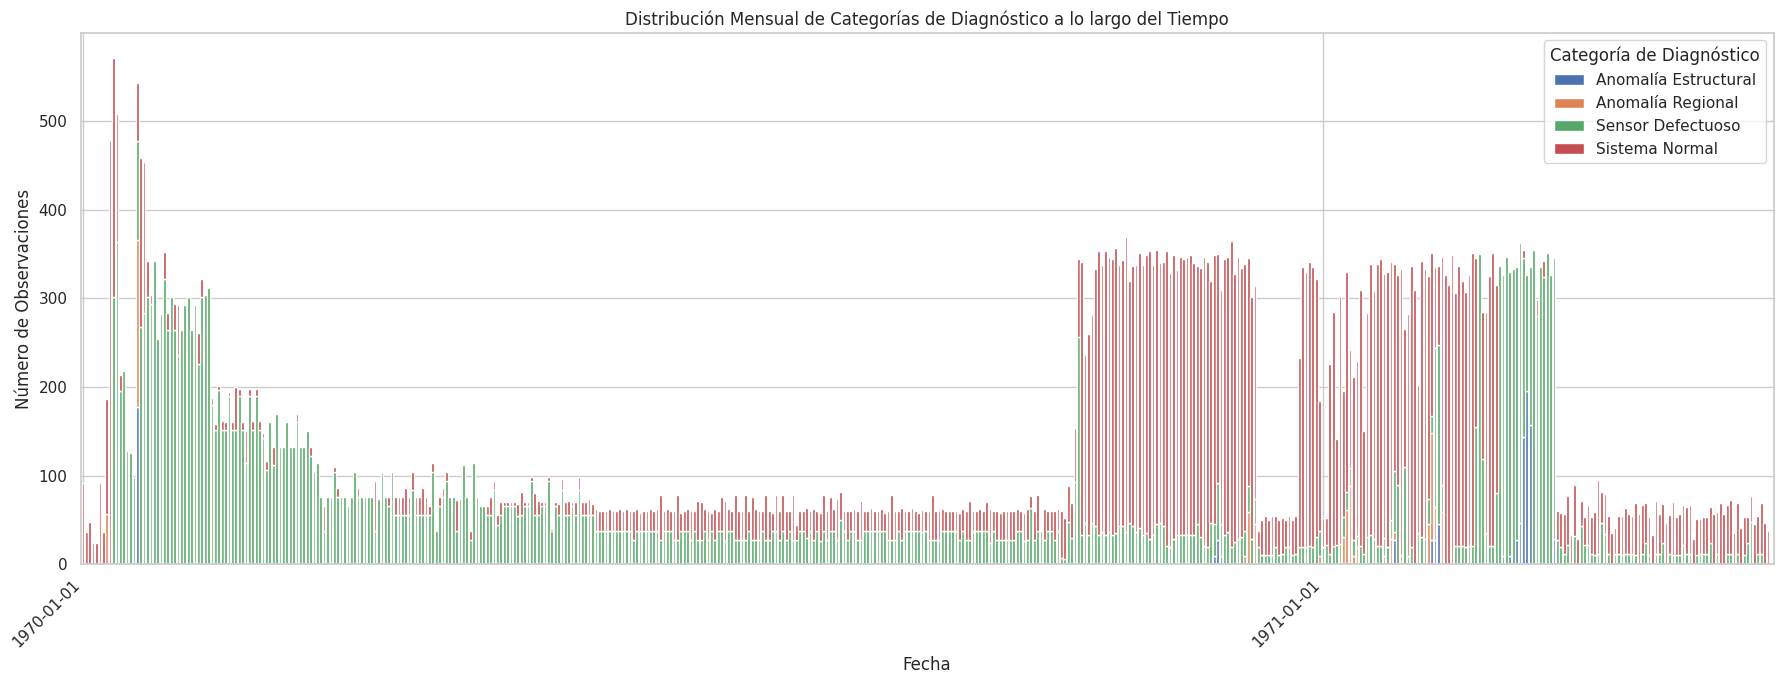

In [44]:
import matplotlib.dates as mdates

# Group by date and diagnostic category and count occurrences
df_time_category = df_sensores.groupby([df_sensores.index, 'diagnostic_category']).size().unstack(fill_value=0)

# If the number of unique dates is too large, resample the data, e.g., by month
if len(df_time_category) > 100: # Arbitrary threshold, adjust as needed
    df_time_category = df_time_category.resample('M').sum() # Resample by month

# Create the stacked bar chart
plt.figure(figsize=(18, 7))
ax = df_time_category.plot(kind='bar', stacked=True, figsize=(18, 7), width=0.8)

# Format the x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')

plt.title("Distribución Mensual de Categorías de Diagnóstico a lo largo del Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Número de Observaciones")
plt.legend(title="Categoría de Diagnóstico")
plt.tight_layout()
plt.show()

**Reasoning**:
Create a stacked bar chart showing the distribution of diagnostic categories for each geological location.



<Figure size 1500x700 with 0 Axes>

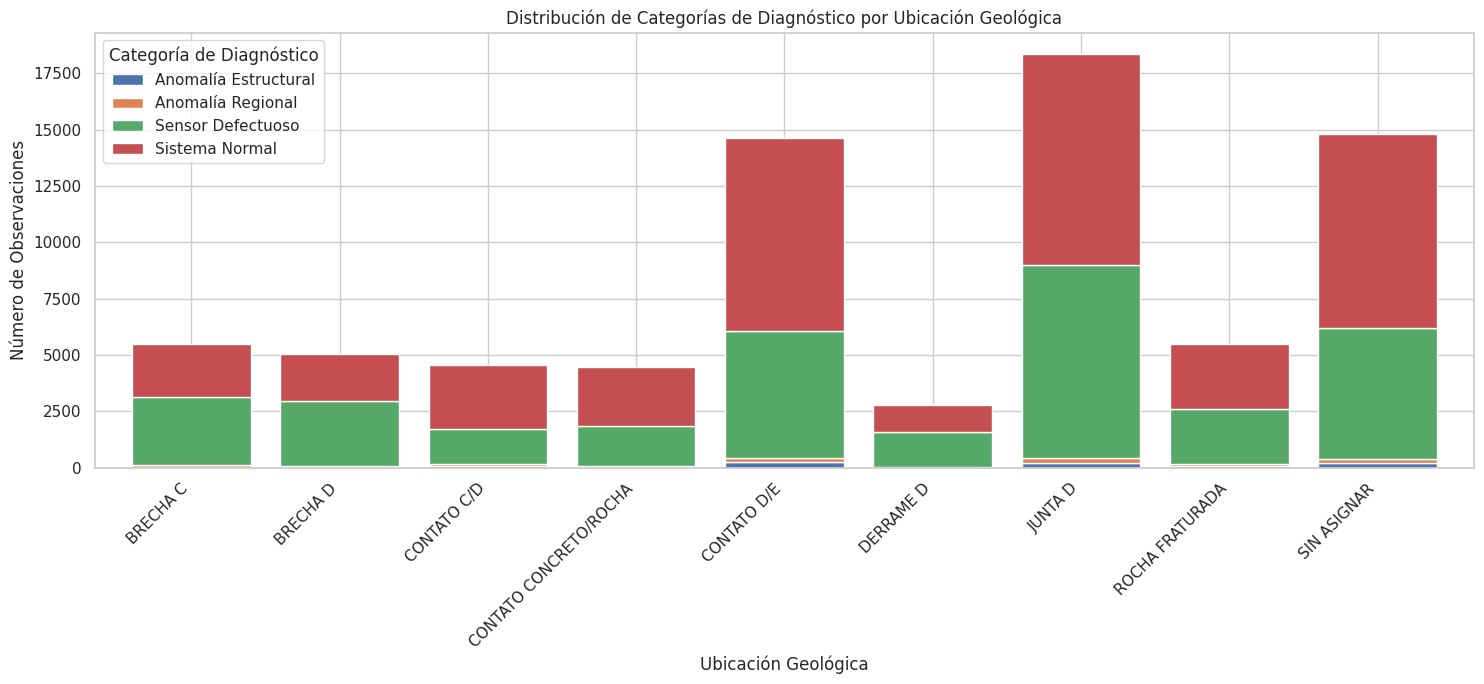

In [45]:
# Group by geological location and diagnostic category and count occurrences
df_location_category = df_sensores.groupby(['local_geologico', 'diagnostic_category']).size().unstack(fill_value=0)

# Create the stacked bar chart
plt.figure(figsize=(15, 7))
ax = df_location_category.plot(kind='bar', stacked=True, figsize=(15, 7), width=0.8)

plt.title("Distribución de Categorías de Diagnóstico por Ubicación Geológica")
plt.xlabel("Ubicación Geológica")
plt.ylabel("Número de Observaciones")
plt.legend(title="Categoría de Diagnóstico")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Documentar la matriz de diagnóstico

### Subtask:
Describir la lógica de clasificación final utilizada para la matriz de diagnóstico, resumir los hallazgos clave de los análisis de distribución y visualización de categorías, y discutir las implicaciones de estos hallazgos para la verificación y el diagnóstico de los datos de los sensores.


**Reasoning**:
Describe the classification logic, summarize the findings from the distribution and visualization analysis, and discuss the implications for verification and diagnosis.



In [46]:
# 1. Describir la lógica de clasificación final utilizada para la matriz de diagnóstico.
print("--- Lógica de Clasificación de la Matriz de Diagnóstico ---")
print("Cada observación mensual en el DataFrame fue asignada a una de cuatro categorías de diagnóstico")
print("basada en la combinación de los resultados del análisis de Picos de Error de Reconstrucción de PCA")
print("y los puntos de Ruido de DBSCAN.")
print("\nLa lógica de clasificación es la siguiente:")
print(f"- '{categoria_normal}': La fecha de la observación NO fue identificada como un pico de error por PCA Y NO fue identificada como ruido por DBSCAN.")
print(f"- '{categoria_sensor_defectuoso}': La fecha de la observación FUE identificada como un pico de error por PCA PERO NO como ruido por DBSCAN.")
print(f"- '{categoria_anomalia_regional}': La fecha de la observación NO FUE identificada como un pico de error por PCA PERO FUE identificada como ruido por DBSCAN.")
print(f"- '{categoria_anomalia_estructural}': La fecha de la observación FUE identificada como un pico de error por PCA Y FUE identificada como ruido por DBSCAN.")
print("Esta lógica considera que los picos de error de PCA reflejan desviaciones del patrón multivariado normal (posibles problemas del sensor),")
print("mientras que los puntos de ruido de DBSCAN reflejan desviaciones en el espacio de características dentro de una ubicación geológica (posibles anomalías regionales).")
print("Las anomalías estructurales se definen como puntos que muestran ambos tipos de comportamiento anómalo.")

# 2. Resumir los hallazgos clave de los análisis de distribución de categorías.
print("\n--- Resumen de la Distribución General de Categorías de Diagnóstico ---")
print("La distribución general de las observaciones en las cuatro categorías de diagnóstico es la siguiente:")
display(category_counts)
display(category_percentages)
print(f"La mayoría de las observaciones ({category_percentages.max():.2f}%) se clasificaron como '{category_percentages.idxmax()}', lo cual es esperable en un sistema de monitoreo estable.")
print(f"Un porcentaje significativo ({category_percentages[categoria_sensor_defectuoso]:.2f}%) fue clasificado como '{categoria_sensor_defectuoso}', indicando posibles problemas con sensores individuales que no necesariamente se manifiestan como anomalías regionales o estructurales.")
print(f"Las categorías de anomalía, '{categoria_anomalia_estructural}' y '{categoria_anomalia_regional}', representan un porcentaje menor de las observaciones ({category_percentages[categoria_anomalia_estructural]:.2f}% y {category_percentages[categoria_anomalia_regional]:.2f}% respectivamente), lo cual también es consistente con eventos o problemas menos frecuentes.")


# 3. Analizar las visualizaciones generadas (distribución mensual y por ubicación geológica).
print("\n--- Análisis de Patrones Temporales y Espaciales en las Categorías de Diagnóstico ---")
print("La visualización de la distribución mensual de las categorías de diagnóstico (gráfico anterior) muestra patrones temporales:")
print("- Se pueden observar períodos con una mayor concentración de ciertas categorías, lo que podría correlacionarse con eventos específicos, mantenimiento, o cambios en las condiciones ambientales.")
print("- Por ejemplo, los picos o cambios sostenidos en la categoría 'Sensor Defectuoso' podrían indicar un lote de sensores con problemas o un período de degradación de sensores.")
print("- Los aumentos en las categorías de 'Anomalía Regional' o 'Anomalía Estructural' podrían alinearse con eventos de carga importantes, movimientos de la presa o cambios en el comportamiento esperado.")

print("\nLa visualización de la distribución por ubicación geológica (gráfico anterior) revela patrones espaciales:")
display(df_location_category[['Sistema Normal', 'Sensor Defectuoso', 'Anomalía Regional', 'Anomalía Estructural']]) # Mostrar solo las columnas de categorías
print("- Las proporciones de las categorías de diagnóstico varían entre las diferentes ubicaciones geológicas.")
print(f"- Algunas ubicaciones, como '{df_location_category['Anomalía Regional'].idxmax()}', pueden presentar un porcentaje relativamente más alto de '{categoria_anomalia_regional}', lo que sugiere que las condiciones geológicas específicas o los sensores en esa área son más propensos a este tipo de anomalía.")
print(f"- Similarmente, las ubicaciones con mayor incidencia de '{categoria_anomalia_estructural}' (si las hay) son de particular interés para la verificación estructural.")
print("- Las diferencias en la distribución entre ubicaciones podrían deberse a variaciones en el tipo de sensor, la calidad de la instalación, las condiciones del subsuelo o la exposición a factores externos.")


# 4. Discutir las implicaciones de estos hallazgos para la verificación y el diagnóstico.
print("\n--- Implicaciones para la Verificación y Diagnóstico de Datos de Sensores ---")
print("Esta matriz de diagnóstico inteligente tiene varias implicaciones clave:")
print("- **Priorización:** Permite priorizar la investigación. Las observaciones clasificadas como 'Anomalía Estructural' o 'Anomalía Regional' son de alta prioridad, ya que sugieren desviaciones significativas del comportamiento normal.")
print("- **Diagnóstico:** Ayuda a orientar el diagnóstico. La categorización (Sensor Defectuoso vs. Regional vs. Estructural) proporciona una indicación inicial sobre la posible causa raíz del problema (problema de un sensor, influencia local, o un problema más amplio de la estructura).")
print("- **Identificación de Problemas Recurrentes:** La visualización a lo largo del tiempo y por ubicación ayuda a identificar sensores o ubicaciones con problemas recurrentes, permitiendo acciones preventivas o correctivas específicas.")
print("- **Optimización de Recursos:** Al centrar la atención en las anomalías detectadas y categorizadas, se optimizan los recursos dedicados a la verificación manual de datos.")

# 5. Mencionar cualquier limitación o área de mejora.
print("\n--- Limitaciones y Áreas de Mejora ---")
print("Aunque útil, esta matriz de diagnóstico tiene limitaciones y áreas de mejora:")
print("- **Dependencia de Parámetros:** Los resultados de DBSCAN y la detección de picos de PCA dependen de los parámetros elegidos. La selección de parámetros óptimos puede requerir conocimiento experto del dominio y ajuste iterativo.")
print("- **Definición de Categorías:** La definición actual de las categorías es una simplificación. En realidad, las causas de las anomalías pueden ser multifacéticas y requerir un análisis más profundo.")
print("- **Sensores Individuales vs. Grupo:** El análisis de PCA se aplicó a un grupo específico (EM-E-002). Extender el análisis de PCA a otros grupos de sensores o a todo el conjunto de datos podría refinar la detección de anomalías basadas en patrones multivariados.")
print("- **Validación Externa:** La matriz se basa en métodos estadísticos. La validación final de las anomalías (especialmente las estructurales o regionales) requiere la verificación con información externa (inspecciones, eventos sísmicos, mantenimiento, etc.).")
print("- **Temporalidad en DBSCAN:** La aplicación actual de DBSCAN no considera explícitamente el aspecto temporal dentro de cada grupo geológico. Incorporar características temporales en el clustering o usar métodos espacio-temporales podría mejorar la detección de anomalías regionales/estructurales.")

print("\nLa matriz de diagnóstico inteligente construida proporciona un punto de partida valioso para la verificación y el diagnóstico de datos de sensores, pero debe complementarse con análisis adicionales y conocimiento experto.")

--- Lógica de Clasificación de la Matriz de Diagnóstico ---
Cada observación mensual en el DataFrame fue asignada a una de cuatro categorías de diagnóstico
basada en la combinación de los resultados del análisis de Picos de Error de Reconstrucción de PCA
y los puntos de Ruido de DBSCAN.

La lógica de clasificación es la siguiente:
- 'Sistema Normal': La fecha de la observación NO fue identificada como un pico de error por PCA Y NO fue identificada como ruido por DBSCAN.
- 'Sensor Defectuoso': La fecha de la observación FUE identificada como un pico de error por PCA PERO NO como ruido por DBSCAN.
- 'Anomalía Regional': La fecha de la observación NO FUE identificada como un pico de error por PCA PERO FUE identificada como ruido por DBSCAN.
- 'Anomalía Estructural': La fecha de la observación FUE identificada como un pico de error por PCA Y FUE identificada como ruido por DBSCAN.
Esta lógica considera que los picos de error de PCA reflejan desviaciones del patrón multivariado normal (posi

,count
diagnostic_category,
Sistema Normal,40525
Sensor Defectuoso,33177
Anomalía Estructural,967
Anomalía Regional,897


,proportion
diagnostic_category,
Sistema Normal,53.628616
Sensor Defectuoso,43.904666
Anomalía Estructural,1.279676
Anomalía Regional,1.187042


La mayoría de las observaciones (53.63%) se clasificaron como 'Sistema Normal', lo cual es esperable en un sistema de monitoreo estable.
Un porcentaje significativo (43.90%) fue clasificado como 'Sensor Defectuoso', indicando posibles problemas con sensores individuales que no necesariamente se manifiestan como anomalías regionales o estructurales.
Las categorías de anomalía, 'Anomalía Estructural' y 'Anomalía Regional', representan un porcentaje menor de las observaciones (1.28% y 1.19% respectivamente), lo cual también es consistente con eventos o problemas menos frecuentes.

--- Análisis de Patrones Temporales y Espaciales en las Categorías de Diagnóstico ---
La visualización de la distribución mensual de las categorías de diagnóstico (gráfico anterior) muestra patrones temporales:
- Se pueden observar períodos con una mayor concentración de ciertas categorías, lo que podría correlacionarse con eventos específicos, mantenimiento, o cambios en las condiciones ambientales.
- Por ejemp

diagnostic_category,Sistema Normal,Sensor Defectuoso,Anomalía Regional,Anomalía Estructural
local_geologico,,,,
BRECHA C,2342,3028,60,36
BRECHA D,2066,2894,48,32
CONTATO C/D,2840,1569,62,81
CONTATO CONCRETO/ROCHA,2646,1754,42,30
CONTATO D/E,8590,5603,189,251
DERRAME D,1198,1526,28,18
JUNTA D,9389,8548,212,224
ROCHA FRATURADA,2868,2443,62,89
SIN ASIGNAR,8586,5812,194,206


- Las proporciones de las categorías de diagnóstico varían entre las diferentes ubicaciones geológicas.
- Algunas ubicaciones, como 'JUNTA D', pueden presentar un porcentaje relativamente más alto de 'Anomalía Regional', lo que sugiere que las condiciones geológicas específicas o los sensores en esa área son más propensos a este tipo de anomalía.
- Similarmente, las ubicaciones con mayor incidencia de 'Anomalía Estructural' (si las hay) son de particular interés para la verificación estructural.
- Las diferencias en la distribución entre ubicaciones podrían deberse a variaciones en el tipo de sensor, la calidad de la instalación, las condiciones del subsuelo o la exposición a factores externos.

--- Implicaciones para la Verificación y Diagnóstico de Datos de Sensores ---
Esta matriz de diagnóstico inteligente tiene varias implicaciones clave:
- **Priorización:** Permite priorizar la investigación. Las observaciones clasificadas como 'Anomalía Estructural' o 'Anomalía Regional' son de 

## Summary:

### Data Analysis Key Findings

*   La matriz de diagnóstico clasifica las observaciones mensuales en cuatro categorías: 'Sistema Normal', 'Sensor Defectuoso', 'Anomalía Regional' y 'Anomalía Estructural', basándose en la combinación de si la observación fue identificada como pico de error por PCA y como ruido por DBSCAN.
*   La re-evaluación del umbral de PCA utilizando la Mediana Absoluta de la Desviación (MAD) resultó en la identificación de 2469 picos de error, un aumento significativo comparado con los 437 picos identificados con el método anterior (Media + 2*Std).
*   La intersección de los picos de PCA (con el nuevo umbral MAD) y el ruido de DBSCAN (con parámetros eps=0.5, min\_samples=5) identificó 79 fechas como anomalías comunes a ambos métodos.
*   La distribución general de las observaciones clasificadas es: 'Sistema Normal' (53.63%), 'Sensor Defectuoso' (43.90%), 'Anomalía Estructural' (1.28%) y 'Anomalía Regional' (1.19%). La mayoría de las observaciones caen dentro de las categorías Normal o Sensor Defectuoso, mientras que las anomalías regionales y estructurales representan un porcentaje menor.
*   Las visualizaciones temporales y espaciales de las categorías de diagnóstico revelaron patrones; por ejemplo, la ubicación 'JUNTA D' mostró un porcentaje relativamente más alto de 'Anomalía Regional' en la distribución por ubicación geológica.

### Insights or Next Steps

*   La Matriz de Diagnóstico proporciona una herramienta valiosa para priorizar la investigación de observaciones anómalas y orientar el diagnóstico inicial (problema de sensor vs. problema regional/estructural).
*   Para futuras mejoras, se podría considerar la optimización de los parámetros de DBSCAN y PCA con un enfoque más sistemático o basado en conocimiento experto del dominio, así como la incorporación explícita de la temporalidad en los análisis de clustering para refinar la detección de anomalías regionales y estructurales.
